# Leakage-Aware Soil Microbe Benchmark with Stacking Ensemble

This notebook is a clean benchmark version of the soil–microbe project. The guiding research question is:

**How can an integrated soil–microbe dataset be structured as a leakage-aware benchmark for evaluating microbial abundance prediction under spatial and temporal transfer?**

The notebook compares multiple plain and advanced tabular models under the same leakage-aware feature set and the same validation protocol. It also includes one carefully implemented stacking ensemble. The stacking model is fitted only inside each training split or validation fold, so the meta-learner never sees the outer test fold during training.

Clustering/state discovery is not included in the main workflow because it is outside the central benchmark question. It can be moved to supplementary material or future work.


## 1. Package setup

This cell installs optional tabular modelling and explainability packages only if they are missing.

In [2]:
import sys
import numpy as np
import pandas as pd

print("Python:", sys.executable)
print("NumPy:", np.__version__)
print("NumPy location:", np.__file__)
print("Pandas:", pd.__version__)
print("Pandas location:", pd.__file__)

Python: /usr/bin/python3
NumPy: 1.26.4
NumPy location: /home/22609573/.local/lib/python3.10/site-packages/numpy/__init__.py
Pandas: 2.2.3
Pandas location: /home/22609573/.local/lib/python3.10/site-packages/pandas/__init__.py


In [3]:
import sklearn
import xgboost
import shap
import numba
import coverage

print("scikit-learn:", sklearn.__version__)
print("XGBoost:", xgboost.__version__)
print("SHAP:", shap.__version__)
print("Numba:", numba.__version__)
print("Coverage:", coverage.__version__)

/home/22609573/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


scikit-learn: 1.4.0
XGBoost: 3.0.5
SHAP: 0.49.1
Numba: 0.67.0
Coverage: 7.16.1


In [4]:
import sys
import subprocess
import importlib.util
%pip install --force-reinstall "xgboost==3.0.5"

INSTALL_MISSING_PACKAGES = True

optional_packages = [
    ("xgboost", "xgboost"),
    ("lightgbm", "lightgbm"),
    ("catboost", "catboost"),
    ("shap", "shap"),
    ("statsmodels", "statsmodels"),
    ("scipy", "scipy"),
]

if INSTALL_MISSING_PACKAGES:
    for package_name, import_name in optional_packages:
        if importlib.util.find_spec(import_name) is None:
            print(f"Installing {package_name}...")
            subprocess.check_call(
                [sys.executable, "-m", "pip", "install", "-q", package_name]
            )

print("Package setup completed.")

Defaulting to user installation because normal site-packages is not writeable
  Using cached xgboost-3.0.5-py3-none-manylinux_2_28_x86_64.whl.metadata (2.1 kB)
  Using cached numpy-2.2.6-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
  Using cached nvidia_nccl_cu12-2.31.2-py3-none-manylinux_2_18_x86_64.whl.metadata (2.1 kB)
  Using cached scipy-1.15.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached xgboost-3.0.5-py3-none-manylinux_2_28_x86_64.whl (94.9 MB)
Using cached numpy-2.2.6-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.8 MB)
Using cached nvidia_nccl_cu12-2.31.2-py3-none-manylinux_2_18_x86_64.whl (342.1 MB)
Using cached scipy-1.15.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (37.7 MB)
  Attempting uninstall: nvidia-nccl-cu12
    Found existing installation: nvidia-nccl-cu12 2.31.2
    Uninstalling nvidia-nccl-cu12-2.31.2:
      Successfully uninstalled nvidia-nccl-cu12-2.31.2
  

In [5]:
%pip install --upgrade "coverage>=7.6.1" numba shap

Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-1.26.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.2 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 2. Imports and reproducibility settings

The imports cover dataset processing, supervised regression models, validation strategies, metrics, plotting, and SHAP interpretation. A fixed random seed is used so that results are reproducible.

In [6]:
import os
import json
import hashlib
import platform
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
import scipy
import statsmodels
import xgboost as xgb
import shap

from scipy.stats import (
    wasserstein_distance,
    spearmanr,
    wilcoxon,
)

from sklearn.model_selection import (
    train_test_split,
    KFold,
    GroupKFold,
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    StackingRegressor,
)
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
)
from sklearn.neighbors import NearestNeighbors

import statsmodels.api as sm
from statsmodels.regression.mixed_linear_model import MixedLM
from statsmodels.stats.multitest import multipletests

try:
    from xgboost import XGBRegressor
    import xgboost
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

try:
    from lightgbm import LGBMRegressor
    import lightgbm
    LIGHTGBM_AVAILABLE = True
except Exception:
    LIGHTGBM_AVAILABLE = False

try:
    from catboost import CatBoostRegressor
    import catboost
    CATBOOST_AVAILABLE = True
except Exception:
    CATBOOST_AVAILABLE = False

try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    SHAP_AVAILABLE = False

try:
    from google.colab import files
    IN_COLAB = True
except Exception:
    IN_COLAB = False


BENCHMARK_VERSION = "1.0"

SEED = 42
REPEAT_SEEDS = [42, 52, 62, 72, 82]

random.seed(SEED)
np.random.seed(SEED)

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("Benchmark version:", BENCHMARK_VERSION)
print("XGBoost available:", XGBOOST_AVAILABLE)
print("LightGBM available:", LIGHTGBM_AVAILABLE)
print("CatBoost available:", CATBOOST_AVAILABLE)
print("SHAP available:", SHAP_AVAILABLE)

Benchmark version: 1.0
XGBoost available: True
LightGBM available: True
CatBoost available: True
SHAP available: True


## 3. Output folders

All generated tables and figures are saved into a single output directory. This makes the notebook easier to use for research because important artifacts are exported automatically.

In [7]:
BASE_DIR = Path("outputs_leakage_aware_revised_benchmark")

TABLE_DIR = BASE_DIR / "tables"
FIG_DIR = BASE_DIR / "figures"
DATA_OUTPUT_DIR = BASE_DIR / "data"

SPLIT_DIR = BASE_DIR / "splits"
PRED_DIR = BASE_DIR / "predictions"
REPRO_DIR = BASE_DIR / "reproducibility"

for folder in [
    BASE_DIR,
    TABLE_DIR,
    FIG_DIR,
    DATA_OUTPUT_DIR,
    SPLIT_DIR,
    PRED_DIR,
    REPRO_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Output directory:", BASE_DIR.resolve())

Output directory: /home/22609573/outputs_leakage_aware_revised_benchmark


## 4. Load the integrated soil–microbe dataset

This cell is for uploading the dataset.  

In [8]:
from pathlib import Path
import pandas as pd
import os

DATA_FILE = "/home/22609573/Downloads/SoilMind_v3_with_coordinates_and_nasa.csv"

print("Current working directory:")
print(os.getcwd())

if not Path(DATA_FILE).exists():
    raise FileNotFoundError(
        f"{DATA_FILE} was not found."
    )

df = pd.read_csv(DATA_FILE)

print("Dataset loaded successfully")
print("Shape:", df.shape)

display(df.head())

Current working directory:
/home/22609573
Dataset loaded successfully
Shape: (47435, 80)


,uid_x,namedLocation_x,domainID_x,siteID_x,plotID_x,collectDate_x,processedDate_x,sampleMaterial_x,geneticSampleID_x,laboratoryName_x,...,soilTemp,field_latitude,field_longitude,airTemp_mean,precip_total,humidity_mean,shortwave_mean,par_mean,surfaceTemp_mean,topWetness_mean
0,dcae2d59-2262-488e-9901-ccf294c8d94d,BART_004.basePlot.bgc,D01,BART,BART_004,2014-05-20T14:07Z,11/30/2017,soil,BART_004-M-5-26-20140520-GEN,Battelle Applied Genomics,...,7.4,44.063889,-71.287375,10.629355,126.37,82.898387,17.069355,7.8,10.544194,0.750968
1,dcae2d59-2262-488e-9901-ccf294c8d94d,BART_004.basePlot.bgc,D01,BART,BART_004,2014-05-20T14:07Z,11/30/2017,soil,BART_004-M-5-26-20140520-GEN,Battelle Applied Genomics,...,7.4,44.063889,-71.287375,10.629355,126.37,82.898387,17.069355,7.8,10.544194,0.750968
2,dcae2d59-2262-488e-9901-ccf294c8d94d,BART_004.basePlot.bgc,D01,BART,BART_004,2014-05-20T14:07Z,11/30/2017,soil,BART_004-M-5-26-20140520-GEN,Battelle Applied Genomics,...,6.4,44.063889,-71.287375,10.629355,126.37,82.898387,17.069355,7.8,10.544194,0.750968
3,dcae2d59-2262-488e-9901-ccf294c8d94d,BART_004.basePlot.bgc,D01,BART,BART_004,2014-05-20T14:07Z,11/30/2017,soil,BART_004-M-5-26-20140520-GEN,Battelle Applied Genomics,...,6.4,44.063889,-71.287375,10.629355,126.37,82.898387,17.069355,7.8,10.544194,0.750968
4,dcae2d59-2262-488e-9901-ccf294c8d94d,BART_004.basePlot.bgc,D01,BART,BART_004,2014-05-20T14:07Z,11/30/2017,soil,BART_004-M-5-26-20140520-GEN,Battelle Applied Genomics,...,5.9,44.063889,-71.287375,10.629355,126.37,82.898387,17.069355,7.8,10.544194,0.750968


## 5. Initial dataset audit

This audit documents the raw integrated dataset before leakage-aware filtering. It records the number of observations, number of variables, duplicate rows, missingness, and column inventory. These outputs support the dataset-construction part of the benchmark.

In [9]:
dataset_summary = pd.DataFrame({
    "Metric": ["Number of rows", "Number of columns", "Duplicate rows", "Total missing values"],
    "Value": [df.shape[0], df.shape[1], int(df.duplicated().sum()), int(df.isnull().sum().sum())]
})

display(dataset_summary)
dataset_summary.to_csv(TABLE_DIR / "dataset_summary.csv", index=False)

column_inventory = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_count": df.isnull().sum().values,
    "missing_percent": (df.isnull().mean() * 100).values,
    "n_unique": [df[c].nunique(dropna=True) for c in df.columns]
})

display(column_inventory.head(30))
column_inventory.to_csv(TABLE_DIR / "column_inventory.csv", index=False)

missing_summary = column_inventory[column_inventory["missing_count"] > 0].sort_values("missing_percent", ascending=False)
display(missing_summary.head(30))
missing_summary.to_csv(TABLE_DIR / "missing_values_summary.csv", index=False)

,Metric,Value
0,Number of rows,47435
1,Number of columns,80
2,Duplicate rows,0
3,Total missing values,341606


,column,dtype,missing_count,missing_percent,n_unique
0,uid_x,object,0,0.000000,13981
1,namedLocation_x,object,0,0.000000,463
2,domainID_x,object,0,0.000000,18
3,siteID_x,object,0,0.000000,42
4,plotID_x,object,0,0.000000,463
5,collectDate_x,object,0,0.000000,6590
6,processedDate_x,object,0,0.000000,214
7,sampleMaterial_x,object,0,0.000000,2
8,geneticSampleID_x,object,0,0.000000,6963
9,laboratoryName_x,object,0,0.000000,2


,column,dtype,missing_count,missing_percent,n_unique
43,nucleicAcidPurity,float64,47435,100.000000,0
36,deprecatedVialID,object,41683,87.873933,601
49,dataQF_y,object,41683,87.873933,1
48,remarks_y,object,41677,87.861284,27
11,dnaSampleCode,object,38734,81.657004,886
26,dataQF_x,object,37506,79.068199,29
25,remarks_x,object,6170,13.007273,20
37,internalLabID_y,object,5752,12.126067,6404
16,inhibitorRemovalRequired,object,5696,12.008011,1
22,meanCqValue,float64,5688,11.991146,314


## 6. Define the prediction target

The supervised target is `meanCopyNumber`, a qPCR-derived microbial abundance proxy. Because raw abundance is usually strongly right-skewed and can contain zero values, the modelling target is transformed using `log1p`.

Missing raw target values: 0
Zero raw target values: 1501


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
meanCopyNumber,47435.0,7.279563e+07,5.298964e+08,0.0,33.300000,6771.60000,52218.800000,189300.100000,1.082880e+08,1.984770e+09,1.003813e+10
log_meanCopyNumber,47435.0,7.775551e+00,4.974512e+00,0.0,3.535145,8.82064,10.863217,12.151094,1.850030e+01,2.140877e+01,2.302966e+01


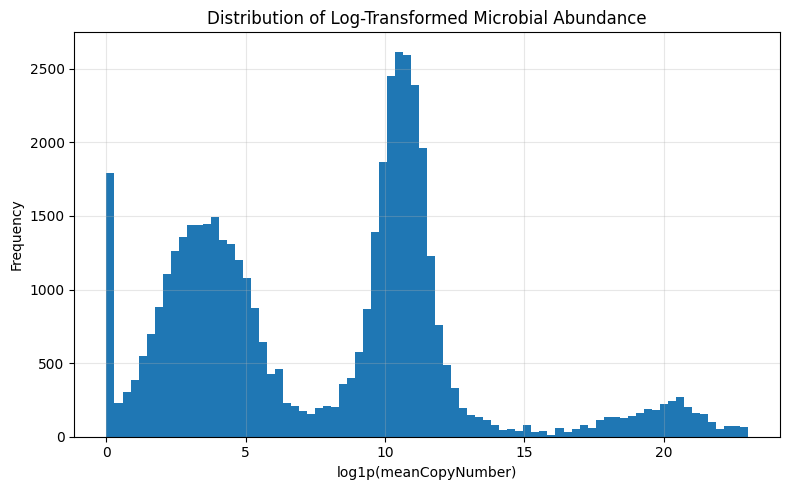

In [10]:
raw_target = "meanCopyNumber"
target = "log_meanCopyNumber"

if raw_target not in df.columns:
    raise ValueError(f"Required target column '{raw_target}' was not found.")

print("Missing raw target values:", df[raw_target].isnull().sum())
print("Zero raw target values:", (df[raw_target] == 0).sum())

df[target] = np.log1p(df[raw_target])

target_summary = df[[raw_target, target]].describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]).T
display(target_summary)
target_summary.to_csv(TABLE_DIR / "target_summary.csv")

plt.figure(figsize=(8, 5))
plt.hist(df[target].dropna(), bins=80)
plt.xlabel("log1p(meanCopyNumber)")
plt.ylabel("Frequency")
plt.title("Distribution of Log-Transformed Microbial Abundance")
plt.tight_layout()
plt.savefig(FIG_DIR / "log_meanCopyNumber_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Leakage-aware cleaning and temporal features

This section removes variables that are likely to create shortcut learning, such as assay-adjacent fields, laboratory metadata, merge artifacts, duplicated identifiers, and processing fields.

In [11]:
df_clean = df.copy()
df_clean["_benchmark_row_id"] = np.arange(len(df_clean), dtype=np.int64)

leakage_or_noise_columns = [
    "nucleicAcidPurity",
    "deprecatedVialID",
    "dataQF_x", "dataQF_y",
    "remarks_x", "remarks_y",
    "dnaSampleCode",
    "uid_x", "uid_y",
    "processedDate_x", "processedDate_y",
    "testProtocolVersion_x", "testProtocolVersion_y",
    "namedLocation_y", "domainID_y", "siteID_y", "plotID_y",
    "collectDate_y", "geneticSampleID_y", "laboratoryName_y",
    "nucleicAcidConcentration_y", "sampleMaterial_y",
    "internalLabID_y",
    "meanCopyNumber", raw_target
]

columns_to_drop = [
    c for c in leakage_or_noise_columns
    if c in df_clean.columns and c != target
]

df_clean = df_clean.drop(
    columns=columns_to_drop,
    errors="ignore"
)

# Preserve only the transformed target required for modelling.
df_clean[target] = df[target]

date_col = next(
    (c for c in ["collectDate", "collectDate_x"] if c in df_clean.columns),
    None
)

if date_col is not None:
    df_clean[date_col] = pd.to_datetime(
        df_clean[date_col],
        errors="coerce"
    )
    df_clean["year_from_date"] = df_clean[date_col].dt.year
    df_clean["month"] = df_clean[date_col].dt.month

if "year_month" in df_clean.columns:
    df_clean["year_month_parsed"] = pd.to_datetime(
        df_clean["year_month"],
        errors="coerce"
    )

    if "month" not in df_clean.columns:
        df_clean["month"] = df_clean["year_month_parsed"].dt.month

    if "year_from_date" not in df_clean.columns:
        df_clean["year_from_date"] = df_clean["year_month_parsed"].dt.year


# Northern Hemisphere seasonal definition for NEON sites.
def month_to_season(month):
    if pd.isna(month):
        return np.nan

    month = int(month)

    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"


if "month" in df_clean.columns:
    df_clean["season"] = df_clean["month"].apply(month_to_season)

print("Shape after leakage-aware cleaning:", df_clean.shape)
print("Date column used:", date_col)

if "season" in df_clean.columns:
    display(
        df_clean[["month", "season"]]
        .drop_duplicates()
        .sort_values("month")
    )
assert df_clean["_benchmark_row_id"].is_unique
assert df_clean["_benchmark_row_id"].notna().all()
assert len(df_clean) == 47435

Shape after leakage-aware cleaning: (47435, 62)
Date column used: collectDate_x


,month,season
8414,1,Winter
8450,2,Winter
2210,3,Spring
60,4,Spring
0,5,Spring
30,6,Summer
36,7,Summer
1094,8,Summer
1337,9,Autumn
729,10,Autumn


## 8. Approved ecological feature set

The traceable working table retains metadata needed for auditing, while the model-ready predictor matrix is constructed through an explicit allow list of 20 approved ecological variables.

In [12]:
soil_features = [
    "soilInWaterpH_mean",
    "soilInCaClpH_mean",
    "soilMoisture_mean",
    "dryMassFraction_mean",
    "soilTemp",
    "sampleTopDepth",
    "sampleBottomDepth",
    "horizon"
]

climate_features = [
    "airTemp_mean",
    "precip_total",
    "humidity_mean",
    "shortwave_mean",
    "par_mean",
    "surfaceTemp_mean",
    "topWetness_mean"
]

spatial_features = [
    "field_latitude",
    "field_longitude"
]

temporal_features = [
    "month",
    "season"
]

land_cover_features = [
    "crop_type"
]

ecological_features = (
    soil_features
    + climate_features
    + spatial_features
    + temporal_features
    + land_cover_features
)

available_features = [
    c for c in ecological_features
    if c in df_clean.columns
]

missing_features = [
    c for c in ecological_features
    if c not in df_clean.columns
]

print("Available ecological predictors:", len(available_features))
print(available_features)
print("Missing expected predictors:", missing_features)

assert len(available_features) == 20, (
    f"Benchmark requires exactly 20 ecological predictors; "
    f"found {len(available_features)}."
)

assert len(missing_features) == 0, (
    f"Missing benchmark predictors: {missing_features}"
)

model_mask = df_clean[target].notna()

model_df = (
    df_clean.loc[
        model_mask,
        available_features + [target]
    ]
    .copy()
    .reset_index(drop=True)
)

meta_cols = [
    c for c in [
        "_benchmark_row_id",
        "siteID",
        "siteID_x",
        "plotID",
        "plotID_x",
        "year",
        "year_from_date",
        "year_month",
        "targetTaxonGroup"
    ]
    if c in df_clean.columns
]

model_meta = (
    df_clean.loc[model_mask, meta_cols]
    .copy()
    .reset_index(drop=True)
)

print("Model-ready benchmark shape:", model_df.shape)
display(model_df.head())

model_df.to_csv(
    DATA_OUTPUT_DIR / "model_ready_ecological_subset.csv",
    index=False
)

model_meta.to_csv(
    DATA_OUTPUT_DIR / "model_ready_metadata_for_validation.csv",
    index=False
)

Available ecological predictors: 20
['soilInWaterpH_mean', 'soilInCaClpH_mean', 'soilMoisture_mean', 'dryMassFraction_mean', 'soilTemp', 'sampleTopDepth', 'sampleBottomDepth', 'horizon', 'airTemp_mean', 'precip_total', 'humidity_mean', 'shortwave_mean', 'par_mean', 'surfaceTemp_mean', 'topWetness_mean', 'field_latitude', 'field_longitude', 'month', 'season', 'crop_type']
Missing expected predictors: []
Model-ready benchmark shape: (47435, 21)


,soilInWaterpH_mean,soilInCaClpH_mean,soilMoisture_mean,dryMassFraction_mean,soilTemp,sampleTopDepth,sampleBottomDepth,horizon,airTemp_mean,precip_total,...,shortwave_mean,par_mean,surfaceTemp_mean,topWetness_mean,field_latitude,field_longitude,month,season,crop_type,log_meanCopyNumber
0,4.321667,3.216667,1.118333,0.5665,7.4,0.0,5.0,O,10.629355,126.37,...,17.069355,7.8,10.544194,0.750968,44.063889,-71.287375,5,Spring,Mixed Forest,0.0
1,4.321667,3.216667,1.118333,0.5665,7.4,5.0,31.0,M,10.629355,126.37,...,17.069355,7.8,10.544194,0.750968,44.063889,-71.287375,5,Spring,Mixed Forest,0.0
2,4.321667,3.216667,1.118333,0.5665,6.4,20.0,30.0,M,10.629355,126.37,...,17.069355,7.8,10.544194,0.750968,44.063889,-71.287375,5,Spring,Mixed Forest,0.0
3,4.321667,3.216667,1.118333,0.5665,6.4,0.0,20.0,O,10.629355,126.37,...,17.069355,7.8,10.544194,0.750968,44.063889,-71.287375,5,Spring,Mixed Forest,0.0
4,4.321667,3.216667,1.118333,0.5665,5.9,0.0,17.0,O,10.629355,126.37,...,17.069355,7.8,10.544194,0.750968,44.063889,-71.287375,5,Spring,Mixed Forest,0.0


## 9. Validation grouping variables

The benchmark uses site and year information for evaluation only. Site grouping enables GroupKFold validation, while year enables time-aware holdout testing. These variables are not included in the predictor matrix.

In [13]:
site_group_col = next((c for c in ["siteID", "siteID_x"] if c in model_meta.columns), None)
plot_group_col = next((c for c in ["plotID", "plotID_x"] if c in model_meta.columns), None)
year_col = next((c for c in ["year", "year_from_date"] if c in model_meta.columns), None)

print("Site grouping column:", site_group_col)
print("Plot grouping column:", plot_group_col)
print("Year column:", year_col)
display(model_meta.head())

Site grouping column: siteID
Plot grouping column: plotID_x
Year column: year


,_benchmark_row_id,siteID,siteID_x,plotID_x,year,year_from_date,year_month,targetTaxonGroup
0,0,BART,BART,BART_004,2014,2014,2014-05,fungi
1,1,BART,BART,BART_004,2014,2014,2014-05,fungi
2,2,BART,BART,BART_004,2014,2014,2014-05,fungi
3,3,BART,BART,BART_004,2014,2014,2014-05,fungi
4,4,BART,BART,BART_004,2014,2014,2014-05,fungi


## 9A. Frozen benchmark split registry

The benchmark publishes row-level split assignments so that future methods are
evaluated on exactly the same random, cross-validation, site-aware and temporal
partitions. These files are benchmark artifacts rather than dynamically chosen
splits.

In [14]:
def safe_filename(label):
    return (
        label.lower()
        .replace("/", "_")
        .replace(" ", "_")
    )


def create_split_registry(
    meta_df,
    dataset_label,
    n_splits=5,
    test_size=0.2
):
    n = len(meta_df)

    registry = pd.DataFrame({
        "Local_Row_Index": np.arange(n)
    })

    if "_benchmark_row_id" in meta_df.columns:
        registry["Benchmark_Row_ID"] = (
            meta_df["_benchmark_row_id"].to_numpy()
        )

    local_site_col = next(
        (c for c in ["siteID", "siteID_x"] if c in meta_df.columns),
        None
    )

    local_year_col = next(
        (c for c in ["year", "year_from_date"] if c in meta_df.columns),
        None
    )


    indices = np.arange(n)

    train_idx, test_idx = train_test_split(
        indices,
        test_size=test_size,
        random_state=SEED
    )

    registry["Random_Split"] = "train"
    registry.loc[test_idx, "Random_Split"] = "test"


    registry["Random_KFold"] = np.nan

    kf = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=SEED
    )

    for fold, (_, fold_test_idx) in enumerate(
        kf.split(indices),
        start=1
    ):
        registry.loc[
            fold_test_idx,
            "Random_KFold"
        ] = fold


    registry["Site_GroupKFold"] = np.nan

    if local_site_col is not None:
        groups = meta_df[local_site_col]
        valid_mask = groups.notna().to_numpy()
        valid_local_idx = np.flatnonzero(valid_mask)

        groups_valid = (
            groups.loc[valid_mask]
            .reset_index(drop=True)
        )

        n_site_splits = min(
            n_splits,
            groups_valid.nunique()
        )

        gkf = GroupKFold(
            n_splits=n_site_splits
        )

        dummy_X = np.zeros(
            (len(groups_valid), 1)
        )

        for fold, (_, fold_test_idx) in enumerate(
            gkf.split(
                dummy_X,
                groups=groups_valid
            ),
            start=1
        ):
            original_idx = valid_local_idx[
                fold_test_idx
            ]

            registry.loc[
                original_idx,
                "Site_GroupKFold"
            ] = fold

        registry["Site_ID"] = groups.to_numpy()


    registry["Temporal_Role"] = "excluded_no_year"
    registry["Temporal_Holdout_Year"] = np.nan

    if local_year_col is not None:
        years = pd.to_numeric(
            meta_df[local_year_col],
            errors="coerce"
        )

        holdout_year = int(years.max())

        registry.loc[
            years < holdout_year,
            "Temporal_Role"
        ] = "train"

        registry.loc[
            years == holdout_year,
            "Temporal_Role"
        ] = "test"

        registry["Temporal_Holdout_Year"] = holdout_year
        registry["Year"] = years.to_numpy()

    registry["Dataset"] = dataset_label
    registry["Benchmark_Version"] = BENCHMARK_VERSION

    output_path = (
        SPLIT_DIR
        / f"{safe_filename(dataset_label)}_split_registry.csv"
    )

    registry.to_csv(
        output_path,
        index=False
    )

    return registry


global_split_registry = create_split_registry(
    model_meta,
    dataset_label="Global"
)

display(global_split_registry.head())
print(
    "Frozen global split registry saved:",
    len(global_split_registry)
)

,Local_Row_Index,Benchmark_Row_ID,Random_Split,Random_KFold,Site_GroupKFold,Site_ID,Temporal_Role,Temporal_Holdout_Year,Year,Dataset,Benchmark_Version
0,0,0,train,2.0,3.0,BART,train,2018,2014,Global,1.0
1,1,1,test,1.0,3.0,BART,train,2018,2014,Global,1.0
2,2,2,train,5.0,3.0,BART,train,2018,2014,Global,1.0
3,3,3,train,3.0,3.0,BART,train,2018,2014,Global,1.0
4,4,4,test,1.0,3.0,BART,train,2018,2014,Global,1.0


Frozen global split registry saved: 47435


## 10. Benchmark model list

This section defines the model families used in the benchmark. The list includes simple linear baselines, nonlinear tree ensembles, gradient boosting models and one stacking ensemble.

The stacking ensemble is treated carefully. It is not trained on the full dataset before validation. Instead, it is wrapped inside the same preprocessing pipeline as the other models and is fitted separately inside each random split, cross-validation fold, GroupKFold fold and time-aware holdout. This prevents the outer test data from being used by the stacking meta-learner.


In [15]:
def get_stacking_base_names():
    """Return base models available for the stacking ensemble.

    The stack is deliberately limited to strong but diverse tabular models.
    It is only used when at least two base learners are available.
    """
    base_names = ["Random Forest", "Extra Trees"]
    if XGBOOST_AVAILABLE:
        base_names.append("XGBoost")
    if LIGHTGBM_AVAILABLE:
        base_names.append("LightGBM")
    if CATBOOST_AVAILABLE:
        base_names.append("CatBoost")
    return base_names


def available_model_names():
    names = [
        "Ridge",
        "ElasticNet",
        "Random Forest",
        "Extra Trees"
    ]
    if XGBOOST_AVAILABLE:
        names.append("XGBoost")
    if LIGHTGBM_AVAILABLE:
        names.append("LightGBM")
    if CATBOOST_AVAILABLE:
        names.append("CatBoost")
    if len(get_stacking_base_names()) >= 2:
        names.append("Stacking Ensemble")
    return names


MODEL_NAMES = available_model_names()
STACKING_BASE_NAMES = get_stacking_base_names()

model_description = pd.DataFrame({
    "Model": MODEL_NAMES,
    "Role in benchmark": [
        "Regularised linear baseline" if m == "Ridge" else
        "Sparse regularised linear baseline" if m == "ElasticNet" else
        "Bagging-based nonlinear tree ensemble" if m == "Random Forest" else
        "Highly randomised tree ensemble" if m == "Extra Trees" else
        "Boosted tree model for tabular nonlinear prediction" if m == "XGBoost" else
        "Fast gradient boosting model for structured data" if m == "LightGBM" else
        "Gradient boosting model commonly strong on heterogeneous tabular data" if m == "CatBoost" else
        "Hybrid stack trained with out-of-fold base-model predictions inside each training split"
        for m in MODEL_NAMES
    ]
})

print("Benchmark models:", MODEL_NAMES)
print("Stacking base learners:", STACKING_BASE_NAMES)
display(model_description)
model_description.to_csv(TABLE_DIR / "benchmark_model_description.csv", index=False)


Benchmark models: ['Ridge', 'ElasticNet', 'Random Forest', 'Extra Trees', 'XGBoost', 'LightGBM', 'CatBoost', 'Stacking Ensemble']
Stacking base learners: ['Random Forest', 'Extra Trees', 'XGBoost', 'LightGBM', 'CatBoost']


,Model,Role in benchmark
0,Ridge,Regularised linear baseline
1,ElasticNet,Sparse regularised linear baseline
2,Random Forest,Bagging-based nonlinear tree ensemble
3,Extra Trees,Highly randomised tree ensemble
4,XGBoost,Boosted tree model for tabular nonlinear predi...
5,LightGBM,Fast gradient boosting model for structured data
6,CatBoost,Gradient boosting model commonly strong on het...
7,Stacking Ensemble,Hybrid stack trained with out-of-fold base-mod...


## 11. Reusable benchmark functions

These functions make sure every model is evaluated under the same preprocessing, metrics, and validation settings. This is the core requirement for a fair benchmark.

In [16]:
def rmse(y_true, y_pred):
    return float(
        np.sqrt(
            mean_squared_error(
                y_true,
                y_pred
            )
        )
    )


def metric_dict(y_true, y_pred):
    return {
        "R2": float(
            r2_score(y_true, y_pred)
        ),
        "MAE": float(
            mean_absolute_error(
                y_true,
                y_pred
            )
        ),
        "RMSE": rmse(
            y_true,
            y_pred
        )
    }


def make_one_hot_encoder(drop=None):
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
            drop=drop
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=False,
            drop=drop
        )


def build_preprocessor(
    X,
    scale_numeric=False
):
    numeric_cols = (
        X.select_dtypes(
            include=[np.number]
        )
        .columns
        .tolist()
    )

    categorical_cols = [
        c for c in X.columns
        if c not in numeric_cols
    ]

    if scale_numeric:
        numeric_pipeline = Pipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(
                        strategy="median"
                    )
                ),
                (
                    "scaler",
                    StandardScaler()
                )
            ]
        )
    else:
        numeric_pipeline = Pipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(
                        strategy="median"
                    )
                )
            ]
        )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                )
            ),
            (
                "onehot",
                make_one_hot_encoder()
            )
        ]
    )

    return ColumnTransformer(
        transformers=[
            (
                "num",
                numeric_pipeline,
                numeric_cols
            ),
            (
                "cat",
                categorical_pipeline,
                categorical_cols
            )
        ],
        remainder="drop"
    )


def build_model(
    model_name,
    seed=SEED
):
    if model_name == "Ridge":
        return Ridge(
            alpha=1.0
        )

    if model_name == "ElasticNet":
        return ElasticNet(
            alpha=0.001,
            l1_ratio=0.3,
            max_iter=10000,
            random_state=seed
        )

    if model_name == "Random Forest":
        return RandomForestRegressor(
            n_estimators=200,
            min_samples_leaf=2,
            random_state=seed,
            n_jobs=-1
        )

    if model_name == "Extra Trees":
        return ExtraTreesRegressor(
            n_estimators=200,
            min_samples_leaf=2,
            random_state=seed,
            n_jobs=-1
        )

    if model_name == "XGBoost":
        return XGBRegressor(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=seed,
            n_jobs=-1,
            tree_method="hist"
        )

    if model_name == "LightGBM":
        return LGBMRegressor(
            n_estimators=500,
            learning_rate=0.04,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=seed,
            n_jobs=-1,
            verbosity=-1
        )

    if model_name == "CatBoost":
        return CatBoostRegressor(
            iterations=500,
            learning_rate=0.05,
            depth=6,
            loss_function="RMSE",
            random_seed=seed,
            verbose=False
        )

    if model_name == "Stacking Ensemble":
        raise ValueError(
            "Stacking Ensemble is constructed by "
            "build_pipeline() so that preprocessing is "
            "nested inside every base learner."
        )

    raise ValueError(
        f"Unknown model name: {model_name}"
    )


def build_pipeline(
    X,
    model_name,
    seed=SEED
):

    if model_name == "Stacking Ensemble":

        base_names = get_stacking_base_names()

        if len(base_names) < 2:
            raise ValueError(
                "Stacking Ensemble requires at least "
                "two base learners."
            )

        estimators = []

        for base_name in base_names:
            short_name = (
                base_name
                .lower()
                .replace(" ", "_")
                .replace("/", "_")
            )

            base_pipeline = Pipeline(
                steps=[
                    (
                        "preprocess",
                        build_preprocessor(
                            X,
                            scale_numeric=False
                        )
                    ),
                    (
                        "model",
                        build_model(
                            base_name,
                            seed=seed
                        )
                    )
                ]
            )

            estimators.append(
                (
                    short_name,
                    base_pipeline
                )
            )

        return StackingRegressor(
            estimators=estimators,
            final_estimator=Ridge(
                alpha=1.0
            ),
            cv=KFold(
                n_splits=5,
                shuffle=True,
                random_state=seed
            ),
            passthrough=False,
            n_jobs=-1
        )


    scale_numeric = (
        model_name
        in ["Ridge", "ElasticNet"]
    )

    return Pipeline(
        steps=[
            (
                "preprocess",
                build_preprocessor(
                    X,
                    scale_numeric=scale_numeric
                )
            ),
            (
                "model",
                build_model(
                    model_name,
                    seed=seed
                )
            )
        ]
    )


def random_split_evaluation(
    X,
    y,
    model_name,
    test_size=0.2,
    split_seed=SEED,
    model_seed=SEED
):
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=split_seed
    )

    pipe = build_pipeline(
        X_train,
        model_name,
        seed=model_seed
    )

    pipe.fit(
        X_train,
        y_train
    )

    pred = pipe.predict(
        X_test
    )

    return (
        metric_dict(
            y_test,
            pred
        ),
        pipe,
        X_train,
        X_test,
        y_train,
        y_test,
        pred
    )


def kfold_evaluation(
    X,
    y,
    model_name,
    n_splits=5,
    split_seed=SEED,
    model_seed=SEED
):
    kf = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=split_seed
    )

    rows = []

    for fold, (
        train_idx,
        test_idx
    ) in enumerate(
        kf.split(X),
        start=1
    ):

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        pipe = build_pipeline(
            X_train,
            model_name,
            seed=model_seed
        )

        pipe.fit(
            X_train,
            y_train
        )

        pred = pipe.predict(
            X_test
        )

        rows.append({
            "Fold": fold,
            **metric_dict(
                y_test,
                pred
            )
        })

    return pd.DataFrame(rows)


def groupkfold_evaluation(
    X,
    y,
    groups,
    model_name,
    n_splits=5,
    model_seed=SEED,
    row_ids=None,
    return_predictions=False
):
    valid_mask = groups.notna().to_numpy()

    X_valid = (
        X.loc[valid_mask]
        .reset_index(drop=True)
    )

    y_valid = (
        y.loc[valid_mask]
        .reset_index(drop=True)
    )

    groups_valid = (
        groups.loc[valid_mask]
        .reset_index(drop=True)
    )

    valid_local_indices = np.flatnonzero(
        valid_mask
    )

    if row_ids is None:
        row_ids_valid = pd.Series(
            valid_local_indices
        )
    else:
        row_ids_series = pd.Series(
            np.asarray(row_ids),
            index=X.index
        )

        row_ids_valid = (
            row_ids_series
            .loc[valid_mask]
            .reset_index(drop=True)
        )

    n_unique_groups = (
        groups_valid.nunique()
    )

    if n_unique_groups < 2:
        empty_metrics = pd.DataFrame([
            {
                "Fold": np.nan,
                "R2": np.nan,
                "MAE": np.nan,
                "RMSE": np.nan
            }
        ])

        if return_predictions:
            return (
                empty_metrics,
                pd.DataFrame()
            )

        return empty_metrics

    n_splits = min(
        n_splits,
        n_unique_groups
    )

    gkf = GroupKFold(
        n_splits=n_splits
    )

    metric_rows = []
    prediction_rows = []

    for fold, (
        train_idx,
        test_idx
    ) in enumerate(
        gkf.split(
            X_valid,
            y_valid,
            groups_valid
        ),
        start=1
    ):

        X_train = X_valid.iloc[
            train_idx
        ]

        X_test = X_valid.iloc[
            test_idx
        ]

        y_train = y_valid.iloc[
            train_idx
        ]

        y_test = y_valid.iloc[
            test_idx
        ]

        pipe = build_pipeline(
            X_train,
            model_name,
            seed=model_seed
        )

        pipe.fit(
            X_train,
            y_train
        )

        pred = pipe.predict(
            X_test
        )

        metric_rows.append({
            "Fold": fold,
            **metric_dict(
                y_test,
                pred
            )
        })

        if return_predictions:
            pred_df = pd.DataFrame({
                "Local_Row_Index":
                    valid_local_indices[
                        test_idx
                    ],
                "Benchmark_Row_ID":
                    row_ids_valid
                    .iloc[test_idx]
                    .to_numpy(),
                "Fold": fold,
                "Site":
                    groups_valid
                    .iloc[test_idx]
                    .astype(str)
                    .to_numpy(),
                "Observed":
                    y_test.to_numpy(),
                "Predicted":
                    pred
            })

            pred_df["Residual"] = (
                pred_df["Observed"]
                - pred_df["Predicted"]
            )

            pred_df["Absolute_Error"] = (
                pred_df["Residual"]
                .abs()
            )

            pred_df["Squared_Error"] = (
                pred_df["Residual"] ** 2
            )

            prediction_rows.append(
                pred_df
            )

    metrics_df = pd.DataFrame(
        metric_rows
    )

    if return_predictions:
        predictions_df = pd.concat(
            prediction_rows,
            ignore_index=True
        )

        return (
            metrics_df,
            predictions_df
        )

    return metrics_df


def time_aware_holdout_evaluation(
    X,
    y,
    years,
    model_name,
    model_seed=SEED
):
    years_numeric = pd.to_numeric(
        years,
        errors="coerce"
    )

    valid_mask = (
        years_numeric
        .notna()
        .to_numpy()
    )

    X_valid = (
        X.loc[valid_mask]
        .reset_index(drop=True)
    )

    y_valid = (
        y.loc[valid_mask]
        .reset_index(drop=True)
    )

    years_valid = (
        years_numeric
        .loc[valid_mask]
        .reset_index(drop=True)
    )

    if years_valid.nunique() < 2:
        return {
            "R2": np.nan,
            "MAE": np.nan,
            "RMSE": np.nan,
            "Holdout_Year": np.nan
        }

    holdout_year = int(
        years_valid.max()
    )

    train_mask = (
        years_valid
        < holdout_year
    )

    test_mask = (
        years_valid
        == holdout_year
    )

    if (
        train_mask.sum() == 0
        or test_mask.sum() == 0
    ):
        return {
            "R2": np.nan,
            "MAE": np.nan,
            "RMSE": np.nan,
            "Holdout_Year": holdout_year
        }

    X_train = X_valid.loc[
        train_mask
    ]

    X_test = X_valid.loc[
        test_mask
    ]

    y_train = y_valid.loc[
        train_mask
    ]

    y_test = y_valid.loc[
        test_mask
    ]

    pipe = build_pipeline(
        X_train,
        model_name,
        seed=model_seed
    )

    pipe.fit(
        X_train,
        y_train
    )

    pred = pipe.predict(
        X_test
    )

    out = metric_dict(
        y_test,
        pred
    )

    out["Holdout_Year"] = (
        holdout_year
    )

    return out


def summarize_cv(
    cv_df,
    setting_name
):
    return {
        "Setting": setting_name,

        "R2":
            float(
                cv_df["R2"].mean()
            ),

        "R2_SD":
            float(
                cv_df["R2"].std(
                    ddof=1
                )
            ),

        "MAE":
            float(
                cv_df["MAE"].mean()
            ),

        "MAE_SD":
            float(
                cv_df["MAE"].std(
                    ddof=1
                )
            ),

        "RMSE":
            float(
                cv_df["RMSE"].mean()
            ),

        "RMSE_SD":
            float(
                cv_df["RMSE"].std(
                    ddof=1
                )
            ),

        "N_Folds":
            int(
                len(cv_df)
            )
    }

## 12. Helper functions for full benchmark execution

This cell runs each model under random split, K-fold cross-validation, GroupKFold by site, and time-aware holdout. The same function is reused for the global task and subgroup tasks.

In [17]:
def run_benchmark(
    X,
    y,
    model_names,
    dataset_label,
    site_groups=None,
    years=None,
    row_ids=None,
    n_splits=5
):
    rows = []

    fold_outputs = {}
    random_artifacts = {}
    prediction_outputs = {}

    for model_name in model_names:

        print(
            f"Running {dataset_label}: "
            f"{model_name}"
        )


        (
            random_metrics,
            pipe,
            X_train,
            X_test,
            y_train,
            y_test,
            pred
        ) = random_split_evaluation(
            X,
            y,
            model_name
        )

        rows.append({
            "Dataset": dataset_label,
            "Model": model_name,
            "Setting": "Random split",
            **random_metrics
        })

        random_artifacts[
            model_name
        ] = {
            "pipeline": pipe,
            "X_train": X_train,
            "X_test": X_test,
            "y_train": y_train,
            "y_test": y_test,
            "pred": pred
        }


        kf_df = kfold_evaluation(
            X,
            y,
            model_name,
            n_splits=n_splits
        )

        fold_outputs[
            (
                model_name,
                "5-fold CV"
            )
        ] = kf_df

        rows.append({
            "Dataset": dataset_label,
            "Model": model_name,
            **summarize_cv(
                kf_df,
                "5-fold CV"
            )
        })


        if site_groups is not None:

            (
                gkf_df,
                gkf_predictions
            ) = groupkfold_evaluation(
                X,
                y,
                site_groups,
                model_name,
                n_splits=n_splits,
                row_ids=row_ids,
                return_predictions=True
            )

            fold_outputs[
                (
                    model_name,
                    "GroupKFold by site"
                )
            ] = gkf_df

            prediction_outputs[
                (
                    model_name,
                    "GroupKFold by site"
                )
            ] = gkf_predictions

            rows.append({
                "Dataset": dataset_label,
                "Model": model_name,
                **summarize_cv(
                    gkf_df,
                    "GroupKFold by site"
                )
            })


        if years is not None:

            time_metrics = (
                time_aware_holdout_evaluation(
                    X,
                    y,
                    years,
                    model_name
                )
            )

            holdout_year = (
                time_metrics.pop(
                    "Holdout_Year",
                    np.nan
                )
            )

            rows.append({
                "Dataset": dataset_label,
                "Model": model_name,
                "Setting":
                    "Time-aware holdout",
                "Holdout_Year":
                    holdout_year,
                **time_metrics
            })

    results = pd.DataFrame(
        rows
    )
    return (
        results,
        fold_outputs,
        random_artifacts,
        prediction_outputs
    )


def make_r2_pivot(results_df):
    return results_df.pivot_table(index="Model", columns="Setting", values="R2", aggfunc="mean")


def plot_r2_heatmap(pivot_df, title, filename):
    plot_df = pivot_df.copy()
    fig, ax = plt.subplots(figsize=(10, max(4, 0.45 * len(plot_df))))
    im = ax.imshow(plot_df.values, aspect="auto")
    ax.set_xticks(np.arange(plot_df.shape[1]))
    ax.set_xticklabels(plot_df.columns, rotation=35, ha="right")
    ax.set_yticks(np.arange(plot_df.shape[0]))
    ax.set_yticklabels(plot_df.index)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label="R²")

    for i in range(plot_df.shape[0]):
        for j in range(plot_df.shape[1]):
            value = plot_df.iloc[i, j]
            if pd.notna(value):
                ax.text(j, i, f"{value:.3f}", ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()


def compute_generalisation_gaps(results_df):
    rows = []
    for (dataset, model), group_df in results_df.groupby(["Dataset", "Model"]):
        values = group_df.set_index("Setting")
        random_r2 = values.loc["Random split", "R2"] if "Random split" in values.index else np.nan
        kfold_r2 = values.loc["5-fold CV", "R2"] if "5-fold CV" in values.index else np.nan
        site_r2 = values.loc["GroupKFold by site", "R2"] if "GroupKFold by site" in values.index else np.nan
        time_r2 = values.loc["Time-aware holdout", "R2"] if "Time-aware holdout" in values.index else np.nan

        rows.append({
            "Dataset": dataset,
            "Model": model,
            "Random_R2": random_r2,
            "KFold_R2": kfold_r2,
            "Site_R2": site_r2,
            "Time_R2": time_r2,
            "Site_Generalisation_Gap": random_r2 - site_r2 if pd.notna(random_r2) and pd.notna(site_r2) else np.nan,
            "Temporal_Generalisation_Gap": random_r2 - time_r2 if pd.notna(random_r2) and pd.notna(time_r2) else np.nan,
            "Mean_Transfer_R2": np.nanmean([site_r2, time_r2])
        })

    return pd.DataFrame(rows)

## 13. Global benchmark across plain and stacking model

The global benchmark tests whether one model can predict microbial abundance across all microbial groups using the same leakage-aware ecological features. This is the main model-comparison table for the benchmarking paper.

In [18]:
X_global = (
    model_df[
        available_features
    ]
    .copy()
)

y_global = (
    model_df[target]
    .copy()
)

site_groups_global = (
    model_meta[site_group_col]
    if site_group_col is not None
    else None
)

years_global = (
    model_meta[year_col]
    if year_col is not None
    else None
)

row_ids_global = (
    model_meta[
        "_benchmark_row_id"
    ]
    if "_benchmark_row_id"
       in model_meta.columns
    else None
)

(
    global_results,
    global_fold_outputs,
    global_random_artifacts,
    global_prediction_outputs
) = run_benchmark(
    X=X_global,
    y=y_global,
    model_names=MODEL_NAMES,
    dataset_label="Global",
    site_groups=site_groups_global,
    years=years_global,
    row_ids=row_ids_global,
    n_splits=5
)

display(global_results)

global_results.to_csv(
    TABLE_DIR
    / "global_extended_model_benchmark_results.csv",
    index=False
)



global_fold_parts = []

for (
    model_name,
    setting_name
), fold_df in global_fold_outputs.items():

    temp = fold_df.copy()

    temp["Dataset"] = "Global"
    temp["Model"] = model_name
    temp["Setting"] = setting_name

    global_fold_parts.append(
        temp
    )

global_fold_level_metrics = pd.concat(
    global_fold_parts,
    ignore_index=True
)

global_fold_level_metrics.to_csv(
    TABLE_DIR
    / "global_fold_level_metrics.csv",
    index=False
)



global_prediction_parts = []

for (
    model_name,
    setting_name
), pred_df in global_prediction_outputs.items():

    temp = pred_df.copy()

    temp["Dataset"] = "Global"
    temp["Model"] = model_name
    temp["Setting"] = setting_name

    global_prediction_parts.append(
        temp
    )

global_site_oof_predictions = pd.concat(
    global_prediction_parts,
    ignore_index=True
)

global_site_oof_predictions.to_csv(
    PRED_DIR
    / "global_site_oof_predictions.csv",
    index=False
)

print(
    "Global site-aware OOF predictions:",
    len(global_site_oof_predictions)
)

Running Global: Ridge
Running Global: ElasticNet
Running Global: Random Forest
Running Global: Extra Trees
Running Global: XGBoost
Running Global: LightGBM
Running Global: CatBoost
Running Global: Stacking Ensemble


,Dataset,Model,Setting,R2,MAE,RMSE,R2_SD,MAE_SD,RMSE_SD,N_Folds,Holdout_Year
0,Global,Ridge,Random split,0.053782,4.133080,4.856952,NaN,NaN,NaN,NaN,NaN
1,Global,Ridge,5-fold CV,0.051460,4.126208,4.844565,0.003931,0.006549,0.009122,5.0,NaN
2,Global,Ridge,GroupKFold by site,-0.157172,4.390010,5.318139,0.078883,0.321162,0.423992,5.0,NaN
3,Global,Ridge,Time-aware holdout,-0.093516,2.691757,3.013881,NaN,NaN,NaN,NaN,2018.0
4,Global,ElasticNet,Random split,0.053529,4.134870,4.857603,NaN,NaN,NaN,NaN,NaN
5,Global,ElasticNet,5-fold CV,0.051399,4.127672,4.844725,0.003710,0.006723,0.009727,5.0,NaN
6,Global,ElasticNet,GroupKFold by site,-0.106167,4.318934,5.204631,0.052950,0.317881,0.457746,5.0,NaN
7,Global,ElasticNet,Time-aware holdout,-0.087089,2.690751,3.005010,NaN,NaN,NaN,NaN,2018.0
8,Global,Random Forest,Random split,0.135783,4.155118,4.641728,NaN,NaN,NaN,NaN,NaN
9,Global,Random Forest,5-fold CV,0.150323,4.123621,4.585094,0.012105,0.026107,0.036408,5.0,NaN


Global site-aware OOF predictions: 379480


## 14. Global benchmark visualisation and model ranking

The heatmap makes the main benchmark result easy to see: a model may perform well under random split but still fail under site-aware or time-aware validation. The ranking table quantifies this using site and temporal generalisation gaps.

Setting,5-fold CV,GroupKFold by site,Random split,Time-aware holdout
Model,,,,
CatBoost,0.343968,-0.070906,0.332604,-0.070969
ElasticNet,0.051399,-0.106167,0.053529,-0.087089
Extra Trees,0.116969,-0.100313,0.103328,-0.128255
LightGBM,0.331219,-0.152794,0.319339,-0.064375
Random Forest,0.150323,-0.147706,0.135783,-0.082703
Ridge,0.051460,-0.157172,0.053782,-0.093516
Stacking Ensemble,0.444904,-0.671295,0.434476,-0.340391
XGBoost,0.320096,-0.102613,0.307211,-0.062955


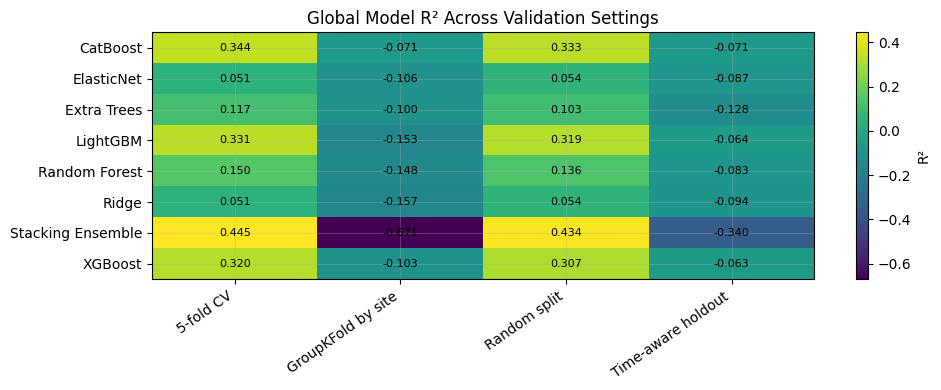

,Dataset,Model,Random_R2,KFold_R2,Site_R2,Time_R2,Site_Generalisation_Gap,Temporal_Generalisation_Gap,Mean_Transfer_R2
6,Global,Stacking Ensemble,0.434476,0.444904,-0.671295,-0.340391,1.105770,0.774866,-0.505843
0,Global,CatBoost,0.332604,0.343968,-0.070906,-0.070969,0.403510,0.403572,-0.070938
3,Global,LightGBM,0.319339,0.331219,-0.152794,-0.064375,0.472133,0.383714,-0.108585
7,Global,XGBoost,0.307211,0.320096,-0.102613,-0.062955,0.409823,0.370165,-0.082784
4,Global,Random Forest,0.135783,0.150323,-0.147706,-0.082703,0.283489,0.218485,-0.115204
2,Global,Extra Trees,0.103328,0.116969,-0.100313,-0.128255,0.203642,0.231583,-0.114284
5,Global,Ridge,0.053782,0.051460,-0.157172,-0.093516,0.210954,0.147299,-0.125344
1,Global,ElasticNet,0.053529,0.051399,-0.106167,-0.087089,0.159696,0.140618,-0.096628


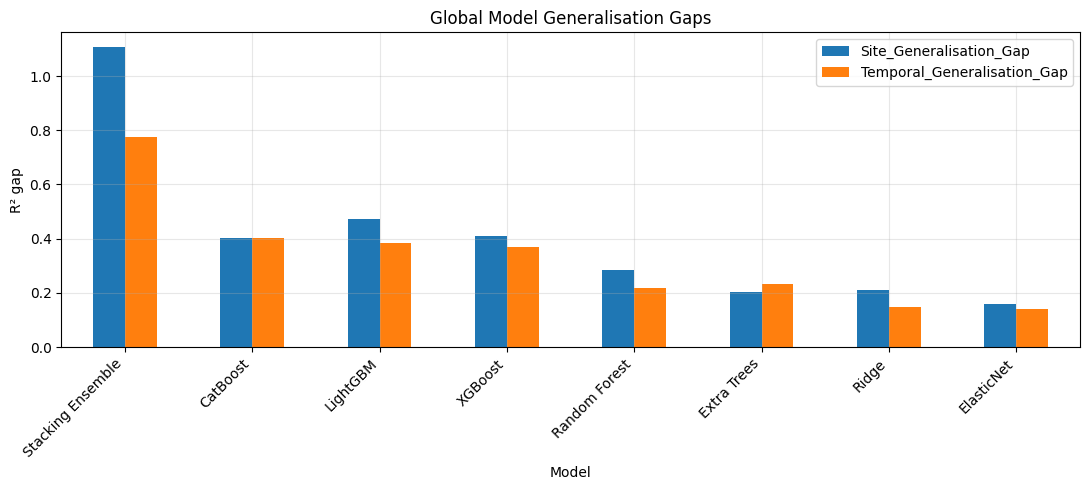

In [19]:
global_r2_pivot = make_r2_pivot(global_results)
display(global_r2_pivot)
global_r2_pivot.to_csv(TABLE_DIR / "global_model_r2_pivot.csv")

plot_r2_heatmap(
    global_r2_pivot,
    "Global Model R² Across Validation Settings",
    "global_model_r2_heatmap.png"
)

global_gap_df = compute_generalisation_gaps(global_results).sort_values("Random_R2", ascending=False)
display(global_gap_df)
global_gap_df.to_csv(TABLE_DIR / "global_model_generalisation_gaps.csv", index=False)

plot_cols = ["Site_Generalisation_Gap", "Temporal_Generalisation_Gap"]
ax = global_gap_df.set_index("Model")[plot_cols].plot(kind="bar", figsize=(11, 5))
ax.set_ylabel("R² gap")
ax.set_title("Global Model Generalisation Gaps")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "global_model_generalisation_gaps.png", dpi=300, bbox_inches="tight")
plt.show()

15. Transfer-aware component-removal ablation

The original cumulative feature-block analysis is replaced by a component-removal
ablation. Starting from the complete governed ecological feature set, each
ecological component is removed in turn and evaluated under the same random,
random K-fold, site-aware and temporal protocols. This tests whether different
feature groups contribute differently to interpolation and ecological transfer.

Running ablation: Full (20 features)


Running ablation: Full - Soil (12 features)
Running ablation: Full - Climate (13 features)
Running ablation: Full - Spatial (18 features)
Running ablation: Full - Temporal (18 features)
Running ablation: Full - Land Cover (19 features)


,Feature_Set,Setting,Model,N_Features,R2,MAE,RMSE,R2_SD,MAE_SD,RMSE_SD,N_Folds,Holdout_Year,Delta_R2_vs_Full
0,Full,Random split,XGBoost,20,0.307211,3.747992,4.155936,NaN,NaN,NaN,NaN,NaN,0.000000
1,Full,5-fold CV,XGBoost,20,0.320096,3.718409,4.101501,0.011322,0.026230,0.038320,5.0,NaN,0.000000
2,Full,GroupKFold by site,XGBoost,20,-0.102613,4.314006,5.196000,0.067020,0.287390,0.462284,5.0,NaN,0.000000
3,Full,Time-aware holdout,XGBoost,20,-0.062955,2.690611,2.971466,NaN,NaN,NaN,NaN,2018.0,0.000000
4,Full - Soil,Random split,XGBoost,12,0.336209,3.657678,4.068028,NaN,NaN,NaN,NaN,NaN,0.028999
5,Full - Soil,5-fold CV,XGBoost,12,0.349914,3.624694,4.010539,0.011556,0.026966,0.039687,5.0,NaN,0.029819
6,Full - Soil,GroupKFold by site,XGBoost,12,-0.097446,4.309667,5.179902,0.071112,0.263658,0.411845,5.0,NaN,0.005166
7,Full - Soil,Time-aware holdout,XGBoost,12,-0.465570,3.021677,3.489126,NaN,NaN,NaN,NaN,2018.0,-0.402615
8,Full - Climate,Random split,XGBoost,13,0.296439,3.781127,4.188120,NaN,NaN,NaN,NaN,NaN,-0.010771
9,Full - Climate,5-fold CV,XGBoost,13,0.307794,3.759686,4.138411,0.011924,0.021988,0.036882,5.0,NaN,-0.012302


Setting,5-fold CV,GroupKFold by site,Random split,Time-aware holdout
Feature_Set,,,,
Full,0.320096,-0.102613,0.307211,-0.062955
Full - Climate,0.307794,-0.006643,0.296439,-0.256663
Full - Land Cover,0.319638,-0.090400,0.306181,-0.059173
Full - Soil,0.349914,-0.097446,0.336209,-0.465570
Full - Spatial,0.320021,-0.111496,0.307313,-0.041636
Full - Temporal,0.318945,-0.098096,0.306089,-0.092344


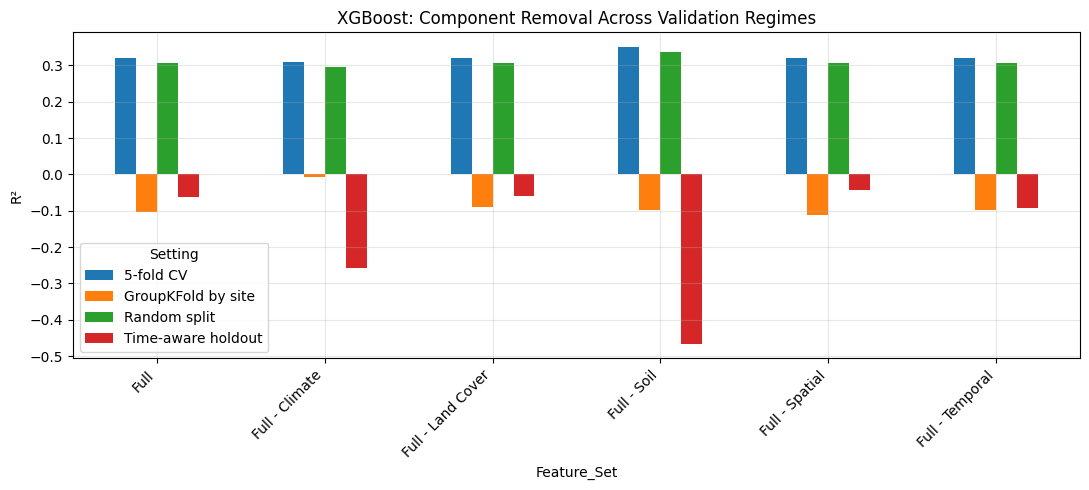

In [20]:
ablation_model = (
    "XGBoost"
    if XGBOOST_AVAILABLE
    else MODEL_NAMES[0]
)

ablation_feature_sets = {
    "Full":
        ecological_features,

    "Full - Soil":
        [
            f for f in ecological_features
            if f not in soil_features
        ],

    "Full - Climate":
        [
            f for f in ecological_features
            if f not in climate_features
        ],

    "Full - Spatial":
        [
            f for f in ecological_features
            if f not in spatial_features
        ],

    "Full - Temporal":
        [
            f for f in ecological_features
            if f not in temporal_features
        ],

    "Full - Land Cover":
        [
            f for f in ecological_features
            if f not in land_cover_features
        ]
}

ablation_rows = []

for (
    ablation_name,
    feature_list
) in ablation_feature_sets.items():

    selected_features = [
        c for c in feature_list
        if c in model_df.columns
    ]

    X_ablation = (
        model_df[
            selected_features
        ]
        .copy()
    )

    y_ablation = (
        model_df[target]
        .copy()
    )

    print(
        f"Running ablation: "
        f"{ablation_name} "
        f"({len(selected_features)} features)"
    )

    # --------------------------------------------------------
    # Random
    # --------------------------------------------------------
    (
        random_metrics,
        *_
    ) = random_split_evaluation(
        X_ablation,
        y_ablation,
        ablation_model
    )

    ablation_rows.append({
        "Feature_Set": ablation_name,
        "Setting": "Random split",
        "Model": ablation_model,
        "N_Features":
            len(selected_features),
        **random_metrics
    })

    # --------------------------------------------------------
    # Random K-fold
    # --------------------------------------------------------
    kf_df = kfold_evaluation(
        X_ablation,
        y_ablation,
        ablation_model,
        n_splits=5
    )

    kf_summary = summarize_cv(
        kf_df,
        "5-fold CV"
    )

    ablation_rows.append({
        "Feature_Set": ablation_name,
        "Model": ablation_model,
        "N_Features":
            len(selected_features),
        **kf_summary
    })

    # --------------------------------------------------------
    # Site transfer
    # --------------------------------------------------------
    site_df = groupkfold_evaluation(
        X_ablation,
        y_ablation,
        site_groups_global,
        ablation_model,
        n_splits=5
    )

    site_summary = summarize_cv(
        site_df,
        "GroupKFold by site"
    )

    ablation_rows.append({
        "Feature_Set": ablation_name,
        "Model": ablation_model,
        "N_Features":
            len(selected_features),
        **site_summary
    })

    # --------------------------------------------------------
    # Temporal transfer
    # --------------------------------------------------------
    time_metrics = (
        time_aware_holdout_evaluation(
            X_ablation,
            y_ablation,
            years_global,
            ablation_model
        )
    )

    holdout_year = (
        time_metrics.pop(
            "Holdout_Year"
        )
    )

    ablation_rows.append({
        "Feature_Set": ablation_name,
        "Setting":
            "Time-aware holdout",
        "Model": ablation_model,
        "N_Features":
            len(selected_features),
        "Holdout_Year":
            holdout_year,
        **time_metrics
    })


transfer_ablation_results = pd.DataFrame(
    ablation_rows
)

# ------------------------------------------------------------
# Calculate delta from complete feature set within each setting.
# ------------------------------------------------------------
full_scores = (
    transfer_ablation_results[
        transfer_ablation_results[
            "Feature_Set"
        ] == "Full"
    ]
    .set_index("Setting")["R2"]
    .to_dict()
)

transfer_ablation_results[
    "Delta_R2_vs_Full"
] = transfer_ablation_results.apply(
    lambda row:
        row["R2"]
        - full_scores.get(
            row["Setting"],
            np.nan
        ),
    axis=1
)

display(
    transfer_ablation_results
)

transfer_ablation_results.to_csv(
    TABLE_DIR
    / "transfer_aware_component_ablation.csv",
    index=False
)

ablation_pivot = (
    transfer_ablation_results
    .pivot(
        index="Feature_Set",
        columns="Setting",
        values="R2"
    )
)

display(
    ablation_pivot
)

ablation_pivot.to_csv(
    TABLE_DIR
    / "transfer_aware_ablation_r2_pivot.csv"
)

ax = ablation_pivot.plot(
    kind="bar",
    figsize=(11, 5)
)

ax.set_ylabel("R²")
ax.set_title(
    f"{ablation_model}: "
    "Component Removal Across Validation Regimes"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR
    / "transfer_aware_component_ablation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Feature-governance diagnostic ablation

To examine whether leakage-aware feature governance materially affects benchmark
performance, we perform a diagnostic ablation using the global task and XGBoost.

The approved benchmark uses only the 20 governed ecological predictors. We then
progressively relax the governance policy by adding representative variables
that are deliberately excluded from the benchmark: direct site/plot identifiers,
assay metadata, and laboratory or target-proximal quantities.

These governance-relaxed configurations are diagnostic only and are not valid
benchmark submissions. They are evaluated under the same fixed random,
site-aware, and temporal partitions as the main benchmark.

The objective is to determine whether prohibited metadata can artificially
increase interpolation performance or alter apparent transfer performance,
thereby empirically testing the need for conservative feature governance.

FEATURE-GOVERNANCE DIAGNOSTIC ABLATION
Model: XGBoost
Benchmark rows: 47435
Master/model-ready alignment: 47435 rows

Governed benchmark predictors:
  20 ecological features

Direct identifier block:
  siteID_x                            unique=42
  plotID_x                            unique=463

Assay / sampling metadata block:
  targetGene                          unique=2
  targetTaxonGroup                    unique=4
  sampleMaterial_x                    unique=2
  laboratoryName_x                    unique=2

Laboratory / target-proximal block:
  copyNumberStandardDeviation         unique=7869
  meanCqValue                         unique=314
  nucleicAcidConcentration_x          unique=452

Configurations:
  Governed ecological              20 predictors
  Governed + identifiers           22 predictors
  Governed + assay metadata        24 predictors
  Governed + target-proximal       23 predictors
  Governance relaxed - all         29 predictors

---------------------------------

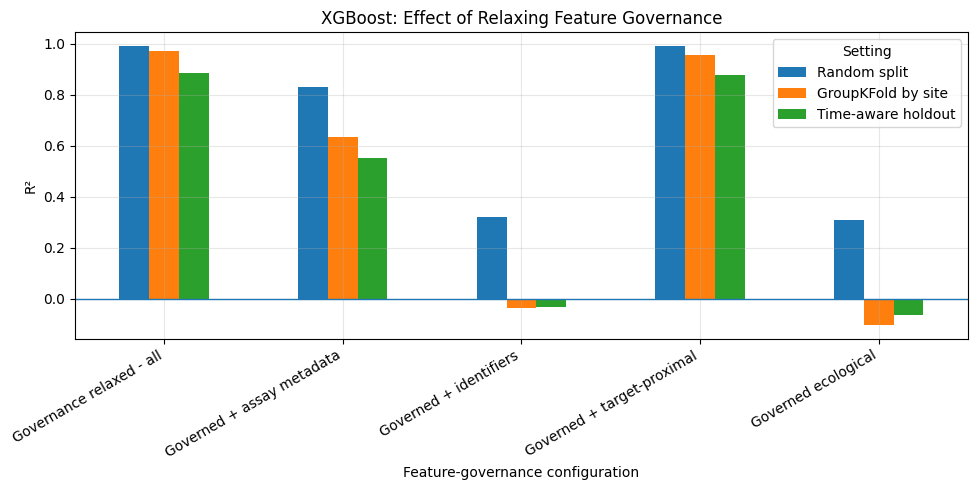


INTERPRETATION

The 'Governed ecological' configuration is the only valid benchmark feature set.

Governance-relaxed configurations are diagnostic experiments only.

If prohibited metadata substantially improves random-split R² but provides little or no improvement under site/time transfer, that is evidence of shortcut learning and supports the benchmark's feature-governance policy.

If target-proximal variables improve performance strongly, this should be interpreted as evidence that measurement-process information can artificially inflate prediction, NOT as a valid modelling improvement.

No conclusions should be written until the actual random, site-aware and temporal results have been inspected.

Feature-governance diagnostic ablation completed.


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


required_objects = [
    "df",
    "df_clean",
    "model_df",
    "model_mask",
    "available_features",
    "target",
    "X_global",
    "y_global",
    "site_groups_global",
    "years_global",
    "TABLE_DIR",
    "FIG_DIR",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Missing prerequisite objects: "
        + ", ".join(missing_objects)
    )

if "XGBoost" in MODEL_NAMES:
    GOVERNANCE_MODEL = "XGBoost"

elif "CatBoost" in MODEL_NAMES:
    GOVERNANCE_MODEL = "CatBoost"

else:
    GOVERNANCE_MODEL = MODEL_NAMES[0]


print("=" * 75)
print("FEATURE-GOVERNANCE DIAGNOSTIC ABLATION")
print("=" * 75)

print("Model:", GOVERNANCE_MODEL)
print("Benchmark rows:", len(model_df))


raw_aligned = (
    df.loc[model_mask]
    .copy()
    .reset_index(drop=True)
)


if len(raw_aligned) != len(model_df):
    raise RuntimeError(
        "Master dataset and model-ready dataset are not aligned."
    )


print(
    "Master/model-ready alignment:",
    len(raw_aligned),
    "rows"
)

def existing_columns(
    dataframe,
    candidates
):
    return [
        col
        for col in candidates
        if col in dataframe.columns
    ]



identifier_candidates = [
    "siteID_x",
    "plotID_x",
]

identifier_features = existing_columns(
    raw_aligned,
    identifier_candidates
)

# Remove constant / non-informative columns
identifier_features = [
    c for c in identifier_features
    if raw_aligned[c].nunique(dropna=True) > 1
]


assay_candidates = [
    "targetGene",
    "targetTaxonGroup",
    "sampleMaterial_x",
    "sampleMaterial",
    "sampleCondition",
    "laboratoryName_x",
    "laboratoryName",
    "inhibitorRemovalRequired",
]

assay_features = existing_columns(
    raw_aligned,
    assay_candidates
)

# Remove constant / non-informative columns
assay_features = [
    c for c in assay_features
    if raw_aligned[c].nunique(dropna=True) > 1
]

target_proximal_candidates = [
    "copyNumberStandardDeviation",
    "meanCqValue",
    "nucleicAcidConcentration_x",
    "nucleicAcidConcentration",
]

target_proximal_features = existing_columns(
    raw_aligned,
    target_proximal_candidates
)

# Remove constant / non-informative columns
target_proximal_features = [
    c for c in target_proximal_features
    if raw_aligned[c].nunique(dropna=True) > 1
]


print("\nGoverned benchmark predictors:")
print(
    f"  {len(available_features)} ecological features"
)


def print_feature_block(
    name,
    feature_list
):
    print(f"\n{name}:")

    if len(feature_list) == 0:
        print("  No matching variables available.")
        return

    for feature in feature_list:

        unique_count = (
            raw_aligned[
                feature
            ]
            .nunique(
                dropna=True
            )
        )

        print(
            f"  {feature:<35} "
            f"unique={unique_count}"
        )


print_feature_block(
    "Direct identifier block",
    identifier_features
)

print_feature_block(
    "Assay / sampling metadata block",
    assay_features
)

print_feature_block(
    "Laboratory / target-proximal block",
    target_proximal_features
)


governance_base = (
    model_df[
        available_features
    ]
    .copy()
    .reset_index(drop=True)
)


def add_raw_features(
    base_df,
    raw_df,
    features
):
    """
    Add selected master-data columns to a copy of the governed
    ecological predictor matrix.
    """

    result = (
        base_df
        .copy()
        .reset_index(drop=True)
    )

    for feature in features:

        if feature in result.columns:
            continue

        result[feature] = (
            raw_df[
                feature
            ]
            .reset_index(drop=True)
        )

    return result


governance_feature_sets = {}


governance_feature_sets[
    "Governed ecological"
] = governance_base.copy()


if identifier_features:

    governance_feature_sets[
        "Governed + identifiers"
    ] = add_raw_features(
        governance_base,
        raw_aligned,
        identifier_features
    )


if assay_features:

    governance_feature_sets[
        "Governed + assay metadata"
    ] = add_raw_features(
        governance_base,
        raw_aligned,
        assay_features
    )


if target_proximal_features:

    governance_feature_sets[
        "Governed + target-proximal"
    ] = add_raw_features(
        governance_base,
        raw_aligned,
        target_proximal_features
    )


all_relaxed_features = list(
    dict.fromkeys(
        identifier_features
        + assay_features
        + target_proximal_features
    )
)

if all_relaxed_features:

    governance_feature_sets[
        "Governance relaxed - all"
    ] = add_raw_features(
        governance_base,
        raw_aligned,
        all_relaxed_features
    )


print("\nConfigurations:")

for name, X_config in (
    governance_feature_sets.items()
):

    print(
        f"  {name:<32} "
        f"{X_config.shape[1]} predictors"
    )


governance_rows = []

governance_site_fold_rows = []


for (
    configuration_name,
    X_config
) in governance_feature_sets.items():

    print("\n" + "-" * 75)

    print(
        "Running:",
        configuration_name
    )

    print(
        "Predictors:",
        X_config.shape[1]
    )


    (
        random_metrics,
        *_,
    ) = random_split_evaluation(
        X_config,
        y_global,
        GOVERNANCE_MODEL,

        split_seed=SEED,
        model_seed=SEED
    )


    governance_rows.append({

        "Configuration":
            configuration_name,

        "Model":
            GOVERNANCE_MODEL,

        "Setting":
            "Random split",

        "N_Predictors_Before_Encoding":
            int(
                X_config.shape[1]
            ),

        **random_metrics
    })

    site_result = (
        groupkfold_evaluation(
            X_config,
            y_global,
            site_groups_global,
            GOVERNANCE_MODEL,

            n_splits=5,
            model_seed=SEED
        )
    )


    
    if isinstance(
        site_result,
        tuple
    ):
        site_df = site_result[0]

    else:
        site_df = site_result


    site_summary = summarize_cv(
        site_df,
        "GroupKFold by site"
    )


    governance_rows.append({

        "Configuration":
            configuration_name,

        "Model":
            GOVERNANCE_MODEL,

        "N_Predictors_Before_Encoding":
            int(
                X_config.shape[1]
            ),

        **site_summary
    })


    temp_site_folds = (
        site_df.copy()
    )

    temp_site_folds[
        "Configuration"
    ] = configuration_name

    temp_site_folds[
        "Model"
    ] = GOVERNANCE_MODEL

    governance_site_fold_rows.append(
        temp_site_folds
    )


    time_metrics = (
        time_aware_holdout_evaluation(
            X_config,
            y_global,
            years_global,
            GOVERNANCE_MODEL,
            model_seed=SEED
        )
    )


    holdout_year = (
        time_metrics.pop(
            "Holdout_Year",
            np.nan
        )
    )


    governance_rows.append({

        "Configuration":
            configuration_name,

        "Model":
            GOVERNANCE_MODEL,

        "Setting":
            "Time-aware holdout",

        "Holdout_Year":
            holdout_year,

        "N_Predictors_Before_Encoding":
            int(
                X_config.shape[1]
            ),

        **time_metrics
    })


governance_ablation_results = (
    pd.DataFrame(
        governance_rows
    )
)


print("\n" + "=" * 75)
print("FEATURE-GOVERNANCE ABLATION RESULTS")
print("=" * 75)


print(
    governance_ablation_results[
        [
            "Configuration",
            "Setting",
            "N_Predictors_Before_Encoding",
            "R2",
            "MAE",
            "RMSE",
        ]
    ]
    .to_string(
        index=False
    )
)


governance_r2_pivot = (
    governance_ablation_results
    .pivot(
        index="Configuration",
        columns="Setting",
        values="R2"
    )
)


desired_setting_order = [
    "Random split",
    "GroupKFold by site",
    "Time-aware holdout",
]

existing_setting_order = [
    setting
    for setting
    in desired_setting_order
    if setting
    in governance_r2_pivot.columns
]

governance_r2_pivot = (
    governance_r2_pivot[
        existing_setting_order
    ]
)


print("\nR² comparison:")

print(
    governance_r2_pivot
    .round(4)
    .to_string()
)


governed_scores = (
    governance_ablation_results[
        governance_ablation_results[
            "Configuration"
        ] == "Governed ecological"
    ]
    .set_index(
        "Setting"
    )[
        "R2"
    ]
    .to_dict()
)


governance_ablation_results[
    "Delta_R2_vs_Governed"
] = (
    governance_ablation_results
    .apply(
        lambda row:
            row["R2"]
            - governed_scores.get(
                row["Setting"],
                np.nan
            ),
        axis=1
    )
)


print(
    "\nChange in R² relative to "
    "the valid governed benchmark:"
)

print(
    governance_ablation_results[
        [
            "Configuration",
            "Setting",
            "R2",
            "Delta_R2_vs_Governed",
        ]
    ]
    .round(4)
    .to_string(
        index=False
    )
)


gap_rows = []


for configuration_name in (
    governance_ablation_results[
        "Configuration"
    ]
    .unique()
):

    current = (
        governance_ablation_results[
            governance_ablation_results[
                "Configuration"
            ] == configuration_name
        ]
    )


    random_values = (
        current[
            current[
                "Setting"
            ] == "Random split"
        ][
            "R2"
        ]
    )


    site_values = (
        current[
            current[
                "Setting"
            ] == "GroupKFold by site"
        ][
            "R2"
        ]
    )


    time_values = (
        current[
            current[
                "Setting"
            ] == "Time-aware holdout"
        ][
            "R2"
        ]
    )


    if (
        len(random_values) == 0
        or len(site_values) == 0
        or len(time_values) == 0
    ):
        continue


    random_r2 = float(
        random_values.iloc[0]
    )

    site_r2 = float(
        site_values.iloc[0]
    )

    time_r2 = float(
        time_values.iloc[0]
    )


    gap_rows.append({

        "Configuration":
            configuration_name,

        "Random_R2":
            random_r2,

        "Site_R2":
            site_r2,

        "Time_R2":
            time_r2,

        "Site_Gap":
            random_r2
            - site_r2,

        "Temporal_Gap":
            random_r2
            - time_r2,

        "Mean_Transfer_R2":
            (
                site_r2
                + time_r2
            )
            / 2.0
    })


governance_gap_results = pd.DataFrame(
    gap_rows
)


print("\nGovernance-related transfer gaps:")

print(
    governance_gap_results
    .round(4)
    .to_string(
        index=False
    )
)


# ============================================================
# 14. SAVE RESULTS
# ============================================================

governance_ablation_results.to_csv(
    TABLE_DIR
    / "feature_governance_ablation_results.csv",
    index=False
)


governance_r2_pivot.to_csv(
    TABLE_DIR
    / "feature_governance_ablation_r2_pivot.csv"
)


governance_gap_results.to_csv(
    TABLE_DIR
    / "feature_governance_transfer_gaps.csv",
    index=False
)


if governance_site_fold_rows:

    governance_site_fold_results = (
        pd.concat(
            governance_site_fold_rows,
            ignore_index=True
        )
    )

    governance_site_fold_results.to_csv(
        TABLE_DIR
        / "feature_governance_site_fold_results.csv",
        index=False
    )


# ============================================================
# 15. FIGURE
# ============================================================

ax = (
    governance_r2_pivot
    .plot(
        kind="bar",
        figsize=(10, 5)
    )
)


ax.axhline(
    0,
    linewidth=1
)


ax.set_ylabel(
    "R²"
)

ax.set_xlabel(
    "Feature-governance configuration"
)

ax.set_title(
    f"{GOVERNANCE_MODEL}: "
    "Effect of Relaxing Feature Governance"
)


plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()


plt.savefig(
    FIG_DIR
    / "feature_governance_ablation_r2.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 16. INTERPRETATION GUARDRAILS
# ============================================================

print("\n" + "=" * 75)
print("INTERPRETATION")
print("=" * 75)


print(
    "\nThe 'Governed ecological' configuration is the only "
    "valid benchmark feature set."
)


print(
    "\nGovernance-relaxed configurations are diagnostic "
    "experiments only."
)


print(
    "\nIf prohibited metadata substantially improves random-split "
    "R² but provides little or no improvement under site/time "
    "transfer, that is evidence of shortcut learning and supports "
    "the benchmark's feature-governance policy."
)


print(
    "\nIf target-proximal variables improve performance strongly, "
    "this should be interpreted as evidence that measurement-process "
    "information can artificially inflate prediction, NOT as a valid "
    "modelling improvement."
)


print(
    "\nNo conclusions should be written until the actual random, "
    "site-aware and temporal results have been inspected."
)


print(
    "\nFeature-governance diagnostic ablation completed."
)

## 16. Prepare subgroup benchmark datasets

Subgroup modelling checks whether biologically coherent microbial groups are easier to model than a mixed global target. This is important because fungi and bacteria/archaea may respond differently to soil and climate drivers.

In [22]:
if "targetTaxonGroup" not in model_meta.columns:
    raise ValueError("targetTaxonGroup column is required for subgroup benchmarking.")

taxon_lower = model_meta["targetTaxonGroup"].astype(str).str.lower()
fungi_mask = taxon_lower == "fungi"
bacteria_archaea_mask = taxon_lower.isin(["bacteria and archaea", "bacteria", "archaea"])

print("Fungi rows:", int(fungi_mask.sum()))
print("Bacteria/Archaea rows:", int(bacteria_archaea_mask.sum()))

subgroup_summary = pd.DataFrame({
    "Subgroup": ["Fungi", "Bacteria/Archaea"],
    "Rows": [int(fungi_mask.sum()), int(bacteria_archaea_mask.sum())]
})
display(subgroup_summary)
subgroup_summary.to_csv(TABLE_DIR / "subgroup_dataset_summary.csv", index=False)

Fungi rows: 22776
Bacteria/Archaea rows: 24659


,Subgroup,Rows
0,Fungi,22776
1,Bacteria/Archaea,24659


## 17. Subgroup benchmark with selected advanced models

To keep runtime reasonable, subgroup benchmarking focuses on the strongest advanced tabular models and the hybrid blend. This tests whether stronger model families improve subgroup prediction or reduce the spatial and temporal transfer gap.

In [23]:
RUN_ALL_MODELS_FOR_SUBGROUPS = False

if RUN_ALL_MODELS_FOR_SUBGROUPS:
    SUBGROUP_MODEL_NAMES = MODEL_NAMES
else:
    preferred_subgroup_models = [
        "XGBoost",
        "LightGBM",
        "CatBoost",
        "Stacking Ensemble"
    ]

    SUBGROUP_MODEL_NAMES = [
        m for m in preferred_subgroup_models
        if m in MODEL_NAMES
    ]

    if len(SUBGROUP_MODEL_NAMES) == 0:
        SUBGROUP_MODEL_NAMES = (
            MODEL_NAMES[:3]
        )

print(
    "Subgroup models:",
    SUBGROUP_MODEL_NAMES
)

subgroup_results_list = []

subgroup_random_artifacts = {}
subgroup_fold_outputs = {}
subgroup_prediction_outputs = {}
subgroup_split_registries = {}

subgroup_definitions = {
    "Fungi":
        fungi_mask,

    "Bacteria/Archaea":
        bacteria_archaea_mask
}

for (
    subgroup_name,
    subgroup_mask
) in subgroup_definitions.items():

    X_sub = (
        model_df
        .loc[
            subgroup_mask,
            available_features
        ]
        .reset_index(drop=True)
    )

    y_sub = (
        model_df
        .loc[
            subgroup_mask,
            target
        ]
        .reset_index(drop=True)
    )

    meta_sub = (
        model_meta
        .loc[subgroup_mask]
        .reset_index(drop=True)
    )

    subgroup_split_registries[
        subgroup_name
    ] = create_split_registry(
        meta_sub,
        subgroup_name
    )

    site_groups_sub = (
        meta_sub[site_group_col]
        if site_group_col is not None
        else None
    )

    years_sub = (
        meta_sub[year_col]
        if year_col is not None
        else None
    )

    row_ids_sub = (
        meta_sub[
            "_benchmark_row_id"
        ]
        if "_benchmark_row_id"
           in meta_sub.columns
        else None
    )

    (
        results_sub,
        folds_sub,
        artifacts_sub,
        predictions_sub
    ) = run_benchmark(
        X=X_sub,
        y=y_sub,
        model_names=
            SUBGROUP_MODEL_NAMES,
        dataset_label=
            subgroup_name,
        site_groups=
            site_groups_sub,
        years=
            years_sub,
        row_ids=
            row_ids_sub,
        n_splits=5
    )

    subgroup_results_list.append(
        results_sub
    )

    subgroup_random_artifacts[
        subgroup_name
    ] = artifacts_sub

    subgroup_fold_outputs[
        subgroup_name
    ] = folds_sub

    subgroup_prediction_outputs[
        subgroup_name
    ] = predictions_sub


subgroup_results = pd.concat(
    subgroup_results_list,
    ignore_index=True
)

display(
    subgroup_results
)

subgroup_results.to_csv(
    TABLE_DIR
    / "subgroup_selected_model_benchmark_results.csv",
    index=False
)


# ------------------------------------------------------------
# Export subgroup fold-level metrics
# ------------------------------------------------------------
subgroup_fold_parts = []

for dataset_name, store in (
    subgroup_fold_outputs.items()
):

    for (
        model_name,
        setting_name
    ), fold_df in store.items():

        temp = fold_df.copy()

        temp["Dataset"] = (
            dataset_name
        )

        temp["Model"] = (
            model_name
        )

        temp["Setting"] = (
            setting_name
        )

        subgroup_fold_parts.append(
            temp
        )

subgroup_fold_level_metrics = pd.concat(
    subgroup_fold_parts,
    ignore_index=True
)

subgroup_fold_level_metrics.to_csv(
    TABLE_DIR
    / "subgroup_fold_level_metrics.csv",
    index=False
)


# ------------------------------------------------------------
# Export subgroup site-aware OOF predictions
# ------------------------------------------------------------
subgroup_prediction_parts = []

for dataset_name, store in (
    subgroup_prediction_outputs.items()
):

    for (
        model_name,
        setting_name
    ), pred_df in store.items():

        temp = pred_df.copy()

        temp["Dataset"] = (
            dataset_name
        )

        temp["Model"] = (
            model_name
        )

        temp["Setting"] = (
            setting_name
        )

        subgroup_prediction_parts.append(
            temp
        )

subgroup_site_oof_predictions = pd.concat(
    subgroup_prediction_parts,
    ignore_index=True
)

subgroup_site_oof_predictions.to_csv(
    PRED_DIR
    / "subgroup_site_oof_predictions.csv",
    index=False
)

Subgroup models: ['XGBoost', 'LightGBM', 'CatBoost', 'Stacking Ensemble']
Running Fungi: XGBoost
Running Fungi: LightGBM
Running Fungi: CatBoost
Running Fungi: Stacking Ensemble


Running Bacteria/Archaea: XGBoost
Running Bacteria/Archaea: LightGBM
Running Bacteria/Archaea: CatBoost
Running Bacteria/Archaea: Stacking Ensemble


,Dataset,Model,Setting,R2,MAE,RMSE,R2_SD,MAE_SD,RMSE_SD,N_Folds,Holdout_Year
0,Fungi,XGBoost,Random split,0.758835,0.816519,1.333750,NaN,NaN,NaN,NaN,NaN
1,Fungi,XGBoost,5-fold CV,0.743459,0.820859,1.373625,0.011722,0.017392,0.048278,5.0,NaN
2,Fungi,XGBoost,GroupKFold by site,-0.081935,1.852129,2.735940,0.208281,0.405621,0.710550,5.0,NaN
3,Fungi,XGBoost,Time-aware holdout,-1.200109,1.589264,1.903159,NaN,NaN,NaN,NaN,2018.0
4,Fungi,LightGBM,Random split,0.779583,0.792987,1.275086,NaN,NaN,NaN,NaN,NaN
5,Fungi,LightGBM,5-fold CV,0.762623,0.802768,1.321221,0.012570,0.016922,0.049331,5.0,NaN
6,Fungi,LightGBM,GroupKFold by site,-0.188525,1.938403,2.853627,0.291256,0.500541,0.752131,5.0,NaN
7,Fungi,LightGBM,Time-aware holdout,-1.197514,1.566068,1.902036,NaN,NaN,NaN,NaN,2018.0
8,Fungi,CatBoost,Random split,0.749998,0.884324,1.357968,NaN,NaN,NaN,NaN,NaN
9,Fungi,CatBoost,5-fold CV,0.737168,0.891152,1.390454,0.009457,0.018839,0.043575,5.0,NaN


## 18. Subgroup benchmark visualisation and gap analysis

These tables and plots compare whether the advanced models and hybrid blend perform better for biologically separated targets. The key interpretation is not only which model has the highest random R², but whether any model reduces the transfer gap.

,Dataset,Model,Random_R2,KFold_R2,Site_R2,Time_R2,Site_Generalisation_Gap,Temporal_Generalisation_Gap,Mean_Transfer_R2
2,Bacteria/Archaea,Stacking Ensemble,0.576294,0.600968,-0.602566,-2.269810,1.178860,2.846104,-1.436188
0,Bacteria/Archaea,CatBoost,0.557281,0.580883,-0.183194,-0.856931,0.740475,1.414211,-0.520062
1,Bacteria/Archaea,LightGBM,0.556732,0.586159,-0.285904,-1.022064,0.842636,1.578796,-0.653984
3,Bacteria/Archaea,XGBoost,0.527076,0.564069,-0.312498,-2.418344,0.839574,2.945421,-1.365421
6,Fungi,Stacking Ensemble,0.786828,0.768465,-0.573302,-1.743752,1.360130,2.530580,-1.158527
5,Fungi,LightGBM,0.779583,0.762623,-0.188525,-1.197514,0.968108,1.977097,-0.693019
7,Fungi,XGBoost,0.758835,0.743459,-0.081935,-1.200109,0.840770,1.958944,-0.641022
4,Fungi,CatBoost,0.749998,0.737168,-0.087739,-1.085750,0.837737,1.835747,-0.586744


Setting,5-fold CV,GroupKFold by site,Random split,Time-aware holdout
Model,,,,
CatBoost,0.737168,-0.087739,0.749998,-1.085750
LightGBM,0.762623,-0.188525,0.779583,-1.197514
Stacking Ensemble,0.768465,-0.573302,0.786828,-1.743752
XGBoost,0.743459,-0.081935,0.758835,-1.200109


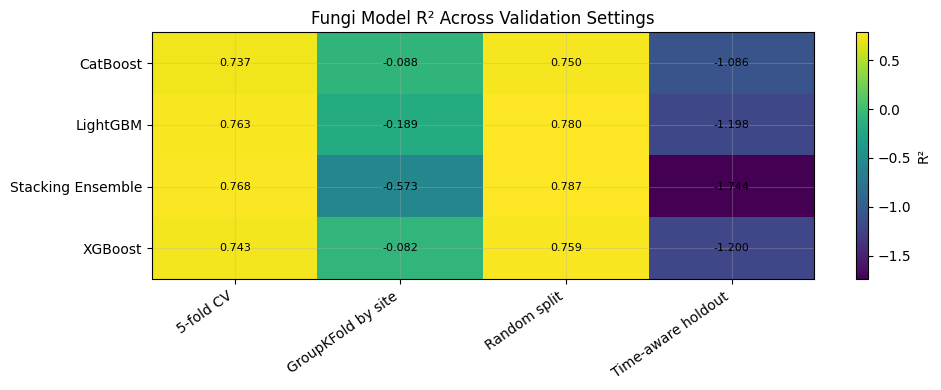

Setting,5-fold CV,GroupKFold by site,Random split,Time-aware holdout
Model,,,,
CatBoost,0.580883,-0.183194,0.557281,-0.856931
LightGBM,0.586159,-0.285904,0.556732,-1.022064
Stacking Ensemble,0.600968,-0.602566,0.576294,-2.269810
XGBoost,0.564069,-0.312498,0.527076,-2.418344


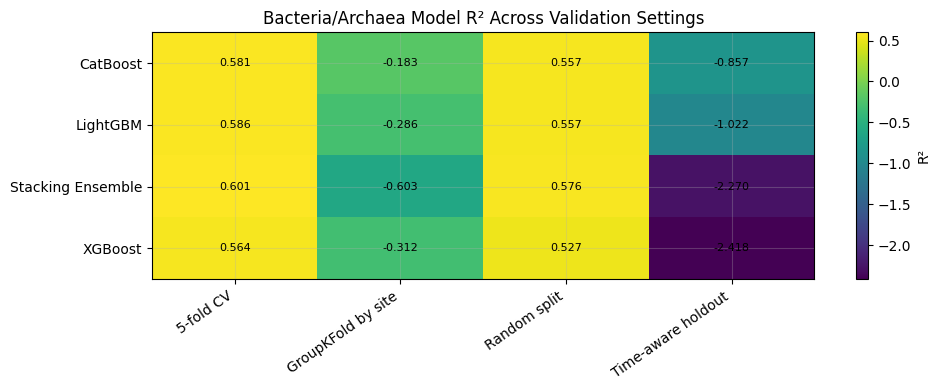

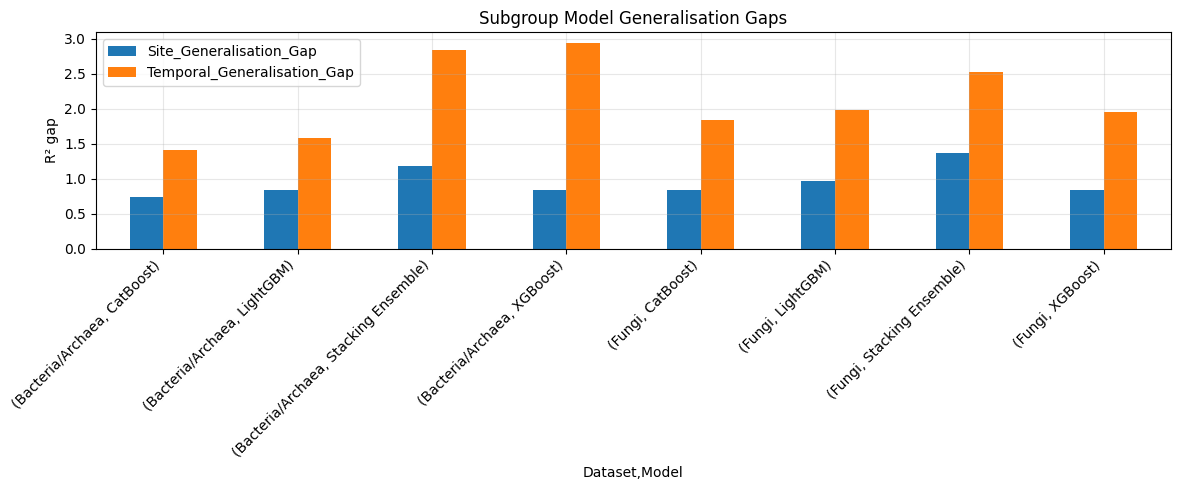

In [24]:
subgroup_gap_df = compute_generalisation_gaps(subgroup_results).sort_values(["Dataset", "Random_R2"], ascending=[True, False])
display(subgroup_gap_df)
subgroup_gap_df.to_csv(TABLE_DIR / "subgroup_model_generalisation_gaps.csv", index=False)

for subgroup_name in subgroup_results["Dataset"].unique():
    subgroup_pivot = make_r2_pivot(subgroup_results[subgroup_results["Dataset"] == subgroup_name])
    display(subgroup_pivot)
    subgroup_pivot.to_csv(TABLE_DIR / f"{subgroup_name.lower().replace('/', '_').replace(' ', '_')}_model_r2_pivot.csv")
    plot_r2_heatmap(
        subgroup_pivot,
        f"{subgroup_name} Model R² Across Validation Settings",
        f"{subgroup_name.lower().replace('/', '_').replace(' ', '_')}_model_r2_heatmap.png"
    )

ax = subgroup_gap_df.pivot_table(
    index=["Dataset", "Model"],
    values=["Site_Generalisation_Gap", "Temporal_Generalisation_Gap"],
    aggfunc="mean"
).plot(kind="bar", figsize=(12, 5))
ax.set_ylabel("R² gap")
ax.set_title("Subgroup Model Generalisation Gaps")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "subgroup_model_generalisation_gaps.png", dpi=300, bbox_inches="tight")
plt.show()

## 19. Combined benchmark summary

This cell we have run to make our paper writing easier. To explain results better.

In [25]:
combined_results = pd.concat([global_results, subgroup_results], ignore_index=True)
combined_results.to_csv(TABLE_DIR / "combined_global_and_subgroup_benchmark_results.csv", index=False)

gap_all_df = compute_generalisation_gaps(combined_results).sort_values(["Dataset", "Random_R2"], ascending=[True, False])
display(gap_all_df)
gap_all_df.to_csv(TABLE_DIR / "combined_generalisation_gap_summary.csv", index=False)

best_random_by_dataset = gap_all_df.sort_values("Random_R2", ascending=False).groupby("Dataset").head(3)
display(best_random_by_dataset)
best_random_by_dataset.to_csv(TABLE_DIR / "top_models_by_random_r2_each_dataset.csv", index=False)

best_transfer_by_dataset = gap_all_df.sort_values("Mean_Transfer_R2", ascending=False).groupby("Dataset").head(3)
display(best_transfer_by_dataset)
best_transfer_by_dataset.to_csv(TABLE_DIR / "top_models_by_transfer_r2_each_dataset.csv", index=False)

,Dataset,Model,Random_R2,KFold_R2,Site_R2,Time_R2,Site_Generalisation_Gap,Temporal_Generalisation_Gap,Mean_Transfer_R2
2,Bacteria/Archaea,Stacking Ensemble,0.576294,0.600968,-0.602566,-2.269810,1.178860,2.846104,-1.436188
0,Bacteria/Archaea,CatBoost,0.557281,0.580883,-0.183194,-0.856931,0.740475,1.414211,-0.520062
1,Bacteria/Archaea,LightGBM,0.556732,0.586159,-0.285904,-1.022064,0.842636,1.578796,-0.653984
3,Bacteria/Archaea,XGBoost,0.527076,0.564069,-0.312498,-2.418344,0.839574,2.945421,-1.365421
6,Fungi,Stacking Ensemble,0.786828,0.768465,-0.573302,-1.743752,1.360130,2.530580,-1.158527
5,Fungi,LightGBM,0.779583,0.762623,-0.188525,-1.197514,0.968108,1.977097,-0.693019
7,Fungi,XGBoost,0.758835,0.743459,-0.081935,-1.200109,0.840770,1.958944,-0.641022
4,Fungi,CatBoost,0.749998,0.737168,-0.087739,-1.085750,0.837737,1.835747,-0.586744
14,Global,Stacking Ensemble,0.434476,0.444904,-0.671295,-0.340391,1.105770,0.774866,-0.505843
8,Global,CatBoost,0.332604,0.343968,-0.070906,-0.070969,0.403510,0.403572,-0.070938


,Dataset,Model,Random_R2,KFold_R2,Site_R2,Time_R2,Site_Generalisation_Gap,Temporal_Generalisation_Gap,Mean_Transfer_R2
6,Fungi,Stacking Ensemble,0.786828,0.768465,-0.573302,-1.743752,1.360130,2.530580,-1.158527
5,Fungi,LightGBM,0.779583,0.762623,-0.188525,-1.197514,0.968108,1.977097,-0.693019
7,Fungi,XGBoost,0.758835,0.743459,-0.081935,-1.200109,0.840770,1.958944,-0.641022
2,Bacteria/Archaea,Stacking Ensemble,0.576294,0.600968,-0.602566,-2.269810,1.178860,2.846104,-1.436188
0,Bacteria/Archaea,CatBoost,0.557281,0.580883,-0.183194,-0.856931,0.740475,1.414211,-0.520062
1,Bacteria/Archaea,LightGBM,0.556732,0.586159,-0.285904,-1.022064,0.842636,1.578796,-0.653984
14,Global,Stacking Ensemble,0.434476,0.444904,-0.671295,-0.340391,1.105770,0.774866,-0.505843
8,Global,CatBoost,0.332604,0.343968,-0.070906,-0.070969,0.403510,0.403572,-0.070938
11,Global,LightGBM,0.319339,0.331219,-0.152794,-0.064375,0.472133,0.383714,-0.108585


,Dataset,Model,Random_R2,KFold_R2,Site_R2,Time_R2,Site_Generalisation_Gap,Temporal_Generalisation_Gap,Mean_Transfer_R2
8,Global,CatBoost,0.332604,0.343968,-0.070906,-0.070969,0.403510,0.403572,-0.070938
15,Global,XGBoost,0.307211,0.320096,-0.102613,-0.062955,0.409823,0.370165,-0.082784
9,Global,ElasticNet,0.053529,0.051399,-0.106167,-0.087089,0.159696,0.140618,-0.096628
0,Bacteria/Archaea,CatBoost,0.557281,0.580883,-0.183194,-0.856931,0.740475,1.414211,-0.520062
4,Fungi,CatBoost,0.749998,0.737168,-0.087739,-1.085750,0.837737,1.835747,-0.586744
7,Fungi,XGBoost,0.758835,0.743459,-0.081935,-1.200109,0.840770,1.958944,-0.641022
1,Bacteria/Archaea,LightGBM,0.556732,0.586159,-0.285904,-1.022064,0.842636,1.578796,-0.653984
5,Fungi,LightGBM,0.779583,0.762623,-0.188525,-1.197514,0.968108,1.977097,-0.693019
3,Bacteria/Archaea,XGBoost,0.527076,0.564069,-0.312498,-2.418344,0.839574,2.945421,-1.365421


## 20. Benchmark versioning and reproducibility manifest

This section freezes the benchmark version, dataset checksum, software
environment, feature definitions, model configuration and split artifacts.

In [26]:
def sha256_file(path):
    sha = hashlib.sha256()

    with open(path, "rb") as f:
        for block in iter(
            lambda: f.read(1024 * 1024),
            b""
        ):
            sha.update(block)

    return sha.hexdigest()


dataset_sha256 = sha256_file(
    DATA_FILE
)

package_versions = {
    "python":
        platform.python_version(),

    "numpy":
        np.__version__,

    "pandas":
        pd.__version__,

    "scikit-learn":
        sklearn.__version__,

    "scipy":
        scipy.__version__,

    "statsmodels":
        statsmodels.__version__,
}

if XGBOOST_AVAILABLE:
    package_versions[
        "xgboost"
    ] = xgboost.__version__

if LIGHTGBM_AVAILABLE:
    package_versions[
        "lightgbm"
    ] = lightgbm.__version__

if CATBOOST_AVAILABLE:
    package_versions[
        "catboost"
    ] = catboost.__version__

if SHAP_AVAILABLE:
    package_versions[
        "shap"
    ] = shap.__version__


benchmark_manifest = {
    "benchmark_version":
        BENCHMARK_VERSION,

    "dataset_file":
        DATA_FILE,

    "dataset_sha256":
        dataset_sha256,

    "n_rows":
        int(len(model_df)),

    "target":
        target,

    "target_definition":
        "log1p(meanCopyNumber)",

    "n_predictors":
        int(len(available_features)),

    "predictors":
        available_features,

    "random_seed":
        SEED,

    "random_test_fraction":
        0.20,

    "random_kfold":
        5,

    "site_group_kfold":
        5,

    "temporal_holdout_year":
        int(
            pd.to_numeric(
                years_global,
                errors="coerce"
            ).max()
        ),

    "models":
        MODEL_NAMES,

    "stacking_base_models":
        STACKING_BASE_NAMES,

    "software":
        package_versions
}


with open(
    REPRO_DIR
    / "benchmark_manifest.json",
    "w"
) as f:
    json.dump(
        benchmark_manifest,
        f,
        indent=2,
        default=str
    )


with open(
    REPRO_DIR
    / "dataset_sha256.txt",
    "w"
) as f:
    f.write(
        dataset_sha256 + "\n"
    )


with open(
    REPRO_DIR
    / "requirements_exact.txt",
    "w"
) as f:
    for package, version in (
        package_versions.items()
    ):
        f.write(
            f"{package}=={version}\n"
        )


model_config = {}

for model_name in MODEL_NAMES:

    if model_name == "Stacking Ensemble":
        model_config[
            model_name
        ] = {
            "base_models":
                STACKING_BASE_NAMES,

            "meta_learner":
                "Ridge(alpha=1.0)",

            "internal_cv":
                5,

            "strict_nested_preprocessing":
                True
        }

    else:
        model_config[
            model_name
        ] = (
            build_model(
                model_name
            )
            .get_params()
        )


with open(
    REPRO_DIR
    / "model_configuration.json",
    "w"
) as f:
    json.dump(
        model_config,
        f,
        indent=2,
        default=str
    )


display(
    pd.DataFrame(
        list(
            package_versions.items()
        ),
        columns=[
            "Package",
            "Version"
        ]
    )
)

print(
    "Dataset SHA-256:",
    dataset_sha256
)

,Package,Version
0,python,3.10.12
1,numpy,1.26.4
2,pandas,2.2.3
3,scikit-learn,1.4.0
4,scipy,1.15.3
5,statsmodels,0.14.1
6,xgboost,3.0.5
7,lightgbm,4.7.0
8,catboost,1.2.10
9,shap,0.49.1


Dataset SHA-256: cff5fd92d008bda738a7079f81e37c49ef3f62f1ad2641b7ba5f60873ebed671


## 21. Statistical robustness and repeated-run analysis

To assess whether benchmark results are stable across model randomness,
stochastic models are evaluated across multiple fixed random seeds while
preserving the benchmark split definitions. Repeated-run variability is
reported separately from variation across validation folds.

In [27]:
ROBUSTNESS_MODELS = [
    model_name
    for model_name in [
        "XGBoost",
        "LightGBM",
        "CatBoost",
        "Stacking Ensemble"
    ]
    if model_name in MODEL_NAMES
]

ROBUSTNESS_SEEDS = [
    42,
    52,
    62,
    72,
    82
]

print("Repeated-run models:")
print(ROBUSTNESS_MODELS)

print("\nRepeated-run seeds:")
print(ROBUSTNESS_SEEDS)


global_bundle = {
    "X":
        X_global.reset_index(drop=True),

    "y":
        y_global.reset_index(drop=True),

    "meta":
        model_meta.reset_index(drop=True)
}


fungi_X = (
    model_df
    .loc[
        fungi_mask,
        available_features
    ]
    .reset_index(drop=True)
)

fungi_y = (
    model_df
    .loc[
        fungi_mask,
        target
    ]
    .reset_index(drop=True)
)

fungi_meta = (
    model_meta
    .loc[
        fungi_mask
    ]
    .reset_index(drop=True)
)



bacteria_archaea_X = (
    model_df
    .loc[
        bacteria_archaea_mask,
        available_features
    ]
    .reset_index(drop=True)
)

bacteria_archaea_y = (
    model_df
    .loc[
        bacteria_archaea_mask,
        target
    ]
    .reset_index(drop=True)
)

bacteria_archaea_meta = (
    model_meta
    .loc[
        bacteria_archaea_mask
    ]
    .reset_index(drop=True)
)


benchmark_bundles = {

    "Global": {
        "X":
            global_bundle["X"],

        "y":
            global_bundle["y"],

        "meta":
            global_bundle["meta"]
    },

    "Fungi": {
        "X":
            fungi_X,

        "y":
            fungi_y,

        "meta":
            fungi_meta
    },

    "Bacteria/Archaea": {
        "X":
            bacteria_archaea_X,

        "y":
            bacteria_archaea_y,

        "meta":
            bacteria_archaea_meta
    }
}


repeated_run_rows = []
repeated_fold_rows = []


for dataset_name, bundle in benchmark_bundles.items():

    print("\n" + "=" * 70)
    print(
        f"DATASET: {dataset_name}"
    )
    print("=" * 70)

    X_current = (
        bundle["X"]
        .reset_index(drop=True)
    )

    y_current = (
        bundle["y"]
        .reset_index(drop=True)
    )

    meta_current = (
        bundle["meta"]
        .reset_index(drop=True)
    )


    current_site_col = next(
        (
            col
            for col in [
                "siteID",
                "siteID_x"
            ]
            if col in meta_current.columns
        ),
        None
    )

    if current_site_col is None:
        raise ValueError(
            f"No site grouping column found "
            f"for {dataset_name}."
        )

    site_groups_current = (
        meta_current[
            current_site_col
        ]
        .reset_index(drop=True)
    )

    current_year_col = next(
        (
            col
            for col in [
                "year",
                "year_from_date"
            ]
            if col in meta_current.columns
        ),
        None
    )

    if current_year_col is None:
        raise ValueError(
            f"No year column found "
            f"for {dataset_name}."
        )

    years_current = (
        meta_current[
            current_year_col
        ]
        .reset_index(drop=True)
    )


    print(
        "Rows:",
        len(X_current)
    )

    print(
        "Sites:",
        site_groups_current.nunique()
    )

    print(
        "Years:",
        sorted(
            pd.to_numeric(
                years_current,
                errors="coerce"
            )
            .dropna()
            .unique()
        )
    )


    for model_name in ROBUSTNESS_MODELS:

        print(
            f"\nModel: {model_name}"
        )


        for model_seed in ROBUSTNESS_SEEDS:

            print(
                f"  Seed {model_seed}"
            )


            (
                random_metrics,
                _,
                _,
                _,
                _,
                _,
                _
            ) = random_split_evaluation(
                X_current,
                y_current,
                model_name,

                split_seed=SEED,
                model_seed=model_seed
            )


            repeated_run_rows.append({

                "Dataset":
                    dataset_name,

                "Model":
                    model_name,

                "Setting":
                    "Random split",

                "Model_Seed":
                    model_seed,

                "R2":
                    random_metrics["R2"],

                "MAE":
                    random_metrics["MAE"],

                "RMSE":
                    random_metrics["RMSE"],

                "N_Folds":
                    1
            })

            kfold_df = kfold_evaluation(
                X_current,
                y_current,
                model_name,

                n_splits=5,

                split_seed=SEED,

                model_seed=model_seed
            )

            for _, fold_row in kfold_df.iterrows():

                repeated_fold_rows.append({

                    "Dataset":
                        dataset_name,

                    "Model":
                        model_name,

                    "Setting":
                        "5-fold CV",

                    "Model_Seed":
                        model_seed,

                    "Fold":
                        int(
                            fold_row["Fold"]
                        ),

                    "R2":
                        float(
                            fold_row["R2"]
                        ),

                    "MAE":
                        float(
                            fold_row["MAE"]
                        ),

                    "RMSE":
                        float(
                            fold_row["RMSE"]
                        )
                })

            repeated_run_rows.append({

                "Dataset":
                    dataset_name,

                "Model":
                    model_name,

                "Setting":
                    "5-fold CV",

                "Model_Seed":
                    model_seed,

                "R2":
                    float(
                        kfold_df[
                            "R2"
                        ].mean()
                    ),

                "MAE":
                    float(
                        kfold_df[
                            "MAE"
                        ].mean()
                    ),

                "RMSE":
                    float(
                        kfold_df[
                            "RMSE"
                        ].mean()
                    ),

                "N_Folds":
                    int(
                        len(kfold_df)
                    )
            })

            site_df = groupkfold_evaluation(
                X_current,
                y_current,
                site_groups_current,
                model_name,

                n_splits=5,

                model_seed=model_seed
            )


            if isinstance(
                site_df,
                tuple
            ):
                site_df = site_df[0]

            for _, fold_row in site_df.iterrows():

                repeated_fold_rows.append({

                    "Dataset":
                        dataset_name,

                    "Model":
                        model_name,

                    "Setting":
                        "GroupKFold by site",

                    "Model_Seed":
                        model_seed,

                    "Fold":
                        int(
                            fold_row["Fold"]
                        ),

                    "R2":
                        float(
                            fold_row["R2"]
                        ),

                    "MAE":
                        float(
                            fold_row["MAE"]
                        ),

                    "RMSE":
                        float(
                            fold_row["RMSE"]
                        )
                })

            repeated_run_rows.append({

                "Dataset":
                    dataset_name,

                "Model":
                    model_name,

                "Setting":
                    "GroupKFold by site",

                "Model_Seed":
                    model_seed,

                "R2":
                    float(
                        site_df[
                            "R2"
                        ].mean()
                    ),

                "MAE":
                    float(
                        site_df[
                            "MAE"
                        ].mean()
                    ),

                "RMSE":
                    float(
                        site_df[
                            "RMSE"
                        ].mean()
                    ),

                "N_Folds":
                    int(
                        len(site_df)
                    )
            })

            temporal_metrics = (
                time_aware_holdout_evaluation(
                    X_current,
                    y_current,
                    years_current,
                    model_name,

                    model_seed=
                        model_seed
                )
            )


            holdout_year = (
                temporal_metrics.get(
                    "Holdout_Year",
                    np.nan
                )
            )


            repeated_run_rows.append({

                "Dataset":
                    dataset_name,

                "Model":
                    model_name,

                "Setting":
                    "Time-aware holdout",

                "Model_Seed":
                    model_seed,

                "Holdout_Year":
                    holdout_year,

                "R2":
                    temporal_metrics[
                        "R2"
                    ],

                "MAE":
                    temporal_metrics[
                        "MAE"
                    ],

                "RMSE":
                    temporal_metrics[
                        "RMSE"
                    ],

                "N_Folds":
                    1
            })


repeated_run_results = pd.DataFrame(
    repeated_run_rows
)

repeated_fold_results = pd.DataFrame(
    repeated_fold_rows
)


print(
    "\nRepeated run-level results:"
)

display(
    repeated_run_results.head(20)
)


print(
    "\nRepeated fold-level results:"
)

display(
    repeated_fold_results.head(20)
)


repeated_run_summary = (

    repeated_run_results

    .groupby(
        [
            "Dataset",
            "Model",
            "Setting"
        ],
        as_index=False
    )

    .agg(

        R2_Mean=(
            "R2",
            "mean"
        ),

        R2_SD=(
            "R2",
            "std"
        ),

        MAE_Mean=(
            "MAE",
            "mean"
        ),

        MAE_SD=(
            "MAE",
            "std"
        ),

        RMSE_Mean=(
            "RMSE",
            "mean"
        ),

        RMSE_SD=(
            "RMSE",
            "std"
        ),

        N_Runs=(
            "Model_Seed",
            "nunique"
        )
    )
)


expected_runs = len(
    ROBUSTNESS_SEEDS
)

run_check = (

    repeated_run_results

    .groupby(
        [
            "Dataset",
            "Model",
            "Setting"
        ]
    )[
        "Model_Seed"
    ]

    .nunique()

    .reset_index(
        name="N_Runs"
    )
)


problem_runs = (
    run_check[
        run_check[
            "N_Runs"
        ] != expected_runs
    ]
)


if len(problem_runs) == 0:

    print(
        "\n✓ Every dataset/model/setting "
        f"contains exactly {expected_runs} "
        "repeated model runs."
    )

else:

    print(
        "\nWARNING: Some experiments do not "
        "contain the expected number of runs."
    )

    display(
        problem_runs
    )



print(
    "\nRepeated-run robustness summary "
    "(mean ± SD across model seeds):"
)

display(
    repeated_run_summary
    .sort_values(
        [
            "Dataset",
            "Setting",
            "R2_Mean"
        ],
        ascending=[
            True,
            True,
            False
        ]
    )
)


paper_ready_robustness = (
    repeated_run_summary.copy()
)


paper_ready_robustness[
    "R2_mean_SD"
] = (

    paper_ready_robustness[
        "R2_Mean"
    ]
    .map(
        lambda x:
            f"{x:.3f}"
    )

    + " ± "

    + paper_ready_robustness[
        "R2_SD"
    ]
    .map(
        lambda x:
            f"{x:.3f}"
    )
)


paper_ready_robustness[
    "MAE_mean_SD"
] = (

    paper_ready_robustness[
        "MAE_Mean"
    ]
    .map(
        lambda x:
            f"{x:.3f}"
    )

    + " ± "

    + paper_ready_robustness[
        "MAE_SD"
    ]
    .map(
        lambda x:
            f"{x:.3f}"
    )
)


paper_ready_robustness[
    "RMSE_mean_SD"
] = (

    paper_ready_robustness[
        "RMSE_Mean"
    ]
    .map(
        lambda x:
            f"{x:.3f}"
    )

    + " ± "

    + paper_ready_robustness[
        "RMSE_SD"
    ]
    .map(
        lambda x:
            f"{x:.3f}"
    )
)


display(
    paper_ready_robustness[
        [
            "Dataset",
            "Model",
            "Setting",
            "R2_mean_SD",
            "MAE_mean_SD",
            "RMSE_mean_SD",
            "N_Runs"
        ]
    ]
)



repeated_run_results.to_csv(
    TABLE_DIR
    / "repeated_run_results_all_settings.csv",
    index=False
)


repeated_fold_results.to_csv(
    TABLE_DIR
    / "repeated_run_fold_level_results.csv",
    index=False
)


repeated_run_summary.to_csv(
    TABLE_DIR
    / "repeated_run_mean_sd_summary.csv",
    index=False
)


paper_ready_robustness.to_csv(
    TABLE_DIR
    / "repeated_run_paper_ready_summary.csv",
    index=False
)


print(
    "\nSaved:"
)

print(
    TABLE_DIR
    / "repeated_run_results_all_settings.csv"
)

print(
    TABLE_DIR
    / "repeated_run_fold_level_results.csv"
)

print(
    TABLE_DIR
    / "repeated_run_mean_sd_summary.csv"
)

print(
    TABLE_DIR
    / "repeated_run_paper_ready_summary.csv"
)

Repeated-run models:
['XGBoost', 'LightGBM', 'CatBoost', 'Stacking Ensemble']

Repeated-run seeds:
[42, 52, 62, 72, 82]

DATASET: Global
Rows: 47435
Sites: 42
Years: [2013, 2014, 2015, 2016, 2017, 2018]

Model: XGBoost
  Seed 42
  Seed 52


  Seed 62
  Seed 72
  Seed 82

Model: LightGBM
  Seed 42
  Seed 52
  Seed 62
  Seed 72
  Seed 82

Model: CatBoost
  Seed 42
  Seed 52
  Seed 62
  Seed 72
  Seed 82

Model: Stacking Ensemble
  Seed 42
  Seed 52
  Seed 62
  Seed 72
  Seed 82

DATASET: Fungi
Rows: 22776
Sites: 42
Years: [2013, 2014, 2015, 2016, 2017, 2018]

Model: XGBoost
  Seed 42
  Seed 52
  Seed 62
  Seed 72
  Seed 82

Model: LightGBM
  Seed 42
  Seed 52
  Seed 62
  Seed 72
  Seed 82

Model: CatBoost
  Seed 42
  Seed 52
  Seed 62
  Seed 72
  Seed 82

Model: Stacking Ensemble
  Seed 42
  Seed 52
  Seed 62
  Seed 72
  Seed 82

DATASET: Bacteria/Archaea
Rows: 24659
Sites: 42
Years: [2013, 2014, 2015, 2016, 2017, 2018]

Model: XGBoost
  Seed 42
  Seed 52
  Seed 62
  Seed 72
  Seed 82

Model: LightGBM
  Seed 42
  Seed 52
  Seed 62
  Seed 72
  Seed 82

Model: CatBoost
  Seed 42
  Seed 52
  Seed 62
  Seed 72
  Seed 82

Model: Stacking Ensemble
  Seed 42
  Seed 52
  Seed 62
  Seed 72
  Seed 82

Repeated run-level results:


,Dataset,Model,Setting,Model_Seed,R2,MAE,RMSE,N_Folds,Holdout_Year
0,Global,XGBoost,Random split,42,0.307211,3.747992,4.155936,1,NaN
1,Global,XGBoost,5-fold CV,42,0.320096,3.718409,4.101501,5,NaN
2,Global,XGBoost,GroupKFold by site,42,-0.102613,4.314006,5.196000,5,NaN
3,Global,XGBoost,Time-aware holdout,42,-0.062955,2.690611,2.971466,1,2018.0
4,Global,XGBoost,Random split,52,0.308475,3.744190,4.152143,1,NaN
5,Global,XGBoost,5-fold CV,52,0.320537,3.717740,4.100165,5,NaN
6,Global,XGBoost,GroupKFold by site,52,-0.091024,4.293980,5.168238,5,NaN
7,Global,XGBoost,Time-aware holdout,52,-0.050383,2.685244,2.953843,1,2018.0
8,Global,XGBoost,Random split,62,0.307473,3.746299,4.155148,1,NaN
9,Global,XGBoost,5-fold CV,62,0.320963,3.717008,4.098883,5,NaN



Repeated fold-level results:


,Dataset,Model,Setting,Model_Seed,Fold,R2,MAE,RMSE
0,Global,XGBoost,5-fold CV,42,1,0.307624,3.747304,4.154695
1,Global,XGBoost,5-fold CV,42,2,0.323271,3.725710,4.105453
2,Global,XGBoost,5-fold CV,42,3,0.327430,3.713176,4.081425
3,Global,XGBoost,5-fold CV,42,4,0.309006,3.728977,4.114097
4,Global,XGBoost,5-fold CV,42,5,0.333148,3.676880,4.051835
5,Global,XGBoost,GroupKFold by site,42,1,-0.165716,4.249248,5.302330
6,Global,XGBoost,GroupKFold by site,42,2,-0.041942,4.750615,5.780135
7,Global,XGBoost,GroupKFold by site,42,3,-0.026359,4.114389,4.774118
8,Global,XGBoost,GroupKFold by site,42,4,-0.109819,4.026802,4.682069
9,Global,XGBoost,GroupKFold by site,42,5,-0.169225,4.428973,5.441345



✓ Every dataset/model/setting contains exactly 5 repeated model runs.

Repeated-run robustness summary (mean ± SD across model seeds):


,Dataset,Model,Setting,R2_Mean,R2_SD,MAE_Mean,MAE_SD,RMSE_Mean,RMSE_SD,N_Runs
8,Bacteria/Archaea,Stacking Ensemble,5-fold CV,0.601630,0.000654,1.189987,0.003746,2.505981,0.002120,5
4,Bacteria/Archaea,LightGBM,5-fold CV,0.586493,0.000403,1.176273,0.000611,2.553261,0.001219,5
0,Bacteria/Archaea,CatBoost,5-fold CV,0.580519,0.000327,1.263077,0.001365,2.571767,0.001010,5
12,Bacteria/Archaea,XGBoost,5-fold CV,0.564062,0.000561,1.206027,0.000826,2.621365,0.001678,5
1,Bacteria/Archaea,CatBoost,GroupKFold by site,-0.171314,0.022729,2.621997,0.033920,4.222459,0.043414,5
5,Bacteria/Archaea,LightGBM,GroupKFold by site,-0.280692,0.010787,2.703389,0.011429,4.412696,0.019337,5
13,Bacteria/Archaea,XGBoost,GroupKFold by site,-0.291745,0.018309,2.788362,0.023742,4.431115,0.032313,5
9,Bacteria/Archaea,Stacking Ensemble,GroupKFold by site,-0.662343,0.070590,3.337449,0.059209,5.011850,0.100315,5
10,Bacteria/Archaea,Stacking Ensemble,Random split,0.574872,0.001034,1.204116,0.004436,2.559886,0.003115,5
6,Bacteria/Archaea,LightGBM,Random split,0.556388,0.001412,1.194224,0.002395,2.614942,0.004163,5


,Dataset,Model,Setting,R2_mean_SD,MAE_mean_SD,RMSE_mean_SD,N_Runs
0,Bacteria/Archaea,CatBoost,5-fold CV,0.581 ± 0.000,1.263 ± 0.001,2.572 ± 0.001,5
1,Bacteria/Archaea,CatBoost,GroupKFold by site,-0.171 ± 0.023,2.622 ± 0.034,4.222 ± 0.043,5
2,Bacteria/Archaea,CatBoost,Random split,0.556 ± 0.001,1.270 ± 0.002,2.617 ± 0.004,5
3,Bacteria/Archaea,CatBoost,Time-aware holdout,-0.843 ± 0.196,1.052 ± 0.073,1.366 ± 0.071,5
4,Bacteria/Archaea,LightGBM,5-fold CV,0.586 ± 0.000,1.176 ± 0.001,2.553 ± 0.001,5
5,Bacteria/Archaea,LightGBM,GroupKFold by site,-0.281 ± 0.011,2.703 ± 0.011,4.413 ± 0.019,5
6,Bacteria/Archaea,LightGBM,Random split,0.556 ± 0.001,1.194 ± 0.002,2.615 ± 0.004,5
7,Bacteria/Archaea,LightGBM,Time-aware holdout,-1.116 ± 0.143,1.082 ± 0.054,1.465 ± 0.050,5
8,Bacteria/Archaea,Stacking Ensemble,5-fold CV,0.602 ± 0.001,1.190 ± 0.004,2.506 ± 0.002,5
9,Bacteria/Archaea,Stacking Ensemble,GroupKFold by site,-0.662 ± 0.071,3.337 ± 0.059,5.012 ± 0.100,5



Saved:
outputs_leakage_aware_revised_benchmark/tables/repeated_run_results_all_settings.csv
outputs_leakage_aware_revised_benchmark/tables/repeated_run_fold_level_results.csv
outputs_leakage_aware_revised_benchmark/tables/repeated_run_mean_sd_summary.csv
outputs_leakage_aware_revised_benchmark/tables/repeated_run_paper_ready_summary.csv


Forward-chaining temporal evaluation

In [28]:
TEMPORAL_MODEL_NAMES = [
    m for m in [
        "XGBoost",
        "LightGBM",
        "CatBoost",
        "Stacking Ensemble"
    ]
    if m in MODEL_NAMES
]


def forward_chaining_evaluation(
    X,
    y,
    years,
    model_names,
    min_train_n=1000,
    min_test_n=1000
):
    years_numeric = pd.to_numeric(
        years,
        errors="coerce"
    )

    valid_mask = (
        years_numeric.notna()
    )

    X_valid = (
        X.loc[valid_mask]
        .reset_index(drop=True)
    )

    y_valid = (
        y.loc[valid_mask]
        .reset_index(drop=True)
    )

    years_valid = (
        years_numeric
        .loc[valid_mask]
        .reset_index(drop=True)
    )

    unique_years = sorted(
        years_valid.unique()
    )

    candidate_holdouts = []

    for year in unique_years[1:]:

        train_n = int(
            (
                years_valid < year
            ).sum()
        )

        test_n = int(
            (
                years_valid == year
            ).sum()
        )

        if (
            train_n >= min_train_n
            and test_n >= min_test_n
        ):
            candidate_holdouts.append(
                int(year)
            )

    rows = []

    for model_name in model_names:

        for holdout_year in (
            candidate_holdouts
        ):

            train_mask = (
                years_valid
                < holdout_year
            )

            test_mask = (
                years_valid
                == holdout_year
            )

            X_train = X_valid.loc[
                train_mask
            ]

            X_test = X_valid.loc[
                test_mask
            ]

            y_train = y_valid.loc[
                train_mask
            ]

            y_test = y_valid.loc[
                test_mask
            ]

            pipe = build_pipeline(
                X_train,
                model_name,
                seed=SEED
            )

            pipe.fit(
                X_train,
                y_train
            )

            pred = pipe.predict(
                X_test
            )

            rows.append({
                "Model":
                    model_name,

                "Holdout_Year":
                    holdout_year,

                "Train_N":
                    int(train_mask.sum()),

                "Test_N":
                    int(test_mask.sum()),

                **metric_dict(
                    y_test,
                    pred
                )
            })

    return pd.DataFrame(
        rows
    )


forward_results_parts = []

for dataset_name, bundle in (
    benchmark_bundles.items()
):

    meta_current = (
        bundle["meta"]
    )

    current_year_col = next(
        (
            c for c in
            ["year", "year_from_date"]
            if c in meta_current.columns
        ),
        None
    )

    if current_year_col is None:
        raise KeyError(
            f"No temporal year column found for "
            f"dataset '{dataset_name}'. "
            f"Expected 'year' or 'year_from_date'."
        )

    current_models = list(
        TEMPORAL_MODEL_NAMES
    )

    print(
        "Dataset:",
        dataset_name
    )

    print(
        "Year column:",
        current_year_col
    )

    print(
        "Temporal models:",
        current_models
    )

    temp_df = (
        forward_chaining_evaluation(
            bundle["X"],
            bundle["y"],
            meta_current[
                current_year_col
            ],
            current_models
        )
    )

    temp_df["Dataset"] = (
        dataset_name
    )

    forward_results_parts.append(
        temp_df
    )


forward_chaining_results = pd.concat(
    forward_results_parts,
    ignore_index=True
)

display(
    forward_chaining_results
)

forward_chaining_results.to_csv(
    TABLE_DIR
    / "forward_chaining_temporal_results.csv",
    index=False
)


forward_summary = (
    forward_chaining_results
    .groupby(
        [
            "Dataset",
            "Model"
        ]
    )
    .agg(
        Mean_R2=("R2", "mean"),
        SD_R2=("R2", "std"),
        Mean_MAE=("MAE", "mean"),
        Mean_RMSE=("RMSE", "mean"),
        N_Holdouts=(
            "Holdout_Year",
            "count"
        )
    )
    .reset_index()
)

display(
    forward_summary
)

forward_summary.to_csv(
    TABLE_DIR
    / "forward_chaining_summary.csv",
    index=False
)

Dataset: Global
Year column: year
Temporal models: ['XGBoost', 'LightGBM', 'CatBoost', 'Stacking Ensemble']


/usr/local/lib/python3.10/dist-packages/sklearn/impute/_base.py:565: UserWarning: Skipping features without any observed values: ['soilInWaterpH_mean' 'soilMoisture_mean' 'dryMassFraction_mean']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


/usr/local/lib/python3.10/dist-packages/sklearn/impute/_base.py:565: UserWarning: Skipping features without any observed values: ['soilInWaterpH_mean' 'soilMoisture_mean' 'dryMassFraction_mean']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/impute/_base.py:565: UserWarning: Skipping features without any observed values: ['soilInWaterpH_mean' 'soilMoisture_mean' 'dryMassFraction_mean']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/impute/_base.py:565: UserWarning: Skipping features without any observed values: ['soilInWaterpH_mean' 'soilMoisture_mean' 'dryMassFraction_mean']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/impute/_base.py:565: UserWarning: Skipping features without any observed 

Dataset: Fungi
Year column: year
Temporal models: ['XGBoost', 'LightGBM', 'CatBoost', 'Stacking Ensemble']
Dataset: Bacteria/Archaea
Year column: year
Temporal models: ['XGBoost', 'LightGBM', 'CatBoost', 'Stacking Ensemble']


/usr/local/lib/python3.10/dist-packages/sklearn/impute/_base.py:565: UserWarning: Skipping features without any observed values: ['soilInWaterpH_mean' 'soilMoisture_mean' 'dryMassFraction_mean']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/impute/_base.py:565: UserWarning: Skipping features without any observed values: ['soilInWaterpH_mean' 'soilMoisture_mean' 'dryMassFraction_mean']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/impute/_base.py:565: UserWarning: Skipping features without any observed values: ['soilInWaterpH_mean' 'soilMoisture_mean' 'dryMassFraction_mean']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/impute/_base.py:565: UserWarning: Skipping features without any observed 

,Model,Holdout_Year,Train_N,Test_N,R2,MAE,RMSE,Dataset
0,XGBoost,2014,2510,4071,-0.059815,6.636866,7.899849,Global
1,XGBoost,2016,6985,11979,-1.537631,5.169116,6.296740,Global
2,XGBoost,2017,18964,20397,-0.391724,3.946859,4.596245,Global
3,XGBoost,2018,39361,8074,-0.062955,2.690611,2.971466,Global
4,LightGBM,2014,2510,4071,-0.026263,6.533659,7.773796,Global
5,LightGBM,2016,6985,11979,-1.862494,5.485576,6.687654,Global
6,LightGBM,2017,18964,20397,-0.384966,3.995539,4.585071,Global
7,LightGBM,2018,39361,8074,-0.064375,2.693787,2.973451,Global
8,CatBoost,2014,2510,4071,0.025025,6.401729,7.577056,Global
9,CatBoost,2016,6985,11979,-1.473755,5.073501,6.216986,Global


,Dataset,Model,Mean_R2,SD_R2,Mean_MAE,Mean_RMSE,N_Holdouts
0,Bacteria/Archaea,CatBoost,-2.448843,2.804810,2.980503,3.880388,4
1,Bacteria/Archaea,LightGBM,-3.106157,3.904288,3.119391,4.046148,4
2,Bacteria/Archaea,Stacking Ensemble,-8.898062,11.166274,4.451864,5.690521,4
3,Bacteria/Archaea,XGBoost,-3.344271,3.407211,3.298054,4.218837,4
4,Fungi,CatBoost,-3.449213,3.656513,2.321185,2.863541,3
5,Fungi,LightGBM,-4.775930,5.706424,2.496758,3.195968,3
6,Fungi,Stacking Ensemble,-5.674846,5.464312,2.788583,3.506459,3
7,Fungi,XGBoost,-4.459186,5.256560,2.468649,3.118099,3
8,Global,CatBoost,-0.467430,0.689485,4.517564,5.325887,4
9,Global,LightGBM,-0.584524,0.867033,4.677141,5.504993,4


site-level errors and Wilcoxon tests

In [29]:
all_site_oof_predictions = pd.concat(
    [
        global_site_oof_predictions,
        subgroup_site_oof_predictions
    ],
    ignore_index=True
)


site_error_rows = []

for (
    dataset_name,
    model_name,
    site_name
), group in all_site_oof_predictions.groupby(
    [
        "Dataset",
        "Model",
        "Site"
    ]
):

    site_error_rows.append({
        "Dataset":
            dataset_name,

        "Model":
            model_name,

        "Site":
            site_name,

        "N":
            len(group),

        "R2":
            (
                r2_score(
                    group["Observed"],
                    group["Predicted"]
                )
                if len(group) > 1
                else np.nan
            ),

        "MAE":
            mean_absolute_error(
                group["Observed"],
                group["Predicted"]
            ),

        "RMSE":
            rmse(
                group["Observed"],
                group["Predicted"]
            )
    })


site_level_model_errors = pd.DataFrame(
    site_error_rows
)

display(
    site_level_model_errors.head()
)

site_level_model_errors.to_csv(
    TABLE_DIR
    / "site_level_model_errors.csv",
    index=False
)


# ------------------------------------------------------------
# Pre-specified statistical comparison:
# CatBoost (transfer-stable) vs Stacking (best interpolation)
# ------------------------------------------------------------

stat_rows = []

for dataset_name in (
    site_level_model_errors[
        "Dataset"
    ].unique()
):

    current = (
        site_level_model_errors[
            site_level_model_errors[
                "Dataset"
            ] == dataset_name
        ]
    )

    pivot = (
        current
        .pivot(
            index="Site",
            columns="Model",
            values="RMSE"
        )
    )

    if (
        "CatBoost"
        not in pivot.columns
        or
        "Stacking Ensemble"
        not in pivot.columns
    ):
        continue

    paired = (
        pivot[
            [
                "CatBoost",
                "Stacking Ensemble"
            ]
        ]
        .dropna()
    )

    differences = (
        paired["CatBoost"]
        - paired["Stacking Ensemble"]
    )

    if np.allclose(
        differences,
        0
    ):
        statistic = 0.0
        p_value = 1.0
    else:
        statistic, p_value = (
            wilcoxon(
                paired["CatBoost"],
                paired[
                    "Stacking Ensemble"
                ],
                alternative="two-sided"
            )
        )

    stat_rows.append({
        "Dataset":
            dataset_name,

        "Comparison":
            "CatBoost vs Stacking Ensemble",

        "N_Sites":
            len(paired),

        "CatBoost_Median_RMSE":
            paired[
                "CatBoost"
            ].median(),

        "Stacking_Median_RMSE":
            paired[
                "Stacking Ensemble"
            ].median(),

        "Median_Difference_CatBoost_minus_Stacking":
            differences.median(),

        "Wilcoxon_Statistic":
            statistic,

        "Raw_P":
            p_value
    })


wilcoxon_results = pd.DataFrame(
    stat_rows
)

if len(wilcoxon_results) > 0:

    (
        reject,
        p_corrected,
        _,
        _
    ) = multipletests(
        wilcoxon_results[
            "Raw_P"
        ],
        method="holm"
    )

    wilcoxon_results[
        "Holm_Adjusted_P"
    ] = p_corrected

    wilcoxon_results[
        "Reject_0.05"
    ] = reject


display(
    wilcoxon_results
)

wilcoxon_results.to_csv(
    TABLE_DIR
    / "site_level_wilcoxon_tests.csv",
    index=False
)

,Dataset,Model,Site,N,R2,MAE,RMSE
0,Bacteria/Archaea,CatBoost,ABBY,348,-31.538550,1.706324,1.975574
1,Bacteria/Archaea,CatBoost,BARR,90,-0.922236,0.974748,1.080105
2,Bacteria/Archaea,CatBoost,BART,450,-0.715636,3.081729,3.394041
3,Bacteria/Archaea,CatBoost,BLAN,514,-0.063291,1.257642,2.027849
4,Bacteria/Archaea,CatBoost,CLBJ,505,-1.119585,1.161675,1.533952


,Dataset,Comparison,N_Sites,CatBoost_Median_RMSE,Stacking_Median_RMSE,Median_Difference_CatBoost_minus_Stacking,Wilcoxon_Statistic,Raw_P,Holm_Adjusted_P,Reject_0.05
0,Bacteria/Archaea,CatBoost vs Stacking Ensemble,42,1.800961,2.687516,-0.534024,69.0,1.203925e-07,2.407851e-07,True
1,Fungi,CatBoost vs Stacking Ensemble,42,1.730396,2.103397,-0.225080,98.0,1.789447e-06,1.789447e-06,True
2,Global,CatBoost vs Stacking Ensemble,42,4.074999,4.696103,-0.520187,8.0,1.136868e-11,3.410605e-11,True


## Transfer-failure diagnostics: ecological shift, target shift and site dependence

This analysis investigates why predictive performance deteriorates under
site-aware and temporal transfer.

Three complementary mechanisms are examined:

1. **Covariate shift** — changes in soil, climate, land-cover and geographic
   conditions between training and held-out domains.

2. **Target-distribution shift** — differences in microbial-abundance
   distributions between training data and held-out sites or future periods.
   This is used only as a post-hoc diagnostic and is never available to the
   predictive models.

3. **Site-level dependence** — the degree to which observations from the same
   ecological site share common abundance structure, quantified using an
   intercept-only random-effects model and intraclass correlation coefficient
   (ICC).

Site-level distribution shifts are related to out-of-fold prediction error using
Spearman rank correlation. Temporal shifts are evaluated under the same
forward-chaining structure used for temporal robustness analysis.

These diagnostics do not assume that distribution shift is responsible for
transfer failure; instead, they test which forms of ecological or target
heterogeneity are empirically associated with the observed generalisation gap.

TRANSFER-FAILURE DIAGNOSTIC ANALYSIS
Rows: 47435
Sites: 42
Years: [2013, 2014, 2015, 2016, 2017, 2018]

Numeric soil features:
['soilInWaterpH_mean', 'soilInCaClpH_mean', 'soilMoisture_mean', 'dryMassFraction_mean', 'soilTemp', 'sampleTopDepth', 'sampleBottomDepth']

Numeric climate features:
['airTemp_mean', 'precip_total', 'humidity_mean', 'shortwave_mean', 'par_mean', 'surfaceTemp_mean', 'topWetness_mean']

Site-level prediction-error table:
Dataset    Model Site    N        R2      MAE     RMSE
 Global CatBoost ABBY  660 -0.087453 3.627026 3.765069
 Global CatBoost BARR  171 -0.021930 4.062812 4.214147
 Global CatBoost BART  879 -0.081208 3.638567 4.151356
 Global CatBoost BLAN 1091 -0.013058 4.028709 4.381051
 Global CatBoost CLBJ  977 -0.087425 3.620105 3.957379
 Global CatBoost CPER 1819 -0.103334 5.332851 6.442723
 Global CatBoost DCFS  263 -0.057468 4.212831 4.393200
 Global CatBoost DEJU 1029 -0.959836 3.185742 4.078485
 Global CatBoost DELA  385 -0.017436 3.483670 3.617357
 

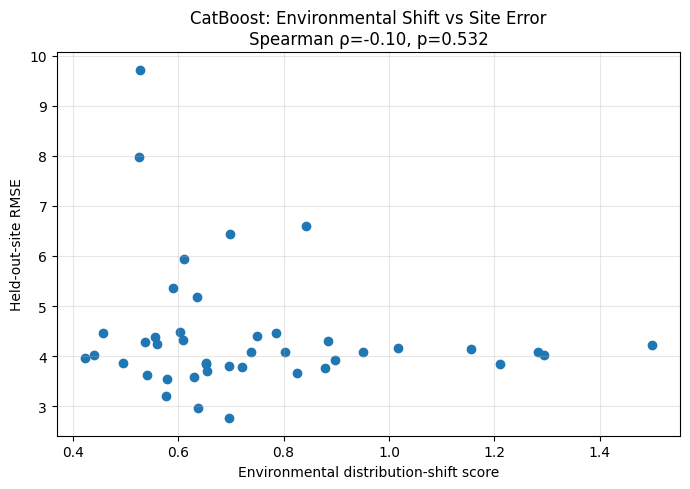

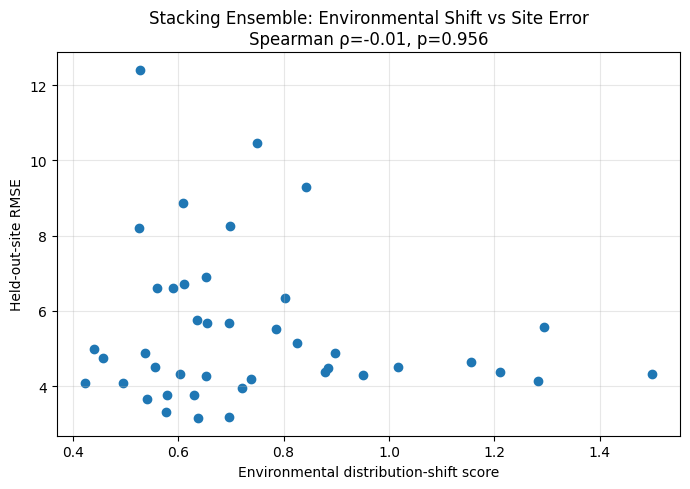

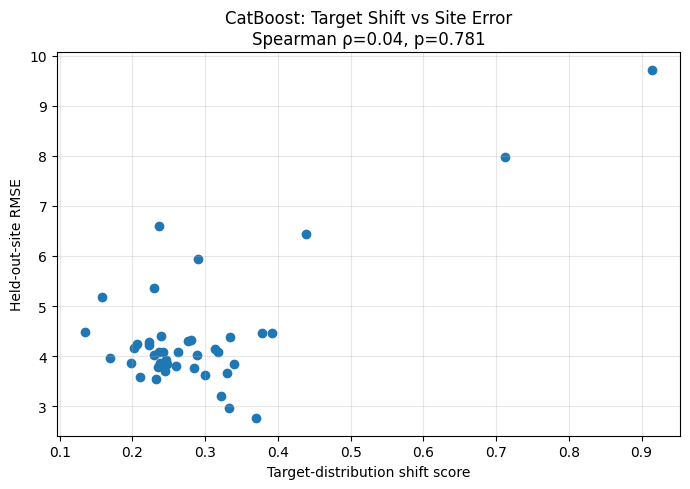

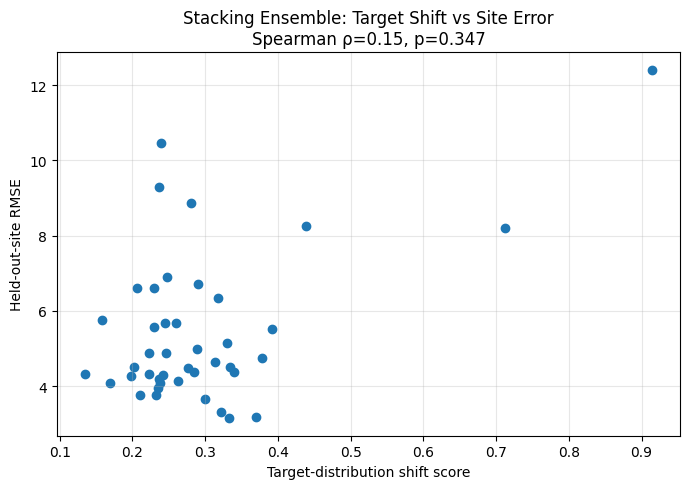


TRANSFER-FAILURE DIAGNOSTIC SUMMARY

1. SITE DEPENDENCE (ICC)
Global: ICC=0.0699, N=47435, sites=42, converged=True
Fungi: ICC=0.1689, N=22776, sites=42, converged=True
Bacteria/Archaea: ICC=0.1243, N=24659, sites=42, converged=True

2. KEY SITE-LEVEL SHIFT/ERROR ASSOCIATIONS
CatBoost | Environmental_Shift: rho=-0.099, p_adj=1
CatBoost | Geographic_Novelty_km: rho=0.253, p_adj=1
CatBoost | Target_Distribution_Shift: rho=0.044, p_adj=1
CatBoost | Target_Mean_Shift_SD: rho=0.406, p_adj=0.4806
Stacking Ensemble | Environmental_Shift: rho=-0.009, p_adj=1
Stacking Ensemble | Geographic_Novelty_km: rho=0.234, p_adj=1
Stacking Ensemble | Target_Distribution_Shift: rho=0.149, p_adj=1
Stacking Ensemble | Target_Mean_Shift_SD: rho=0.339, p_adj=1

IMPORTANT INTERPRETATION RULE:
A non-significant environmental-shift correlation does NOT mean that transfer failure is absent. It means that simple marginal covariate divergence alone does not explain the site-level prediction errors.
Target-shift and

In [30]:
# ============================================================
# TRANSFER-FAILURE DIAGNOSTICS
#
# Purpose:
#   Investigate WHY model performance deteriorates under
#   site-aware and temporal transfer.
#
# Analyses:
#   1. Environmental / covariate shift across held-out sites
#   2. Geographic novelty
#   3. Target-distribution shift
#   4. Site-level prediction errors
#   5. Shift-error Spearman correlations
#   6. Site-level dependence using ICC
#   7. Temporal environmental + target shift
#
# IMPORTANT:
# Target-distribution information is used ONLY for retrospective
# diagnosis. It is never used for model fitting or prediction.
# ============================================================


# ============================================================
# 0. LOCAL IMPORTS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import (
    wasserstein_distance,
    spearmanr,
)

from statsmodels.regression.mixed_linear_model import MixedLM

try:
    from statsmodels.stats.multitest import multipletests
    MULTITEST_AVAILABLE = True
except Exception:
    MULTITEST_AVAILABLE = False


# ============================================================
# 1. BASIC VALIDATION
# ============================================================

required_objects = [
    "X_global",
    "y_global",
    "site_groups_global",
    "years_global",
    "global_site_oof_predictions",
    "soil_features",
    "climate_features",
    "TABLE_DIR",
    "FIG_DIR",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "The following prerequisite objects are missing: "
        + ", ".join(missing_objects)
    )


if len(X_global) != len(y_global):
    raise ValueError(
        "X_global and y_global have different lengths."
    )

if len(X_global) != len(site_groups_global):
    raise ValueError(
        "X_global and site_groups_global have different lengths."
    )

if len(X_global) != len(years_global):
    raise ValueError(
        "X_global and years_global have different lengths."
    )


print("=" * 75)
print("TRANSFER-FAILURE DIAGNOSTIC ANALYSIS")
print("=" * 75)

print("Rows:", len(X_global))
print("Sites:", site_groups_global.nunique())

print(
    "Years:",
    sorted(
        pd.to_numeric(
            years_global,
            errors="coerce"
        )
        .dropna()
        .unique()
    )
)


# ============================================================
# 2. HELPER FUNCTIONS
# ============================================================


def standardised_wasserstein(
    train_values,
    test_values,
):
    """
    Wasserstein distance normalised by the standard deviation
    of the training distribution.

    0 = highly similar distributions.
    Larger values = stronger shift relative to training spread.
    """

    train_values = pd.to_numeric(
        pd.Series(train_values),
        errors="coerce"
    ).dropna()

    test_values = pd.to_numeric(
        pd.Series(test_values),
        errors="coerce"
    ).dropna()

    if (
        len(train_values) < 2
        or len(test_values) < 2
    ):
        return np.nan

    train_sd = float(
        train_values.std(ddof=1)
    )

    if (
        not np.isfinite(train_sd)
        or train_sd < 1e-12
    ):
        return 0.0

    raw_distance = wasserstein_distance(
        train_values,
        test_values
    )

    return float(
        raw_distance / train_sd
    )


def total_variation_distance(
    train_values,
    test_values,
):
    """
    Total-variation distance for categorical distributions.

    Range:
        0 = identical categorical distribution
        1 = completely non-overlapping distributions
    """

    train_values = (
        pd.Series(train_values)
        .fillna("__MISSING__")
        .astype(str)
    )

    test_values = (
        pd.Series(test_values)
        .fillna("__MISSING__")
        .astype(str)
    )

    train_freq = (
        train_values
        .value_counts(normalize=True)
    )

    test_freq = (
        test_values
        .value_counts(normalize=True)
    )

    categories = (
        train_freq.index
        .union(test_freq.index)
    )

    p = (
        train_freq
        .reindex(
            categories,
            fill_value=0
        )
        .to_numpy()
    )

    q = (
        test_freq
        .reindex(
            categories,
            fill_value=0
        )
        .to_numpy()
    )

    return float(
        0.5
        * np.abs(p - q).sum()
    )


def haversine_km(
    lat1,
    lon1,
    lat2,
    lon2,
):
    """
    Great-circle geographic distance in kilometres.
    """

    earth_radius_km = 6371.0088

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)

    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2.0) ** 2
        +
        np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2.0) ** 2
    )

    return (
        earth_radius_km
        * 2.0
        * np.arcsin(
            np.sqrt(a)
        )
    )


def calculate_site_error_table(
    prediction_df,
):
    """
    Calculate model error separately for each held-out site
    using canonical site-aware OOF predictions.
    """

    required_cols = [
        "Dataset",
        "Model",
        "Site",
        "Observed",
        "Predicted",
    ]

    missing_cols = [
        c
        for c in required_cols
        if c not in prediction_df.columns
    ]

    if missing_cols:
        raise ValueError(
            "OOF prediction table is missing: "
            + ", ".join(missing_cols)
        )

    rows = []

    for (
        dataset_name,
        model_name,
        site_name
    ), group in prediction_df.groupby(
        [
            "Dataset",
            "Model",
            "Site",
        ]
    ):

        observed = (
            group["Observed"]
            .to_numpy(dtype=float)
        )

        predicted = (
            group["Predicted"]
            .to_numpy(dtype=float)
        )

        residual = (
            observed - predicted
        )

        mae = float(
            np.mean(
                np.abs(residual)
            )
        )

        rmse = float(
            np.sqrt(
                np.mean(
                    residual ** 2
                )
            )
        )

        if (
            len(observed) > 1
            and np.var(observed) > 0
        ):

            r2 = float(
                1
                -
                (
                    np.sum(
                        residual ** 2
                    )
                    /
                    np.sum(
                        (
                            observed
                            - observed.mean()
                        ) ** 2
                    )
                )
            )

        else:
            r2 = np.nan

        rows.append({
            "Dataset":
                dataset_name,

            "Model":
                model_name,

            "Site":
                str(site_name),

            "N":
                int(len(group)),

            "R2":
                r2,

            "MAE":
                mae,

            "RMSE":
                rmse,
        })

    return pd.DataFrame(rows)


def intercept_only_icc(
    y,
    groups,
    dataset_name,
):
    """
    Estimate site-level intraclass correlation coefficient (ICC)
    using an intercept-only random-effects model:

        y_ij = beta_0 + b_j + epsilon_ij

    ICC = sigma_site^2 /
          (sigma_site^2 + sigma_residual^2)

    Interpretation:
        ICC near 0 -> little site clustering.
        Larger ICC -> observations from the same site share
                      substantial common abundance structure.
    """

    diagnostic_df = pd.DataFrame({
        "Target":
            pd.to_numeric(
                pd.Series(y),
                errors="coerce"
            ),

        "Site":
            pd.Series(groups)
            .astype("object"),
    })

    diagnostic_df = (
        diagnostic_df
        .dropna(
            subset=[
                "Target",
                "Site",
            ]
        )
        .reset_index(drop=True)
    )

    diagnostic_df["Site"] = (
        diagnostic_df["Site"]
        .astype(str)
    )

    if (
        len(diagnostic_df) < 10
        or diagnostic_df["Site"].nunique() < 2
    ):
        return {
            "Dataset":
                dataset_name,

            "N":
                len(diagnostic_df),

            "N_Sites":
                diagnostic_df[
                    "Site"
                ].nunique(),

            "Site_Variance":
                np.nan,

            "Residual_Variance":
                np.nan,

            "ICC":
                np.nan,

            "Converged":
                False,
        }

    # Intercept-only fixed-effect design.
    exog = np.ones(
        (
            len(diagnostic_df),
            1
        ),
        dtype=float
    )

    model = MixedLM(
        endog=
            diagnostic_df[
                "Target"
            ].to_numpy(
                dtype=float
            ),

        exog=
            exog,

        groups=
            diagnostic_df[
                "Site"
            ].to_numpy()
    )

    result = model.fit(
        reml=True,
        method="powell",
        maxiter=500,
        disp=False
    )

    site_variance = float(
        np.asarray(
            result.cov_re
        ).ravel()[0]
    )

    residual_variance = float(
        result.scale
    )

    total_variance = (
        site_variance
        + residual_variance
    )

    icc = (
        site_variance
        / total_variance
        if total_variance > 0
        else np.nan
    )

    return {
        "Dataset":
            dataset_name,

        "N":
            int(
                len(
                    diagnostic_df
                )
            ),

        "N_Sites":
            int(
                diagnostic_df[
                    "Site"
                ].nunique()
            ),

        "Site_Variance":
            site_variance,

        "Residual_Variance":
            residual_variance,

        "ICC":
            float(icc),

        "Converged":
            bool(
                result.converged
            ),
    }


# ============================================================
# 3. IDENTIFY NUMERIC ECOLOGICAL FEATURES
# ============================================================

soil_numeric_features = [
    feature
    for feature in soil_features
    if (
        feature in X_global.columns
        and pd.api.types.is_numeric_dtype(
            X_global[feature]
        )
    )
]

climate_numeric_features = [
    feature
    for feature in climate_features
    if (
        feature in X_global.columns
        and pd.api.types.is_numeric_dtype(
            X_global[feature]
        )
    )
]

environmental_numeric_features = (
    soil_numeric_features
    + climate_numeric_features
)


print("\nNumeric soil features:")
print(soil_numeric_features)

print("\nNumeric climate features:")
print(climate_numeric_features)


# ============================================================
# 4. CREATE SITE-LEVEL MODEL ERROR TABLE
# ============================================================

global_site_oof = (
    global_site_oof_predictions
    .copy()
)

if "Dataset" not in global_site_oof.columns:
    global_site_oof[
        "Dataset"
    ] = "Global"


site_level_model_errors = (
    calculate_site_error_table(
        global_site_oof
    )
)


site_level_model_errors.to_csv(
    TABLE_DIR
    / "site_level_model_errors_transfer_diagnostics.csv",
    index=False
)


print(
    "\nSite-level prediction-error table:"
)

print(
    site_level_model_errors
    .head(15)
    .to_string(index=False)
)


# ============================================================
# 5. RECOVER EXACT SITE GROUPKFOLD ASSIGNMENTS
# ============================================================

available_models = (
    global_site_oof[
        "Model"
    ]
    .dropna()
    .unique()
    .tolist()
)


if "CatBoost" in available_models:
    reference_model = "CatBoost"

else:
    reference_model = (
        available_models[0]
    )


reference_oof = (
    global_site_oof[
        global_site_oof[
            "Model"
        ] == reference_model
    ]
    .copy()
)


site_fold_counts = (
    reference_oof
    .groupby("Site")[
        "Fold"
    ]
    .nunique()
)


if (
    site_fold_counts > 1
).any():

    raise RuntimeError(
        "At least one site appears in "
        "multiple GroupKFold test folds."
    )


site_fold_map = (
    reference_oof
    .groupby("Site")[
        "Fold"
    ]
    .first()
    .to_dict()
)


print(
    "\nReference model used to recover "
    "site-fold assignments:",
    reference_model
)

print(
    "Sites with fold assignments:",
    len(site_fold_map)
)


# ============================================================
# 6. SITE-LEVEL COVARIATE + TARGET SHIFT
# ============================================================

site_shift_rows = []

unique_folds = sorted(
    pd.Series(
        list(
            site_fold_map.values()
        )
    )
    .dropna()
    .unique()
)


for fold in unique_folds:

    test_sites = [
        str(site)
        for site, site_fold
        in site_fold_map.items()
        if site_fold == fold
    ]

    all_sites_as_string = (
        site_groups_global
        .astype(str)
    )

    train_mask = (
        ~all_sites_as_string
        .isin(test_sites)
    )

    X_train_fold = (
        X_global
        .loc[train_mask]
    )

    y_train_fold = (
        y_global
        .loc[train_mask]
    )

    train_sites_fold = (
        all_sites_as_string
        .loc[train_mask]
    )


    # --------------------------------------------------------
    # Coordinates of training sites
    # --------------------------------------------------------

    train_coord_df = pd.DataFrame({
        "Site":
            train_sites_fold
            .to_numpy(),

        "Latitude":
            X_train_fold[
                "field_latitude"
            ].to_numpy(),

        "Longitude":
            X_train_fold[
                "field_longitude"
            ].to_numpy(),
    })


    train_coord_df = (
        train_coord_df
        .groupby("Site")
        .agg(
            Latitude=(
                "Latitude",
                "mean"
            ),

            Longitude=(
                "Longitude",
                "mean"
            ),
        )
        .dropna()
        .reset_index()
    )


    train_target_sd = float(
        y_train_fold.std(
            ddof=1
        )
    )


    # --------------------------------------------------------
    # Evaluate each held-out site independently
    # --------------------------------------------------------

    for site in test_sites:

        site_mask = (
            all_sites_as_string
            == str(site)
        )

        X_site_test = (
            X_global
            .loc[site_mask]
        )

        y_site_test = (
            y_global
            .loc[site_mask]
        )


        # ====================================================
        # NUMERIC ECOLOGICAL SHIFTS
        # ====================================================

        numeric_shift = {}

        for feature in (
            environmental_numeric_features
        ):

            numeric_shift[
                feature
            ] = standardised_wasserstein(
                X_train_fold[
                    feature
                ],
                X_site_test[
                    feature
                ],
            )


        soil_shift_values = [
            numeric_shift[
                feature
            ]

            for feature in (
                soil_numeric_features
            )

            if pd.notna(
                numeric_shift[
                    feature
                ]
            )
        ]


        climate_shift_values = [
            numeric_shift[
                feature
            ]

            for feature in (
                climate_numeric_features
            )

            if pd.notna(
                numeric_shift[
                    feature
                ]
            )
        ]


        environmental_shift_values = [
            value
            for value
            in numeric_shift.values()
            if pd.notna(value)
        ]


        soil_shift = (
            float(
                np.mean(
                    soil_shift_values
                )
            )
            if soil_shift_values
            else np.nan
        )


        climate_shift = (
            float(
                np.mean(
                    climate_shift_values
                )
            )
            if climate_shift_values
            else np.nan
        )


        environmental_shift = (
            float(
                np.mean(
                    environmental_shift_values
                )
            )
            if environmental_shift_values
            else np.nan
        )


        # ====================================================
        # CATEGORICAL ECOLOGICAL SHIFTS
        # ====================================================

        if (
            "horizon"
            in X_global.columns
        ):

            horizon_shift = (
                total_variation_distance(
                    X_train_fold[
                        "horizon"
                    ],
                    X_site_test[
                        "horizon"
                    ],
                )
            )

        else:
            horizon_shift = np.nan


        if (
            "crop_type"
            in X_global.columns
        ):

            landcover_shift = (
                total_variation_distance(
                    X_train_fold[
                        "crop_type"
                    ],
                    X_site_test[
                        "crop_type"
                    ],
                )
            )

        else:
            landcover_shift = np.nan


        # ====================================================
        # GEOGRAPHIC NOVELTY
        # ====================================================

        site_latitude = (
            X_site_test[
                "field_latitude"
            ]
            .mean()
        )

        site_longitude = (
            X_site_test[
                "field_longitude"
            ]
            .mean()
        )


        if (
            pd.notna(
                site_latitude
            )
            and
            pd.notna(
                site_longitude
            )
            and
            len(
                train_coord_df
            ) > 0
        ):

            geographic_distances = (
                haversine_km(
                    site_latitude,
                    site_longitude,

                    train_coord_df[
                        "Latitude"
                    ].to_numpy(),

                    train_coord_df[
                        "Longitude"
                    ].to_numpy(),
                )
            )

            geographic_novelty = float(
                np.min(
                    geographic_distances
                )
            )

        else:
            geographic_novelty = np.nan


        # ====================================================
        # TARGET-DISTRIBUTION SHIFT
        #
        # POST-HOC DIAGNOSTIC ONLY.
        # Target values are NOT used by the predictive model.
        # ====================================================

        target_distribution_shift = (
            standardised_wasserstein(
                y_train_fold,
                y_site_test,
            )
        )


        train_target_mean = float(
            y_train_fold.mean()
        )

        test_target_mean = float(
            y_site_test.mean()
        )


        target_mean_difference = (
            test_target_mean
            - train_target_mean
        )


        if (
            np.isfinite(
                train_target_sd
            )
            and
            train_target_sd > 1e-12
        ):

            target_mean_shift_sd = float(
                abs(
                    target_mean_difference
                )
                /
                train_target_sd
            )

        else:
            target_mean_shift_sd = np.nan


        target_median_difference = float(
            y_site_test.median()
            -
            y_train_fold.median()
        )


        site_shift_rows.append({

            "Site":
                str(site),

            "Fold":
                int(fold),

            "N_Test":
                int(
                    site_mask.sum()
                ),

            "Soil_Shift":
                soil_shift,

            "Climate_Shift":
                climate_shift,

            "Environmental_Shift":
                environmental_shift,

            "Horizon_Shift":
                horizon_shift,

            "LandCover_Shift":
                landcover_shift,

            "Geographic_Novelty_km":
                geographic_novelty,

            "Target_Distribution_Shift":
                target_distribution_shift,

            "Train_Target_Mean":
                train_target_mean,

            "Test_Target_Mean":
                test_target_mean,

            "Target_Mean_Difference":
                target_mean_difference,

            "Target_Mean_Shift_SD":
                target_mean_shift_sd,

            "Target_Median_Difference":
                target_median_difference,
        })


site_shift_df = pd.DataFrame(
    site_shift_rows
)


site_shift_df.to_csv(
    TABLE_DIR
    / "site_transfer_shift_diagnostics.csv",
    index=False
)


print(
    "\nSite-level transfer-shift diagnostics:"
)

print(
    site_shift_df
    .head(20)
    .to_string(index=False)
)


# ============================================================
# 7. MERGE SITE SHIFT WITH MODEL ERROR
# ============================================================

global_site_errors = (
    site_level_model_errors[
        site_level_model_errors[
            "Dataset"
        ] == "Global"
    ]
    .copy()
)


shift_error_df = (
    global_site_errors
    .merge(
        site_shift_df,
        on="Site",
        how="inner"
    )
)


shift_error_df.to_csv(
    TABLE_DIR
    / "site_shift_vs_model_error.csv",
    index=False
)


print(
    "\nMerged shift-error table rows:",
    len(
        shift_error_df
    )
)


# ============================================================
# 8. SPEARMAN SHIFT-ERROR CORRELATIONS
# ============================================================

shift_variables = [

    "Soil_Shift",

    "Climate_Shift",

    "Environmental_Shift",

    "Horizon_Shift",

    "LandCover_Shift",

    "Geographic_Novelty_km",

    "Target_Distribution_Shift",

    "Target_Mean_Shift_SD",
]


correlation_rows = []


for model_name in sorted(
    shift_error_df[
        "Model"
    ]
    .dropna()
    .unique()
):

    model_error_df = (
        shift_error_df[
            shift_error_df[
                "Model"
            ] == model_name
        ]
        .copy()
    )


    for shift_variable in (
        shift_variables
    ):

        current = (
            model_error_df[
                [
                    shift_variable,
                    "RMSE",
                ]
            ]
            .replace(
                [
                    np.inf,
                    -np.inf
                ],
                np.nan
            )
            .dropna()
        )


        if (
            len(current) < 5
            or
            current[
                shift_variable
            ].nunique() < 2
            or
            current[
                "RMSE"
            ].nunique() < 2
        ):

            continue


        rho, p_value = (
            spearmanr(
                current[
                    shift_variable
                ],
                current[
                    "RMSE"
                ],
            )
        )


        correlation_rows.append({

            "Model":
                model_name,

            "Shift_Metric":
                shift_variable,

            "N_Sites":
                int(
                    len(current)
                ),

            "Spearman_Rho":
                float(rho),

            "P_Value":
                float(p_value),
        })


shift_error_correlations = (
    pd.DataFrame(
        correlation_rows
    )
)


# ------------------------------------------------------------
# Holm correction for multiple tests
# ------------------------------------------------------------

if (
    len(
        shift_error_correlations
    ) > 0
):

    if MULTITEST_AVAILABLE:

        (
            reject,
            adjusted_p,
            _,
            _
        ) = multipletests(

            shift_error_correlations[
                "P_Value"
            ],

            alpha=0.05,

            method="holm",
        )


        shift_error_correlations[
            "Holm_Adjusted_P"
        ] = adjusted_p


        shift_error_correlations[
            "Significant_0.05"
        ] = reject


    else:

        shift_error_correlations[
            "Holm_Adjusted_P"
        ] = np.nan


        shift_error_correlations[
            "Significant_0.05"
        ] = False


shift_error_correlations.to_csv(
    TABLE_DIR
    / "shift_error_spearman_correlations.csv",
    index=False
)


print(
    "\nShift-error Spearman correlations:"
)


if len(
    shift_error_correlations
) > 0:

    print(
        shift_error_correlations
        .sort_values(
            [
                "Model",
                "Holm_Adjusted_P",
            ],
            na_position="last"
        )
        .to_string(
            index=False
        )
    )

else:

    print(
        "No valid correlations could be computed."
    )


# ============================================================
# 9. SITE-LEVEL DEPENDENCE: ICC
# ============================================================

if (
    "targetTaxonGroup"
    in model_meta.columns
):

    taxon_series = (
        model_meta[
            "targetTaxonGroup"
        ]
        .astype(str)
        .str.lower()
    )


    fungi_icc_mask = (
        taxon_series
        .str.contains(
            "fung",
            na=False
        )
    )


    bacteria_archaea_icc_mask = (
        taxon_series
        .str.contains(
            "bacter|archaea",
            regex=True,
            na=False
        )
    )


else:

    # Fallback to subgroup masks already defined earlier.
    fungi_icc_mask = (
        pd.Series(
            fungi_mask
        )
        .reset_index(drop=True)
    )

    bacteria_archaea_icc_mask = (
        pd.Series(
            bacteria_archaea_mask
        )
        .reset_index(drop=True)
    )


icc_results = []


# ------------------------------------------------------------
# Global ICC
# ------------------------------------------------------------

icc_results.append(

    intercept_only_icc(
        y=
            y_global
            .reset_index(drop=True),

        groups=
            site_groups_global
            .reset_index(drop=True),

        dataset_name=
            "Global",
    )
)


# ------------------------------------------------------------
# Fungi ICC
# ------------------------------------------------------------

icc_results.append(

    intercept_only_icc(
        y=
            y_global
            .loc[
                np.asarray(
                    fungi_icc_mask
                )
            ]
            .reset_index(drop=True),

        groups=
            site_groups_global
            .loc[
                np.asarray(
                    fungi_icc_mask
                )
            ]
            .reset_index(drop=True),

        dataset_name=
            "Fungi",
    )
)


# ------------------------------------------------------------
# Bacteria / Archaea ICC
# ------------------------------------------------------------

icc_results.append(

    intercept_only_icc(
        y=
            y_global
            .loc[
                np.asarray(
                    bacteria_archaea_icc_mask
                )
            ]
            .reset_index(drop=True),

        groups=
            site_groups_global
            .loc[
                np.asarray(
                    bacteria_archaea_icc_mask
                )
            ]
            .reset_index(drop=True),

        dataset_name=
            "Bacteria/Archaea",
    )
)


icc_results_df = (
    pd.DataFrame(
        icc_results
    )
)


icc_results_df.to_csv(
    TABLE_DIR
    / "site_dependence_icc.csv",
    index=False
)


print(
    "\nSite-level dependence (ICC):"
)

print(
    icc_results_df
    .to_string(
        index=False
    )
)


# ============================================================
# 10. TEMPORAL ENVIRONMENTAL + TARGET SHIFT
# ============================================================

years_numeric_global = (
    pd.to_numeric(
        years_global,
        errors="coerce"
    )
)


unique_years = sorted(
    years_numeric_global
    .dropna()
    .unique()
)


# Use same minimum data thresholds as forward-chaining analysis.
MIN_TEMPORAL_TRAIN_N = 1000
MIN_TEMPORAL_TEST_N = 1000


eligible_holdout_years = []


for candidate_year in (
    unique_years[1:]
):

    n_train = int(
        (
            years_numeric_global
            < candidate_year
        )
        .sum()
    )

    n_test = int(
        (
            years_numeric_global
            == candidate_year
        )
        .sum()
    )


    if (
        n_train
        >= MIN_TEMPORAL_TRAIN_N
        and
        n_test
        >= MIN_TEMPORAL_TEST_N
    ):

        eligible_holdout_years.append(
            int(
                candidate_year
            )
        )


print(
    "\nEligible temporal diagnostic holdouts:",
    eligible_holdout_years
)


temporal_shift_rows = []


for holdout_year in (
    eligible_holdout_years
):

    train_mask = (
        years_numeric_global
        < holdout_year
    )

    test_mask = (
        years_numeric_global
        == holdout_year
    )


    X_train_period = (
        X_global
        .loc[
            train_mask
        ]
    )

    X_test_period = (
        X_global
        .loc[
            test_mask
        ]
    )


    y_train_period = (
        y_global
        .loc[
            train_mask
        ]
    )

    y_test_period = (
        y_global
        .loc[
            test_mask
        ]
    )


    # --------------------------------------------------------
    # Numerical feature shifts
    # --------------------------------------------------------

    feature_shift_values = {}

    for feature in (
        environmental_numeric_features
    ):

        feature_shift_values[
            feature
        ] = (
            standardised_wasserstein(
                X_train_period[
                    feature
                ],
                X_test_period[
                    feature
                ],
            )
        )


    soil_shift_values = [
        feature_shift_values[
            feature
        ]

        for feature in (
            soil_numeric_features
        )

        if pd.notna(
            feature_shift_values[
                feature
            ]
        )
    ]


    climate_shift_values = [
        feature_shift_values[
            feature
        ]

        for feature in (
            climate_numeric_features
        )

        if pd.notna(
            feature_shift_values[
                feature
            ]
        )
    ]


    all_environmental_shifts = [
        value
        for value
        in feature_shift_values.values()
        if pd.notna(value)
    ]


    mean_soil_shift = (
        float(
            np.mean(
                soil_shift_values
            )
        )
        if soil_shift_values
        else np.nan
    )


    mean_climate_shift = (
        float(
            np.mean(
                climate_shift_values
            )
        )
        if climate_shift_values
        else np.nan
    )


    mean_environmental_shift = (
        float(
            np.mean(
                all_environmental_shifts
            )
        )
        if all_environmental_shifts
        else np.nan
    )


    max_environmental_shift = (
        float(
            np.max(
                all_environmental_shifts
            )
        )
        if all_environmental_shifts
        else np.nan
    )


    # --------------------------------------------------------
    # Categorical shifts
    # --------------------------------------------------------

    if (
        "crop_type"
        in X_global.columns
    ):

        temporal_landcover_shift = (
            total_variation_distance(
                X_train_period[
                    "crop_type"
                ],
                X_test_period[
                    "crop_type"
                ],
            )
        )

    else:
        temporal_landcover_shift = np.nan


    if (
        "horizon"
        in X_global.columns
    ):

        temporal_horizon_shift = (
            total_variation_distance(
                X_train_period[
                    "horizon"
                ],
                X_test_period[
                    "horizon"
                ],
            )
        )

    else:
        temporal_horizon_shift = np.nan


    # --------------------------------------------------------
    # Target shift
    # --------------------------------------------------------

    temporal_target_shift = (
        standardised_wasserstein(
            y_train_period,
            y_test_period,
        )
    )


    train_target_mean = float(
        y_train_period.mean()
    )

    test_target_mean = float(
        y_test_period.mean()
    )


    train_target_sd = float(
        y_train_period.std(
            ddof=1
        )
    )


    target_mean_difference = (
        test_target_mean
        - train_target_mean
    )


    target_mean_shift_sd = (
        abs(
            target_mean_difference
        )
        /
        train_target_sd

        if (
            np.isfinite(
                train_target_sd
            )
            and
            train_target_sd > 1e-12
        )

        else np.nan
    )


    temporal_shift_rows.append({

        "Holdout_Year":
            int(
                holdout_year
            ),

        "Train_N":
            int(
                train_mask.sum()
            ),

        "Test_N":
            int(
                test_mask.sum()
            ),

        "Mean_Soil_Shift":
            mean_soil_shift,

        "Mean_Climate_Shift":
            mean_climate_shift,

        "Mean_Environmental_Shift":
            mean_environmental_shift,

        "Max_Environmental_Shift":
            max_environmental_shift,

        "LandCover_Shift":
            temporal_landcover_shift,

        "Horizon_Shift":
            temporal_horizon_shift,

        "Target_Distribution_Shift":
            temporal_target_shift,

        "Train_Target_Mean":
            train_target_mean,

        "Test_Target_Mean":
            test_target_mean,

        "Target_Mean_Difference":
            target_mean_difference,

        "Target_Mean_Shift_SD":
            target_mean_shift_sd,
    })


temporal_shift_summary = (
    pd.DataFrame(
        temporal_shift_rows
    )
)


temporal_shift_summary.to_csv(
    TABLE_DIR
    / "temporal_transfer_shift_diagnostics.csv",
    index=False
)


print(
    "\nTemporal environmental and target shift:"
)

print(
    temporal_shift_summary
    .to_string(
        index=False
    )
)


# ============================================================
# 11. LINK TEMPORAL SHIFT TO FORWARD-CHAINING RESULTS
# ============================================================

if (
    "forward_chaining_results"
    in globals()
    and
    isinstance(
        forward_chaining_results,
        pd.DataFrame
    )
    and
    len(
        forward_chaining_results
    ) > 0
):

    global_forward_results = (
        forward_chaining_results[
            forward_chaining_results[
                "Dataset"
            ] == "Global"
        ]
        .copy()
    )


    temporal_shift_with_scores = (
        global_forward_results
        .merge(
            temporal_shift_summary,
            on="Holdout_Year",
            how="left"
        )
    )


    temporal_shift_with_scores.to_csv(
        TABLE_DIR
        / "temporal_shift_with_forward_scores.csv",
        index=False
    )


    print(
        "\nTemporal shift joined with "
        "forward-chaining performance:"
    )

    print(
        temporal_shift_with_scores[
            [
                "Model",
                "Holdout_Year",
                "R2",
                "RMSE",
                "Mean_Environmental_Shift",
                "Target_Distribution_Shift",
                "Target_Mean_Shift_SD",
            ]
        ]
        .to_string(
            index=False
        )
    )


else:

    temporal_shift_with_scores = None

    print(
        "\nForward-chaining results were not found. "
        "Temporal shift table was still generated."
    )


# ============================================================
# 12. PAPER-CANDIDATE FIGURES
# ============================================================

PLOT_MODELS = [
    model_name
    for model_name in [
        "CatBoost",
        "Stacking Ensemble",
    ]
    if model_name
    in shift_error_df[
        "Model"
    ].unique()
]


# ------------------------------------------------------------
# Figure A:
# Environmental shift vs site RMSE
# ------------------------------------------------------------

for model_name in (
    PLOT_MODELS
):

    current = (
        shift_error_df[
            shift_error_df[
                "Model"
            ] == model_name
        ][
            [
                "Environmental_Shift",
                "RMSE",
            ]
        ]
        .replace(
            [
                np.inf,
                -np.inf
            ],
            np.nan
        )
        .dropna()
    )


    if len(current) < 5:
        continue


    rho, p_value = (
        spearmanr(
            current[
                "Environmental_Shift"
            ],
            current[
                "RMSE"
            ],
        )
    )


    plt.figure(
        figsize=(7, 5)
    )

    plt.scatter(
        current[
            "Environmental_Shift"
        ],
        current[
            "RMSE"
        ],
    )

    plt.xlabel(
        "Environmental distribution-shift score"
    )

    plt.ylabel(
        "Held-out-site RMSE"
    )

    plt.title(
        f"{model_name}: Environmental Shift vs Site Error\n"
        f"Spearman ρ={rho:.2f}, p={p_value:.3g}"
    )

    plt.tight_layout()


    output_name = (
        model_name
        .lower()
        .replace(
            " ",
            "_"
        )
        .replace(
            "/",
            "_"
        )
    )


    plt.savefig(
        FIG_DIR
        / (
            output_name
            + "_environmental_shift_vs_site_rmse.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ------------------------------------------------------------
# Figure B:
# Target-distribution shift vs site RMSE
# ------------------------------------------------------------

for model_name in (
    PLOT_MODELS
):

    current = (
        shift_error_df[
            shift_error_df[
                "Model"
            ] == model_name
        ][
            [
                "Target_Distribution_Shift",
                "RMSE",
            ]
        ]
        .replace(
            [
                np.inf,
                -np.inf
            ],
            np.nan
        )
        .dropna()
    )


    if len(current) < 5:
        continue


    rho, p_value = (
        spearmanr(
            current[
                "Target_Distribution_Shift"
            ],
            current[
                "RMSE"
            ],
        )
    )


    plt.figure(
        figsize=(7, 5)
    )

    plt.scatter(
        current[
            "Target_Distribution_Shift"
        ],
        current[
            "RMSE"
        ],
    )

    plt.xlabel(
        "Target-distribution shift score"
    )

    plt.ylabel(
        "Held-out-site RMSE"
    )

    plt.title(
        f"{model_name}: Target Shift vs Site Error\n"
        f"Spearman ρ={rho:.2f}, p={p_value:.3g}"
    )

    plt.tight_layout()


    output_name = (
        model_name
        .lower()
        .replace(
            " ",
            "_"
        )
        .replace(
            "/",
            "_"
        )
    )


    plt.savefig(
        FIG_DIR
        / (
            output_name
            + "_target_shift_vs_site_rmse.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ============================================================
# 13. COMPACT DIAGNOSTIC SUMMARY FOR INTERPRETATION
# ============================================================

print("\n" + "=" * 75)
print("TRANSFER-FAILURE DIAGNOSTIC SUMMARY")
print("=" * 75)


# ------------------------------------------------------------
# ICC summary
# ------------------------------------------------------------

print("\n1. SITE DEPENDENCE (ICC)")

for _, row in (
    icc_results_df.iterrows()
):

    print(
        f"{row['Dataset']}: "
        f"ICC={row['ICC']:.4f}, "
        f"N={int(row['N'])}, "
        f"sites={int(row['N_Sites'])}, "
        f"converged={row['Converged']}"
    )


# ------------------------------------------------------------
# Main correlations for CatBoost / Stacking
# ------------------------------------------------------------

print("\n2. KEY SITE-LEVEL SHIFT/ERROR ASSOCIATIONS")


for model_name in (
    PLOT_MODELS
):

    model_corr = (
        shift_error_correlations[
            shift_error_correlations[
                "Model"
            ] == model_name
        ]
    )


    for metric_name in [
        "Environmental_Shift",
        "Geographic_Novelty_km",
        "Target_Distribution_Shift",
        "Target_Mean_Shift_SD",
    ]:

        current = (
            model_corr[
                model_corr[
                    "Shift_Metric"
                ] == metric_name
            ]
        )


        if len(current) == 0:
            continue


        row = current.iloc[0]


        adjusted_p = (
            row[
                "Holm_Adjusted_P"
            ]

            if (
                "Holm_Adjusted_P"
                in current.columns
                and
                pd.notna(
                    row[
                        "Holm_Adjusted_P"
                    ]
                )
            )

            else row[
                "P_Value"
            ]
        )


        print(
            f"{model_name} | "
            f"{metric_name}: "
            f"rho={row['Spearman_Rho']:.3f}, "
            f"p_adj={adjusted_p:.4g}"
        )


# ------------------------------------------------------------
# Interpretation guardrail
# ------------------------------------------------------------

print(
    "\nIMPORTANT INTERPRETATION RULE:"
)

print(
    "A non-significant environmental-shift correlation does NOT "
    "mean that transfer failure is absent. It means that simple "
    "marginal covariate divergence alone does not explain the "
    "site-level prediction errors."
)

print(
    "Target-shift and ICC results should be interpreted as "
    "post-hoc evidence of domain heterogeneity/site dependence, "
    "not as predictive features and not as proof of causal "
    "mechanisms."
)


# ============================================================
# 14. EXPORT MASTER DIAGNOSTIC INDEX
# ============================================================

diagnostic_artifacts = pd.DataFrame({

    "Artifact": [

        "site_level_model_errors_transfer_diagnostics.csv",

        "site_transfer_shift_diagnostics.csv",

        "site_shift_vs_model_error.csv",

        "shift_error_spearman_correlations.csv",

        "site_dependence_icc.csv",

        "temporal_transfer_shift_diagnostics.csv",

        (
            "temporal_shift_with_forward_scores.csv"
            if temporal_shift_with_scores
            is not None
            else
            "Not generated"
        ),
    ],

    "Purpose": [

        "Held-out-site model error",

        "Site-level covariate, geographic and target shifts",

        "Merged site shift and predictive error",

        "Shift-error Spearman association tests",

        "Within-site abundance dependence / ICC",

        "Environmental and target shift across future periods",

        "Forward-chaining performance linked to temporal shift",
    ],
})


diagnostic_artifacts.to_csv(
    TABLE_DIR
    / "transfer_failure_diagnostic_artifacts.csv",
    index=False
)


print(
    "\nTransfer-failure diagnostic analysis completed."
)

print(
    "Outputs saved under:"
)

print(
    TABLE_DIR
)

print(
    FIG_DIR
)

Moran's I

In [31]:
def morans_i_knn(
    site_df,
    value_col,
    lat_col,
    lon_col,
    k=4,
    n_permutations=999,
    seed=SEED
):
    data = (
        site_df[
            [
                value_col,
                lat_col,
                lon_col
            ]
        ]
        .dropna()
        .reset_index(drop=True)
    )

    n = len(data)

    if n < 4:
        raise ValueError(
            "Too few sites for Moran's I."
        )

    k = min(
        k,
        n - 1
    )

    coords_rad = np.radians(
        data[
            [
                lat_col,
                lon_col
            ]
        ].to_numpy()
    )

    neighbours = NearestNeighbors(
        n_neighbors=k + 1,
        metric="haversine"
    )

    neighbours.fit(
        coords_rad
    )

    _, neighbour_idx = (
        neighbours.kneighbors(
            coords_rad
        )
    )

    W = np.zeros(
        (n, n),
        dtype=float
    )

    for i in range(n):

        # First neighbour is the point itself.
        for j in neighbour_idx[
            i,
            1:
        ]:
            W[i, j] = 1.0

    # Symmetrise the kNN graph.
    W = np.maximum(
        W,
        W.T
    )

    # Row-standardise.
    row_sum = (
        W.sum(
            axis=1,
            keepdims=True
        )
    )

    W = np.divide(
        W,
        row_sum,
        out=np.zeros_like(W),
        where=row_sum != 0
    )

    values = (
        data[value_col]
        .to_numpy(
            dtype=float
        )
    )

    z = (
        values
        - values.mean()
    )

    s0 = W.sum()

    denominator = (
        z @ z
    )

    observed_i = (
        (n / s0)
        * (
            z @ W @ z
        )
        / denominator
    )

    expected_i = (
        -1.0
        / (n - 1)
    )

    rng = np.random.default_rng(
        seed
    )

    permuted_i = []

    for _ in range(
        n_permutations
    ):

        z_perm = (
            rng.permutation(z)
        )

        i_perm = (
            (n / s0)
            * (
                z_perm
                @ W
                @ z_perm
            )
            / (
                z_perm
                @ z_perm
            )
        )

        permuted_i.append(
            i_perm
        )

    permuted_i = np.asarray(
        permuted_i
    )

    observed_deviation = abs(
        observed_i
        - expected_i
    )

    permutation_deviation = np.abs(
        permuted_i
        - expected_i
    )

    p_value = (
        (
            np.sum(
                permutation_deviation
                >= observed_deviation
            )
            + 1
        )
        /
        (
            n_permutations
            + 1
        )
    )

    return {
        "N_Sites":
            n,

        "K_Neighbours":
            k,

        "Morans_I":
            float(observed_i),

        "Expected_I":
            float(expected_i),

        "Permutation_P":
            float(p_value),

        "N_Permutations":
            n_permutations
    }


spatial_analysis_df = pd.DataFrame({
    "Site":
        site_groups_global
        .astype(str),

    "Target":
        y_global,

    "Latitude":
        X_global[
            "field_latitude"
        ],

    "Longitude":
        X_global[
            "field_longitude"
        ],

    "Taxon":
        model_meta[
            "targetTaxonGroup"
        ]
        .astype(str)
        .str.lower()
})


moran_rows = []


moran_subsets = {
    "Global":
        np.ones(
            len(
                spatial_analysis_df
            ),
            dtype=bool
        ),

    "Fungi":
        spatial_analysis_df[
            "Taxon"
        ].eq("fungi"),

    "Bacteria/Archaea":
        spatial_analysis_df[
            "Taxon"
        ].isin(
            [
                "bacteria",
                "archaea",
                "bacteria and archaea"
            ]
        )
}


for dataset_name, mask in (
    moran_subsets.items()
):

    site_aggregated = (
        spatial_analysis_df
        .loc[mask]
        .groupby("Site")
        .agg(
            Mean_Log_Abundance=(
                "Target",
                "mean"
            ),

            Latitude=(
                "Latitude",
                "mean"
            ),

            Longitude=(
                "Longitude",
                "mean"
            )
        )
        .reset_index()
    )

    result = morans_i_knn(
        site_aggregated,
        value_col=
            "Mean_Log_Abundance",
        lat_col=
            "Latitude",
        lon_col=
            "Longitude",
        k=4,
        n_permutations=999
    )

    result[
        "Dataset"
    ] = dataset_name

    moran_rows.append(
        result
    )


moran_results = pd.DataFrame(
    moran_rows
)

display(
    moran_results
)

moran_results.to_csv(
    TABLE_DIR
    / "spatial_autocorrelation_morans_i.csv",
    index=False
)

,N_Sites,K_Neighbours,Morans_I,Expected_I,Permutation_P,N_Permutations,Dataset
0,42,4,-0.083262,-0.02439,0.469,999,Global
1,42,4,-0.109112,-0.02439,0.337,999,Fungi
2,42,4,-0.022497,-0.02439,0.978,999,Bacteria/Archaea


## Specialised ecological baseline: site random-intercept mixed-effects model

To complement the general-purpose machine-learning baselines, we include a
linear mixed-effects regression model that explicitly represents repeated
observations within ecological sites.

The model uses the same governed ecological predictor set as the global
benchmark and includes a random intercept for `siteID`. All preprocessing is
fitted using the training partition only.

For random and conventional K-fold evaluation, test observations from sites
already represented in training can use their estimated site-specific random
intercept. Under site-aware GroupKFold, entire sites are unseen during training;
therefore predictions for held-out sites use the population-level fixed-effects
component only. This provides a domain-relevant hierarchical baseline for
evaluating transfer to previously unseen ecological sites.

The Powell optimiser is used directly because it provides stable estimation for
this mixed-effects specification, whereas gradient-based optimisation was
numerically unstable for the benchmark design.

In [32]:
def build_mixedlm_preprocessor(X):
    numeric_cols = (
        X.select_dtypes(include=[np.number])
        .columns
        .tolist()
    )

    categorical_cols = [
        c for c in X.columns
        if c not in numeric_cols
    ]

    numeric_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="median")
            ),
            (
                "scaler",
                StandardScaler()
            )
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="most_frequent")
            ),
            (
                "onehot",
                make_one_hot_encoder(drop="first")
            )
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                numeric_pipeline,
                numeric_cols
            ),
            (
                "cat",
                categorical_pipeline,
                categorical_cols
            )
        ],
        remainder="drop"
    )

    return preprocessor


def fit_mixedlm(
    X_train,
    y_train,
    groups_train
):


    X_train = (
        X_train
        .reset_index(drop=True)
        .copy()
    )

    y_train = (
        pd.Series(y_train)
        .reset_index(drop=True)
        .copy()
    )

    groups_train = (
        pd.Series(groups_train)
        .reset_index(drop=True)
        .copy()
    )

    valid_mask = groups_train.notna()

    X_valid = (
        X_train
        .loc[valid_mask]
        .reset_index(drop=True)
    )

    y_valid = (
        y_train
        .loc[valid_mask]
        .reset_index(drop=True)
    )

    groups_valid = (
        groups_train
        .loc[valid_mask]
        .astype(str)
        .reset_index(drop=True)
    )

    preprocessor = build_mixedlm_preprocessor(
        X_valid
    )

    X_design = preprocessor.fit_transform(
        X_valid
    )

    X_design = np.asarray(
        X_design,
        dtype=float
    )

    X_design = sm.add_constant(
        X_design,
        has_constant="add"
    )

    model = MixedLM(
        endog=y_valid.to_numpy(dtype=float),
        exog=X_design,
        groups=groups_valid.to_numpy()
    )

    result = model.fit(
        reml=False,
        method="powell",
        maxiter=500,
        disp=False
    )

    random_effect_variance = float(
        np.asarray(result.cov_re)
        .ravel()[0]
    )

    diagnostics = {
        "Converged": bool(result.converged),
        "Random_Effect_Variance":
            random_effect_variance,
        "N_Training_Observations":
            int(len(X_valid)),
        "N_Training_Sites":
            int(groups_valid.nunique())
    }

    return {
        "preprocessor": preprocessor,
        "result": result,
        "diagnostics": diagnostics
    }


def predict_mixedlm(
    fitted,
    X_test,
    groups_test
):


    X_test = (
        X_test
        .reset_index(drop=True)
        .copy()
    )

    groups_test = (
        pd.Series(groups_test)
        .reset_index(drop=True)
        .astype(str)
    )

    preprocessor = fitted[
        "preprocessor"
    ]

    result = fitted[
        "result"
    ]

    X_design = preprocessor.transform(
        X_test
    )

    X_design = np.asarray(
        X_design,
        dtype=float
    )

    X_design = sm.add_constant(
        X_design,
        has_constant="add"
    )


    prediction = (
        X_design
        @ np.asarray(result.fe_params)
    )

    random_effects = result.random_effects

    n_known_sites = 0

    for i, site_name in enumerate(
        groups_test
    ):

        if site_name in random_effects:

            random_intercept = float(
                np.asarray(
                    random_effects[
                        site_name
                    ]
                )
                .ravel()[0]
            )

            prediction[i] += random_intercept

            n_known_sites += 1

    return (
        prediction,
        n_known_sites
    )



mixedlm_rows = []
mixedlm_diagnostics_rows = []
mixedlm_fold_rows = []


all_indices = np.arange(
    len(X_global)
)

train_idx, test_idx = train_test_split(
    all_indices,
    test_size=0.2,
    random_state=SEED
)

mixed_fit = fit_mixedlm(
    X_global.iloc[train_idx],
    y_global.iloc[train_idx],
    site_groups_global.iloc[train_idx]
)

mixed_pred, known_sites = predict_mixedlm(
    mixed_fit,
    X_global.iloc[test_idx],
    site_groups_global.iloc[test_idx]
)

random_metrics = metric_dict(
    y_global.iloc[test_idx],
    mixed_pred
)

mixedlm_rows.append({
    "Dataset": "Global",
    "Model": "Linear Mixed Effects",
    "Setting": "Random split",
    **random_metrics
})

mixedlm_diagnostics_rows.append({
    "Setting": "Random split",
    "Fold": np.nan,
    **mixed_fit["diagnostics"],
    "Test_N": int(len(test_idx)),
    "Test_Rows_With_Known_Site":
        int(known_sites)
})



kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

random_cv_rows = []

for fold, (
    train_idx,
    test_idx
) in enumerate(
    kf.split(X_global),
    start=1
):

    print(
        f"MixedLM random CV fold {fold}/5"
    )

    mixed_fit = fit_mixedlm(
        X_global.iloc[train_idx],
        y_global.iloc[train_idx],
        site_groups_global.iloc[train_idx]
    )

    mixed_pred, known_sites = predict_mixedlm(
        mixed_fit,
        X_global.iloc[test_idx],
        site_groups_global.iloc[test_idx]
    )

    metrics = metric_dict(
        y_global.iloc[test_idx],
        mixed_pred
    )

    random_cv_rows.append({
        "Fold": fold,
        **metrics
    })

    mixedlm_diagnostics_rows.append({
        "Setting": "5-fold CV",
        "Fold": fold,
        **mixed_fit["diagnostics"],
        "Test_N": int(len(test_idx)),
        "Test_Rows_With_Known_Site":
            int(known_sites)
    })


random_mixed_cv = pd.DataFrame(
    random_cv_rows
)

mixedlm_rows.append({
    "Dataset": "Global",
    "Model": "Linear Mixed Effects",
    **summarize_cv(
        random_mixed_cv,
        "5-fold CV"
    )
})


valid_mask = (
    site_groups_global
    .notna()
    .to_numpy()
)

X_site = (
    X_global
    .loc[valid_mask]
    .reset_index(drop=True)
)

y_site = (
    y_global
    .loc[valid_mask]
    .reset_index(drop=True)
)

groups_site = (
    site_groups_global
    .loc[valid_mask]
    .reset_index(drop=True)
)

gkf = GroupKFold(
    n_splits=5
)

site_cv_rows = []

for fold, (
    train_idx,
    test_idx
) in enumerate(
    gkf.split(
        X_site,
        y_site,
        groups_site
    ),
    start=1
):

    print(
        f"MixedLM site-aware fold {fold}/5"
    )

    mixed_fit = fit_mixedlm(
        X_site.iloc[train_idx],
        y_site.iloc[train_idx],
        groups_site.iloc[train_idx]
    )

    mixed_pred, known_sites = predict_mixedlm(
        mixed_fit,
        X_site.iloc[test_idx],
        groups_site.iloc[test_idx]
    )

    metrics = metric_dict(
        y_site.iloc[test_idx],
        mixed_pred
    )

    site_cv_rows.append({
        "Fold": fold,
        **metrics
    })

    mixedlm_diagnostics_rows.append({
        "Setting":
            "GroupKFold by site",
        "Fold":
            fold,
        **mixed_fit["diagnostics"],
        "Test_N":
            int(len(test_idx)),
        "Test_Rows_With_Known_Site":
            int(known_sites)
    })


site_mixed_df = pd.DataFrame(
    site_cv_rows
)

mixedlm_rows.append({
    "Dataset": "Global",
    "Model": "Linear Mixed Effects",
    **summarize_cv(
        site_mixed_df,
        "GroupKFold by site"
    )
})

years_numeric = pd.to_numeric(
    years_global,
    errors="coerce"
)

holdout_year = int(
    years_numeric.max()
)

train_mask = (
    years_numeric
    < holdout_year
)

test_mask = (
    years_numeric
    == holdout_year
)

mixed_fit = fit_mixedlm(
    X_global.loc[train_mask],
    y_global.loc[train_mask],
    site_groups_global.loc[train_mask]
)

mixed_pred, known_sites = predict_mixedlm(
    mixed_fit,
    X_global.loc[test_mask],
    site_groups_global.loc[test_mask]
)

time_metrics = metric_dict(
    y_global.loc[test_mask],
    mixed_pred
)

mixedlm_rows.append({
    "Dataset": "Global",
    "Model": "Linear Mixed Effects",
    "Setting": "Time-aware holdout",
    "Holdout_Year": holdout_year,
    **time_metrics
})

mixedlm_diagnostics_rows.append({
    "Setting":
        "Time-aware holdout",
    "Fold":
        np.nan,
    **mixed_fit["diagnostics"],
    "Test_N":
        int(test_mask.sum()),
    "Test_Rows_With_Known_Site":
        int(known_sites)
})



mixedlm_results = pd.DataFrame(
    mixedlm_rows
)

mixedlm_diagnostics = pd.DataFrame(
    mixedlm_diagnostics_rows
)


print("\nMixed-effects benchmark results:")
display(
    mixedlm_results
)

print("\nMixed-effects fit diagnostics:")
display(
    mixedlm_diagnostics
)


mixedlm_results.to_csv(
    TABLE_DIR
    / "mixed_effects_specialised_baseline.csv",
    index=False
)

mixedlm_diagnostics.to_csv(
    TABLE_DIR
    / "mixed_effects_fit_diagnostics.csv",
    index=False
)



global_results_with_specialised = pd.concat(
    [
        global_results,
        mixedlm_results
    ],
    ignore_index=True
)

global_results_with_specialised.to_csv(
    TABLE_DIR
    / "global_benchmark_with_specialised_baseline.csv",
    index=False
)



mixedlm_gap = compute_generalisation_gaps(
    mixedlm_results
)

print("\nMixed-effects generalisation gap:")
display(
    mixedlm_gap
)

MixedLM random CV fold 1/5
MixedLM random CV fold 2/5
MixedLM random CV fold 3/5
MixedLM random CV fold 4/5
MixedLM random CV fold 5/5
MixedLM site-aware fold 1/5
MixedLM site-aware fold 2/5
MixedLM site-aware fold 3/5
MixedLM site-aware fold 4/5
MixedLM site-aware fold 5/5

Mixed-effects benchmark results:


,Dataset,Model,Setting,R2,MAE,RMSE,R2_SD,MAE_SD,RMSE_SD,N_Folds,Holdout_Year
0,Global,Linear Mixed Effects,Random split,0.128772,4.001309,4.660519,NaN,NaN,NaN,NaN,NaN
1,Global,Linear Mixed Effects,5-fold CV,0.130344,3.993448,4.638737,0.007959,0.019270,0.025922,5.0,NaN
2,Global,Linear Mixed Effects,GroupKFold by site,-0.270604,4.489122,5.527075,0.268784,0.320896,0.386448,5.0,NaN
3,Global,Linear Mixed Effects,Time-aware holdout,-0.342453,2.841353,3.339358,NaN,NaN,NaN,NaN,2018.0



Mixed-effects fit diagnostics:


,Setting,Fold,Converged,Random_Effect_Variance,N_Training_Observations,N_Training_Sites,Test_N,Test_Rows_With_Known_Site
0,Random split,NaN,True,4.384546,37948,42,9487,9487
1,5-fold CV,1.0,True,4.384546,37948,42,9487,9487
2,5-fold CV,2.0,True,4.451261,37948,42,9487,9487
3,5-fold CV,3.0,True,4.192871,37948,42,9487,9487
4,5-fold CV,4.0,True,4.098339,37948,42,9487,9487
5,5-fold CV,5.0,True,4.242747,37948,42,9487,9487
6,GroupKFold by site,1.0,True,4.123798,38045,35,9390,0
7,GroupKFold by site,2.0,True,3.369663,38061,34,9374,0
8,GroupKFold by site,3.0,True,2.809858,37845,33,9590,0
9,GroupKFold by site,4.0,True,3.948629,37892,33,9543,0



Mixed-effects generalisation gap:


,Dataset,Model,Random_R2,KFold_R2,Site_R2,Time_R2,Site_Generalisation_Gap,Temporal_Generalisation_Gap,Mean_Transfer_R2
0,Global,Linear Mixed Effects,0.128772,0.130344,-0.270604,-0.342453,0.399376,0.471225,-0.306529


## 20. SHAP explanation for the fungi XGBoost model

The SHAP section is kept as supporting evidence, not as a separate research direction. It checks whether the strongest interpretable subgroup model uses ecologically plausible predictors. The top-feature table, SHAP summary plot, and SHAP bar plot are sufficient for the paper because they show both feature ranking and direction of effects.

,Feature,Mean_Abs_SHAP
1,soilInCaClpH_mean,0.484359
14,field_latitude,0.288253
0,soilInWaterpH_mean,0.254470
8,precip_total,0.189038
15,field_longitude,0.176843
7,airTemp_mean,0.154003
13,topWetness_mean,0.150160
9,humidity_mean,0.128887
4,soilTemp,0.126530
10,shortwave_mean,0.122241


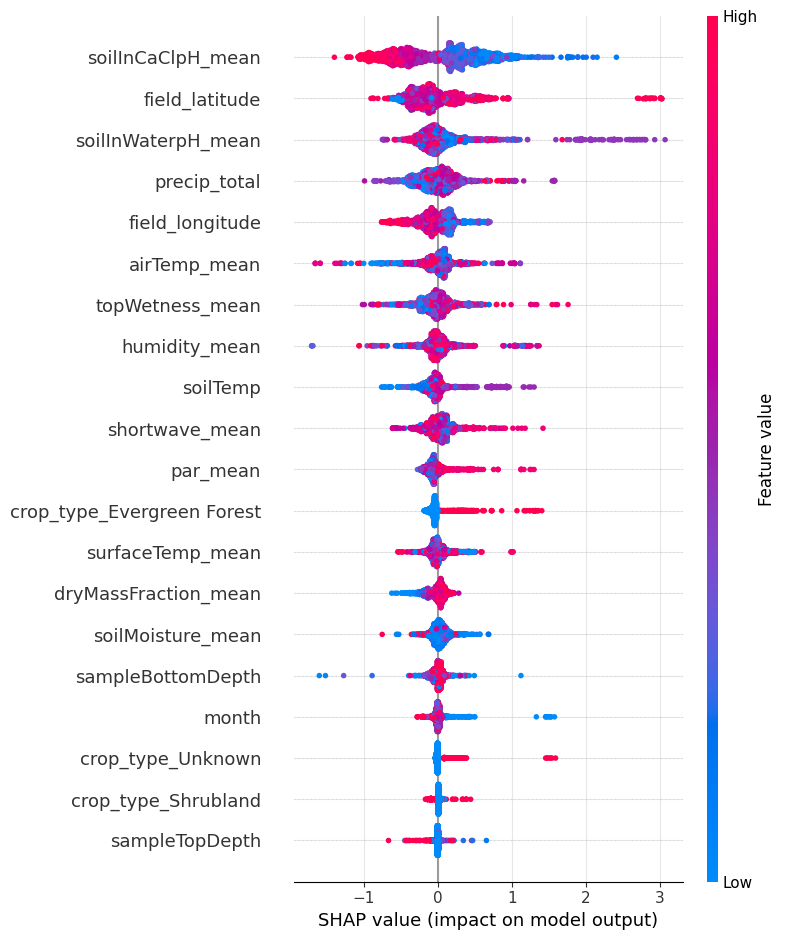

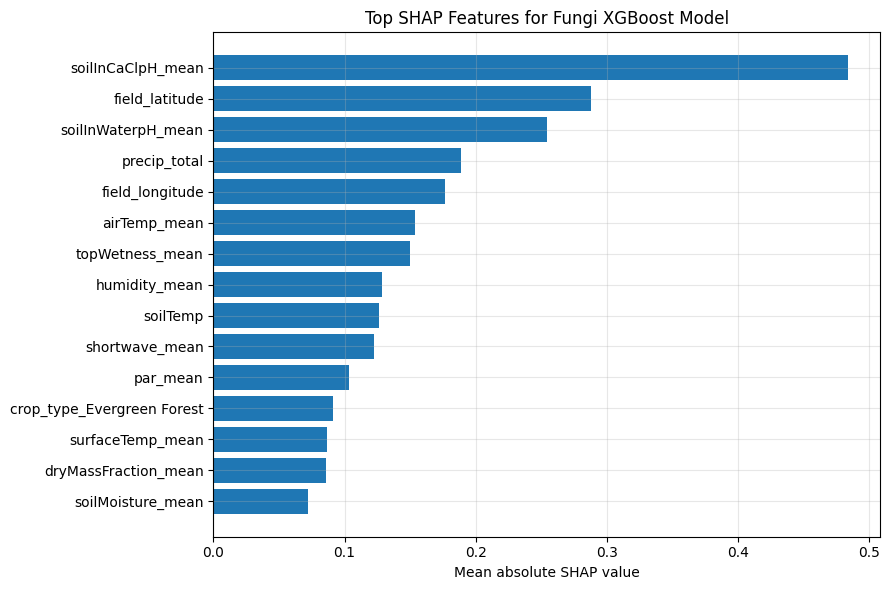

In [33]:
if not SHAP_AVAILABLE:
    print("SHAP is not available. Install shap and rerun this cell if you need explainability figures.")
elif "Fungi" not in subgroup_random_artifacts:
    print("Fungi subgroup artifacts were not found. Rerun the subgroup benchmark first.")
elif "XGBoost" not in subgroup_random_artifacts["Fungi"]:
    print("XGBoost was not run for the fungi subgroup. Add XGBoost to SUBGROUP_MODEL_NAMES and rerun.")
else:
    fungi_xgb_pipe = subgroup_random_artifacts["Fungi"]["XGBoost"]["pipeline"]
    X_test_fungi = subgroup_random_artifacts["Fungi"]["XGBoost"]["X_test"]

    preprocess = fungi_xgb_pipe.named_steps["preprocess"]
    xgb_model = fungi_xgb_pipe.named_steps["model"]

    X_test_transformed = preprocess.transform(X_test_fungi)
    feature_names = preprocess.get_feature_names_out()

    sample_size = min(2000, X_test_transformed.shape[0])
    rng = np.random.default_rng(SEED)
    sample_idx = rng.choice(X_test_transformed.shape[0], size=sample_size, replace=False)
    X_shap = X_test_transformed[sample_idx]

    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_shap)

    clean_feature_names = [name.replace("num__", "").replace("cat__", "") for name in feature_names]

    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    shap_importance_df = pd.DataFrame({
        "Feature": clean_feature_names,
        "Mean_Abs_SHAP": mean_abs_shap
    }).sort_values("Mean_Abs_SHAP", ascending=False)

    display(shap_importance_df.head(20))
    shap_importance_df.to_csv(TABLE_DIR / "fungi_xgboost_shap_importance.csv", index=False)

    plt.figure(figsize=(9, 6))
    shap.summary_plot(shap_values, X_shap, feature_names=clean_feature_names, show=False, max_display=20)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "fungi_xgboost_shap_summary.png", dpi=300, bbox_inches="tight")
    plt.show()

    top_shap = shap_importance_df.head(15).iloc[::-1]
    plt.figure(figsize=(9, 6))
    plt.barh(top_shap["Feature"], top_shap["Mean_Abs_SHAP"])
    plt.xlabel("Mean absolute SHAP value")
    plt.title("Top SHAP Features for Fungi XGBoost Model")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "fungi_xgboost_top_shap_features.png", dpi=300, bbox_inches="tight")
    plt.show()

## 21. Artifact inventory

This final table lists the main outputs produced by the benchmark notebook. These are the tables and figures most useful for writing the paper.

In [34]:
artifact_rows = []

for folder in [
    TABLE_DIR,
    FIG_DIR,
    DATA_OUTPUT_DIR,
    SPLIT_DIR,
    PRED_DIR,
    REPRO_DIR
]:

    for path in sorted(
        folder.rglob("*")
    ):

        if path.is_file():

            artifact_rows.append({
                "Artifact":
                    str(
                        path.relative_to(
                            BASE_DIR
                        )
                    ),

                "Size_Bytes":
                    path.stat().st_size
            })


artifact_inventory = pd.DataFrame(
    artifact_rows
)

display(
    artifact_inventory
)

artifact_inventory.to_csv(
    BASE_DIR
    / "artifact_inventory.csv",
    index=False
)

print(
    "Revised leakage-aware benchmark completed."
)

print(
    "Total artifacts:",
    len(
        artifact_inventory
    )
)

,Artifact,Size_Bytes
0,tables/bacteria_archaea_model_r2_pivot.csv,424
1,tables/benchmark_model_description.csv,503
2,tables/column_inventory.csv,3123
3,tables/combined_generalisation_gap_summary.csv,2651
4,tables/combined_global_and_subgroup_benchmark_...,8317
...,...,...
66,predictions/subgroup_site_oof_predictions.csv,29136724
67,reproducibility/benchmark_manifest.json,1450
68,reproducibility/dataset_sha256.txt,65
69,reproducibility/model_configuration.json,3496


Revised leakage-aware benchmark completed.
Total artifacts: 71


In [35]:
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display


if "BASE_DIR" in globals():
    PAPER_TABLE_DIR = Path(BASE_DIR) / "paper_ready_tables"
else:
    PAPER_TABLE_DIR = Path("paper_ready_tables")

PAPER_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Paper tables will be saved to:")
print(PAPER_TABLE_DIR.resolve())


# ============================================================
# 1. CHECK REQUIRED RESULTS EXIST
# ============================================================

required_objects = [
    "global_results",
    "repeated_run_results",
    "repeated_run_summary",
    "mixedlm_results",
    "forward_chaining_results",
    "transfer_ablation_results",
    "governance_ablation_results",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Run the complete final notebook first. "
        "Missing objects: "
        + ", ".join(missing_objects)
    )


# ============================================================
# 2. FORMATTING HELPERS
# ============================================================

def fmt_number(value):
    """Format a single R² value to 3 decimal places."""

    if pd.isna(value):
        return ""

    return f"{float(value):.3f}"


def fmt_mean_sd(mean_value, sd_value):
    """
    Format repeated-run result as mean ± SD.

    Very small non-zero SDs use 4 decimal places so that
    they are not incorrectly displayed as exactly 0.000.
    """

    if pd.isna(mean_value):
        return ""

    if pd.isna(sd_value):
        return f"{float(mean_value):.3f}"

    mean_value = float(mean_value)
    sd_value = float(sd_value)

    if 0 < abs(sd_value) < 0.0005:
        sd_text = f"{sd_value:.4f}"
    else:
        sd_text = f"{sd_value:.3f}"

    return f"{mean_value:.3f} ± {sd_text}"


def repeated_result(dataset, model, setting):
    """Get mean ± SD R² from the five-seed analysis."""

    row = repeated_run_summary[
        (repeated_run_summary["Dataset"] == dataset)
        &
        (repeated_run_summary["Model"] == model)
        &
        (repeated_run_summary["Setting"] == setting)
    ]

    if len(row) != 1:
        raise ValueError(
            f"Expected exactly one repeated result for "
            f"{dataset} | {model} | {setting}, found {len(row)}."
        )

    row = row.iloc[0]

    return fmt_mean_sd(
        row["R2_Mean"],
        row["R2_SD"]
    )


def repeated_transfer_result(dataset, model):
    """
    Calculate mean transfer R² for each model seed first:

        (Site R² + Time R²) / 2

    Then report mean ± SD across the five seeds.
    """

    current = repeated_run_results[
        (repeated_run_results["Dataset"] == dataset)
        &
        (repeated_run_results["Model"] == model)
    ].copy()

    pivot = current.pivot_table(
        index="Model_Seed",
        columns="Setting",
        values="R2",
        aggfunc="first"
    )

    required = [
        "GroupKFold by site",
        "Time-aware holdout"
    ]

    for setting in required:
        if setting not in pivot.columns:
            raise ValueError(
                f"Missing {setting} for {dataset} | {model}"
            )

    transfer_by_seed = (
        pivot["GroupKFold by site"]
        +
        pivot["Time-aware holdout"]
    ) / 2.0

    return fmt_mean_sd(
        transfer_by_seed.mean(),
        transfer_by_seed.std(ddof=1)
    )


def frozen_global_result(model, setting):
    """Get R² from the frozen reference benchmark run."""

    row = global_results[
        (global_results["Model"] == model)
        &
        (global_results["Setting"] == setting)
    ]

    if len(row) != 1:
        raise ValueError(
            f"Could not uniquely find {model} | {setting}"
        )

    return float(row.iloc[0]["R2"])


def frozen_global_transfer(model):
    """Mean transfer score for a frozen reference model."""

    site = frozen_global_result(
        model,
        "GroupKFold by site"
    )

    time = frozen_global_result(
        model,
        "Time-aware holdout"
    )

    return (site + time) / 2.0


# ============================================================
# TABLE 2
# Global microbial abundance benchmark results
# ============================================================

repeated_models = [
    "Stacking Ensemble",
    "CatBoost",
    "LightGBM",
    "XGBoost",
]

reference_models = [
    "Random Forest",
    "Extra Trees",
    "Ridge",
    "ElasticNet",
]

table2_rows = []


# ------------------------------------------------------------
# Five-seed stochastic models
# ------------------------------------------------------------

for model in repeated_models:

    table2_rows.append({
        "Model":
            model,

        "Random R²":
            repeated_result(
                "Global",
                model,
                "Random split"
            ),

        "K-fold R²":
            repeated_result(
                "Global",
                model,
                "5-fold CV"
            ),

        "Site R²":
            repeated_result(
                "Global",
                model,
                "GroupKFold by site"
            ),

        "Time R²":
            repeated_result(
                "Global",
                model,
                "Time-aware holdout"
            ),

        "Mean transfer R²":
            repeated_transfer_result(
                "Global",
                model
            )
    })


# ------------------------------------------------------------
# Frozen reference baselines
# ------------------------------------------------------------

for model in reference_models:

    table2_rows.append({
        "Model":
            model,

        "Random R²":
            fmt_number(
                frozen_global_result(
                    model,
                    "Random split"
                )
            ),

        "K-fold R²":
            fmt_number(
                frozen_global_result(
                    model,
                    "5-fold CV"
                )
            ),

        "Site R²":
            fmt_number(
                frozen_global_result(
                    model,
                    "GroupKFold by site"
                )
            ),

        "Time R²":
            fmt_number(
                frozen_global_result(
                    model,
                    "Time-aware holdout"
                )
            ),

        "Mean transfer R²":
            fmt_number(
                frozen_global_transfer(
                    model
                )
            )
    })


# ------------------------------------------------------------
# Mixed-effects specialised baseline
# ------------------------------------------------------------

def mixedlm_value(setting):

    row = mixedlm_results[
        mixedlm_results["Setting"] == setting
    ]

    if len(row) != 1:
        raise ValueError(
            f"Mixed-effects result missing for {setting}"
        )

    return float(
        row.iloc[0]["R2"]
    )


mixed_site = mixedlm_value(
    "GroupKFold by site"
)

mixed_time = mixedlm_value(
    "Time-aware holdout"
)


table2_rows.append({
    "Model":
        "Linear Mixed Effects",

    "Random R²":
        fmt_number(
            mixedlm_value(
                "Random split"
            )
        ),

    "K-fold R²":
        fmt_number(
            mixedlm_value(
                "5-fold CV"
            )
        ),

    "Site R²":
        fmt_number(
            mixed_site
        ),

    "Time R²":
        fmt_number(
            mixed_time
        ),

    "Mean transfer R²":
        fmt_number(
            (
                mixed_site
                + mixed_time
            ) / 2.0
        )
})


table2 = pd.DataFrame(
    table2_rows
)


print("\n" + "=" * 90)
print("TABLE 2. Global microbial abundance benchmark results")
print("=" * 90)

display(table2)


# ============================================================
# TABLE 3
# Subgroup-specific benchmark results
# ============================================================

subgroup_model_order = [
    "Stacking Ensemble",
    "LightGBM",
    "XGBoost",
    "CatBoost",
]

table3_rows = []

for dataset_name in [
    "Fungi",
    "Bacteria/Archaea",
]:

    for model in subgroup_model_order:

        table3_rows.append({
            "Dataset":
                dataset_name,

            "Model":
                model,

            "Random R²":
                repeated_result(
                    dataset_name,
                    model,
                    "Random split"
                ),

            "K-fold R²":
                repeated_result(
                    dataset_name,
                    model,
                    "5-fold CV"
                ),

            "Site R²":
                repeated_result(
                    dataset_name,
                    model,
                    "GroupKFold by site"
                ),

            "Time R²":
                repeated_result(
                    dataset_name,
                    model,
                    "Time-aware holdout"
                ),

            "Mean transfer R²":
                repeated_transfer_result(
                    dataset_name,
                    model
                )
        })


table3 = pd.DataFrame(
    table3_rows
)


print("\n" + "=" * 90)
print("TABLE 3. Subgroup-specific benchmark results")
print("=" * 90)

display(table3)


# ============================================================
# TABLE 4
# Global forward-chaining temporal R²
# ============================================================

global_forward = (
    forward_chaining_results[
        forward_chaining_results[
            "Dataset"
        ] == "Global"
    ]
    .copy()
)


table4_numeric = (
    global_forward
    .pivot(
        index="Model",
        columns="Holdout_Year",
        values="R2"
    )
)


table4_model_order = [
    "XGBoost",
    "LightGBM",
    "CatBoost",
    "Stacking Ensemble",
]

table4_year_order = [
    year
    for year in [
        2014,
        2016,
        2017,
        2018
    ]
    if year in table4_numeric.columns
]


table4_numeric = (
    table4_numeric
    .reindex(
        table4_model_order
    )[
        table4_year_order
    ]
)


table4 = (
    table4_numeric
    .map(
        lambda x:
            fmt_number(x)
    )
    .reset_index()
)


table4.columns = [
    "Model"
] + [
    str(year)
    for year in table4_year_order
]


print("\n" + "=" * 90)
print(
    "TABLE 4. Global forward-chaining temporal "
    "R² across future-period holdouts"
)
print("=" * 90)

display(table4)


# ============================================================
# TABLE 5
# Transfer-aware feature and feature-governance ablation
#
# Panel A = ecological component removal
# Panel B = governance relaxation
# ============================================================


# ------------------------------------------------------------
# PANEL A — ecological component removal
# ------------------------------------------------------------

component_settings = [
    "Random split",
    "GroupKFold by site",
    "Time-aware holdout",
]


component_subset = (
    transfer_ablation_results[
        transfer_ablation_results[
            "Setting"
        ].isin(
            component_settings
        )
    ]
    .copy()
)


component_pivot = (
    component_subset
    .pivot(
        index="Feature_Set",
        columns="Setting",
        values="R2"
    )
)


component_order = [
    "Full",
    "Full - Soil",
    "Full - Climate",
    "Full - Spatial",
    "Full - Temporal",
    "Full - Land Cover",
]


component_labels = {
    "Full":
        "Full",

    "Full - Soil":
        "− Soil",

    "Full - Climate":
        "− Climate",

    "Full - Spatial":
        "− Spatial",

    "Full - Temporal":
        "− Temporal",

    "Full - Land Cover":
        "− Land cover",
}


table5a = (
    component_pivot
    .reindex(
        component_order
    )[
        component_settings
    ]
    .rename(
        index=component_labels,
        columns={
            "Random split":
                "Random R²",

            "GroupKFold by site":
                "Site R²",

            "Time-aware holdout":
                "Time R²",
        }
    )
    .map(
        lambda x:
            fmt_number(x)
    )
    .reset_index()
    .rename(
        columns={
            "Feature_Set":
                "Configuration"
        }
    )
)


table5a.insert(
    0,
    "Panel",
    "A"
)


# ------------------------------------------------------------
# PANEL B — feature-governance relaxation
# ------------------------------------------------------------

governance_settings = [
    "Random split",
    "GroupKFold by site",
    "Time-aware holdout",
]


governance_subset = (
    governance_ablation_results[
        governance_ablation_results[
            "Setting"
        ].isin(
            governance_settings
        )
    ]
    .copy()
)


governance_pivot = (
    governance_subset
    .pivot(
        index="Configuration",
        columns="Setting",
        values="R2"
    )
)


# Exclude "Governance relaxed - all" from the paper table.
# It is redundant once the individual blocks are shown.
governance_order = [
    "Governed ecological",
    "Governed + identifiers",
    "Governed + assay metadata",
    "Governed + target-proximal",
]


governance_labels = {
    "Governed ecological":
        "Governed",

    "Governed + identifiers":
        "+ Identifiers",

    "Governed + assay metadata":
        "+ Assay metadata",

    "Governed + target-proximal":
        "+ Target-proximal",
}


table5b = (
    governance_pivot
    .reindex(
        governance_order
    )[
        governance_settings
    ]
    .rename(
        index=governance_labels,
        columns={
            "Random split":
                "Random R²",

            "GroupKFold by site":
                "Site R²",

            "Time-aware holdout":
                "Time R²",
        }
    )
    .map(
        lambda x:
            fmt_number(x)
    )
    .reset_index()
)


table5b.insert(
    0,
    "Panel",
    "B"
)


# ------------------------------------------------------------
# Combine Panels A and B
# ------------------------------------------------------------

table5 = pd.concat(
    [
        table5a,
        table5b
    ],
    ignore_index=True
)


print("\n" + "=" * 90)
print(
    "TABLE 5. Transfer-aware feature and "
    "feature-governance ablation (XGBoost)"
)
print("=" * 90)

display(table5)


# ============================================================
# 6. SAVE INDIVIDUAL CSV FILES
# ============================================================

table2.to_csv(
    PAPER_TABLE_DIR
    / "Table_2_Global_Benchmark.csv",
    index=False
)

table3.to_csv(
    PAPER_TABLE_DIR
    / "Table_3_Subgroup_Benchmark.csv",
    index=False
)

table4.to_csv(
    PAPER_TABLE_DIR
    / "Table_4_Forward_Chaining.csv",
    index=False
)

table5.to_csv(
    PAPER_TABLE_DIR
    / "Table_5_Ablation.csv",
    index=False
)

# Save the two Table 5 panels separately too.
table5a.to_csv(
    PAPER_TABLE_DIR
    / "Table_5A_Component_Ablation.csv",
    index=False
)

table5b.to_csv(
    PAPER_TABLE_DIR
    / "Table_5B_Governance_Ablation.csv",
    index=False
)


# ============================================================
# 7. SAVE ALL TABLES INTO ONE EXCEL WORKBOOK
# ============================================================

excel_path = (
    PAPER_TABLE_DIR
    / "Final_Paper_Tables_2_to_5.xlsx"
)

try:

    with pd.ExcelWriter(
        excel_path,
        engine="openpyxl"
    ) as writer:

        table2.to_excel(
            writer,
            sheet_name="Table 2",
            index=False
        )

        table3.to_excel(
            writer,
            sheet_name="Table 3",
            index=False
        )

        table4.to_excel(
            writer,
            sheet_name="Table 4",
            index=False
        )

        table5.to_excel(
            writer,
            sheet_name="Table 5",
            index=False
        )

        table5a.to_excel(
            writer,
            sheet_name="Table 5A",
            index=False
        )

        table5b.to_excel(
            writer,
            sheet_name="Table 5B",
            index=False
        )

    print(
        "\nExcel workbook saved:"
    )

    print(
        excel_path.resolve()
    )

except Exception as e:

    print(
        "\nExcel export failed:",
        e
    )

    print(
        "CSV files were still saved successfully."
    )


# ============================================================
# 8. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 90)
print("PAPER TABLE GENERATION COMPLETE")
print("=" * 90)

print("\nTable 2:")
print(
    "Global microbial abundance benchmark results"
)

print("\nTable 3:")
print(
    "Subgroup-specific benchmark results"
)

print("\nTable 4:")
print(
    "Global forward-chaining temporal R² "
    "across future-period holdouts"
)

print("\nTable 5:")
print(
    "Transfer-aware feature and "
    "feature-governance ablation (XGBoost)"
)

print(
    "\nAll files saved in:"
)

print(
    PAPER_TABLE_DIR.resolve()
)

Paper tables will be saved to:
/home/22609573/outputs_leakage_aware_revised_benchmark/paper_ready_tables

TABLE 2. Global microbial abundance benchmark results


,Model,Random R²,K-fold R²,Site R²,Time R²,Mean transfer R²
0,Stacking Ensemble,0.433 ± 0.001,0.445 ± 0.001,-0.729 ± 0.101,-0.398 ± 0.074,-0.564 ± 0.059
1,CatBoost,0.333 ± 0.001,0.344 ± 0.0001,-0.049 ± 0.015,-0.090 ± 0.031,-0.070 ± 0.012
2,LightGBM,0.319 ± 0.0003,0.331 ± 0.0002,-0.158 ± 0.014,-0.069 ± 0.015,-0.114 ± 0.004
3,XGBoost,0.308 ± 0.001,0.321 ± 0.0004,-0.104 ± 0.009,-0.057 ± 0.010,-0.080 ± 0.006
4,Random Forest,0.136,0.150,-0.148,-0.083,-0.115
5,Extra Trees,0.103,0.117,-0.100,-0.128,-0.114
6,Ridge,0.054,0.051,-0.157,-0.094,-0.125
7,ElasticNet,0.054,0.051,-0.106,-0.087,-0.097
8,Linear Mixed Effects,0.129,0.130,-0.271,-0.342,-0.307



TABLE 3. Subgroup-specific benchmark results


,Dataset,Model,Random R²,K-fold R²,Site R²,Time R²,Mean transfer R²
0,Fungi,Stacking Ensemble,0.785 ± 0.001,0.768 ± 0.001,-0.583 ± 0.070,-1.850 ± 0.208,-1.216 ± 0.102
1,Fungi,LightGBM,0.779 ± 0.001,0.762 ± 0.001,-0.203 ± 0.027,-1.228 ± 0.041,-0.715 ± 0.014
2,Fungi,XGBoost,0.760 ± 0.001,0.744 ± 0.0005,-0.094 ± 0.013,-1.268 ± 0.200,-0.681 ± 0.102
3,Fungi,CatBoost,0.751 ± 0.001,0.737 ± 0.0002,-0.080 ± 0.006,-1.276 ± 0.190,-0.678 ± 0.094
4,Bacteria/Archaea,Stacking Ensemble,0.575 ± 0.001,0.602 ± 0.001,-0.662 ± 0.071,-2.904 ± 0.554,-1.783 ± 0.269
5,Bacteria/Archaea,LightGBM,0.556 ± 0.001,0.586 ± 0.0004,-0.281 ± 0.011,-1.116 ± 0.143,-0.699 ± 0.066
6,Bacteria/Archaea,XGBoost,0.531 ± 0.002,0.564 ± 0.001,-0.292 ± 0.018,-2.052 ± 0.643,-1.172 ± 0.320
7,Bacteria/Archaea,CatBoost,0.556 ± 0.001,0.581 ± 0.0003,-0.171 ± 0.023,-0.843 ± 0.196,-0.507 ± 0.099



TABLE 4. Global forward-chaining temporal R² across future-period holdouts


,Model,2014,2016,2017,2018
0,XGBoost,-0.060,-1.538,-0.392,-0.063
1,LightGBM,-0.026,-1.862,-0.385,-0.064
2,CatBoost,0.025,-1.474,-0.350,-0.071
3,Stacking Ensemble,-0.400,-3.096,-1.272,-0.340



TABLE 5. Transfer-aware feature and feature-governance ablation (XGBoost)


Setting,Panel,Configuration,Random R²,Site R²,Time R²
0,A,Full,0.307,-0.103,-0.063
1,A,− Soil,0.336,-0.097,-0.466
2,A,− Climate,0.296,-0.007,-0.257
3,A,− Spatial,0.307,-0.111,-0.042
4,A,− Temporal,0.306,-0.098,-0.092
5,A,− Land cover,0.306,-0.090,-0.059
6,B,Governed,0.307,-0.103,-0.063
7,B,+ Identifiers,0.320,-0.038,-0.034
8,B,+ Assay metadata,0.832,0.636,0.552
9,B,+ Target-proximal,0.990,0.955,0.876



Excel export failed: No module named 'openpyxl'
CSV files were still saved successfully.

PAPER TABLE GENERATION COMPLETE

Table 2:
Global microbial abundance benchmark results

Table 3:
Subgroup-specific benchmark results

Table 4:
Global forward-chaining temporal R² across future-period holdouts

Table 5:
Transfer-aware feature and feature-governance ablation (XGBoost)

All files saved in:
/home/22609573/outputs_leakage_aware_revised_benchmark/paper_ready_tables


In [36]:
from pathlib import Path

requirements = [
    f"numpy=={np.__version__}",
    f"pandas=={pd.__version__}",
    f"scikit-learn=={sklearn.__version__}",
    f"scipy=={scipy.__version__}",
    f"statsmodels=={statsmodels.__version__}",
]

if XGBOOST_AVAILABLE:
    requirements.append(f"xgboost=={xgboost.__version__}")

if LIGHTGBM_AVAILABLE:
    requirements.append(f"lightgbm=={lightgbm.__version__}")

if CATBOOST_AVAILABLE:
    requirements.append(f"catboost=={catboost.__version__}")

if SHAP_AVAILABLE:
    requirements.append(f"shap=={shap.__version__}")

requirements.append("matplotlib")
requirements.append("openpyxl")

with open(BASE_DIR / "requirements.txt", "w") as f:
    f.write("\n".join(requirements) + "\n")

print("Saved:", BASE_DIR / "requirements.txt")

Saved: outputs_leakage_aware_revised_benchmark/requirements.txt
